# HMDA 2022 — Pipeline Penemuan Pengetahuan

**Pertanyaan utama penemuan:** *Kombinasi karakteristik aplikasi, properti, pembiayaan, dan lingkungan seperti apa yang secara sistematis berkaitan dengan persetujuan atau penolakan hipotek, serta catatan tidak biasa mana yang memerlukan peninjauan operasional?*

Notebook ini mengikuti alur kerja KDD yang lengkap: preprocessing yang dapat diaudit, seleksi fitur, tiga algoritma clustering wajib, association rule mining dengan validasi statistik, deteksi anomali multi-metode, interpretasi bisnis, dan dashboard interaktif mandiri.

In [285]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=r"datetime\.datetime\.utcnow\(\) is deprecated.*",
    category=DeprecationWarning,
)

import datetime as _dt

def _aware_utcnow():
    utc = getattr(_dt, "UTC", _dt.timezone.utc)
    return _dt.datetime.now(utc)

try:
    import jupyter_client.session as _jcs
    _jcs.utcnow = _aware_utcnow
except Exception:
    pass

try:
    import jupyter_client.adapter as _jca
    _jca.utcnow = _aware_utcnow
except Exception:
    pass

try:
    import jupyter_client.multikernelmanager as _jcm
    _jcm.utcnow = _aware_utcnow
except Exception:
    pass

try:
    import ipykernel.kernelbase as _ikb
    _ikb.now = _aware_utcnow
except Exception:
    pass

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.feature_selection import mutual_info_classif

# Warning dipersempit per kategori, bukan dibungkam menyeluruh dengan
# filterwarnings("ignore"). Blanket ignore juga menyembunyikan RuntimeWarning
# yang justru penting di sini: overflow/underflow, pembagian dengan nol, dan
# mean atas slice kosong adalah gejala bug numerik yang harus terlihat.
for _cat, _mod in [(FutureWarning, "pandas"), (FutureWarning, "sklearn"),
                   (FutureWarning, "seaborn"), (DeprecationWarning, "mlxtend"),
                   (UserWarning, "mlxtend")]:
    warnings.filterwarnings("ignore", category=_cat, module=_mod)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 9)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42


import sys as _sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in _sys.path:
    _sys.path.insert(0, str(PROJECT_ROOT))

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
REPORTS_DIR = PROJECT_ROOT / "reports"
for _d in (DATA_RAW, DATA_INTERIM, DATA_PROCESSED, FIG_DIR, TABLE_DIR, REPORTS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

from pipeline import config as cfg
from pipeline import phase1_preprocessing as p1
from pipeline import phase2_clustering as p2
from pipeline import phase3_association_rules as p3
from pipeline import phase4_anomaly_detection as p4
from pipeline import phase5_reporting as p5


## Tema figure

Satu tema dipakai semua figure agar tampilannya konsisten: palet warna yang aman
untuk buta warna, grid tipis, dan tipografi seragam.


In [286]:
import matplotlib as mpl

HMDA_PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, SECOND, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#ffffff"
DENIED_COLOR, ORIGINATED_COLOR = "#e34948", "#0ca30c"
NODE_FILL, NODE_EDGE = "#cde2fb", "#2a78d6"

sns.set_style("white")
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "figure.dpi": 120, "savefig.dpi": 120,
    "savefig.facecolor": SURFACE, "savefig.bbox": "tight",
    "axes.edgecolor": BASELINE, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.labelsize": 10.5, "axes.labelcolor": SECOND,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "text.color": INK, "font.size": 10.5,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial", "sans-serif"],
    "legend.frameon": False, "legend.fontsize": 9,
    "axes.prop_cycle": mpl.cycler(color=HMDA_PALETTE),
    "image.cmap": "cividis", "figure.figsize": (16, 9),
})
print(f"Tema figure diterapkan: {len(HMDA_PALETTE)} warna seri.")


Tema figure diterapkan: 8 warna seri.


## Pemetaan rubric Excellent

| Area rubric | Bukti dalam notebook ini |
|---|---|
| Data cleaning | Audit asal sentinel, analisis missingness struktural, pemeriksaan duplikat, dan justifikasi eksplisit |
| Transformation | Pemetaan label, harmonisasi DTI, binning berbasis domain, dan scaling khusus per fase |
| Feature selection | Korelasi, pemeriksaan redundansi, Mutual Information berbasis entropi, dan pencegahan leakage per fase |
| Clustering | K-Means, DBSCAN, hierarchical Ward, elbow + silhouette, dan profil bisnis yang diberi nama |
| Association rules | Apriori, Support/Confidence/Lift, ≥10 rule nontrivial, serta pemeriksaan signifikansi dan redundansi |
| Anomalies | IQR, Z-score, Isolation Forest record-level, LOF, cross-reference DBSCAN, **Isolation Forest group-level + audit cluster K-Means/DBSCAN untuk collective anomaly**, dan triage berbasis bukti |
| Communication | Dashboard interaktif mandiri, laporan dengan bahasa umum, dan audit rubric yang dapat dieksekusi |


# Fase 1

## 1 - Memuat sampel

Semua kolom dimuat sebagai string agar:

- tidak terjadi kesalahan inferensi tipe data; Pandas dapat membaca sejumlah baris awal lalu menyimpulkan tipe kolom, padahal beberapa kolom HMDA mencampurkan rentang dan bilangan bulat;
- angka nol di depan, misalnya pada kode wilayah, tetap dipertahankan.

Nama kolom kemudian dinormalisasi dengan mengganti tanda `-` menjadi `_` agar konsisten dan tidak menimbulkan kekeliruan pada langkah berikutnya (`applicant_race-1` → `applicant_race_1`).

In [287]:
HF_URL = cfg.HF_URL

df = p1.load_raw(HF_URL)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


D:\Documents\Kuliah\Cawu 5\Data Mining\Final\pipeline\phase1_preprocessing.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"": np.nan, " ": np.nan, "NA": np.nan, "na": np.nan, "NaN": np.nan,


Shape: 100,000 rows x 99 columns


## 2 - Segmentasi jenis fitur

Fitur dibagi berdasarkan makna dan perlakuan analitisnya:

- `CONTINUOUS`: fitur berupa bilangan riil;
- `STRING_BAND`: fitur yang memuat rentang angka;
- `CATEG_CODE`: fitur kategorikal yang direpresentasikan dengan kode angka;
- `TEXT_CATEG`: fitur kategorikal yang sudah mudah dibaca manusia;
- `IDS`: fitur pengenal;
- `DEMOGRAPHIC_RAW` / `AUS` / `DENIAL`: kelompok fitur yang memiliki fungsi khusus.

Pembagian klasik menjadi nominal dan ordinal saja belum cukup karena tidak langsung menentukan perlakuan preprocessing. Beberapa fitur bahkan mencampurkan rentang dan angka sehingga tidak cocok ditempatkan secara sederhana. Kesalahan pengelompokan dapat membuat kode `1111/8888/9999` ikut dihitung dalam mean atau scaler, atau membuat kandidat itemset membesar secara tidak terkendali. Pembagian klasik tetap digunakan di dalam masing-masing kelompok bila relevan.

Label dan detail fitur mengacu pada dokumentasi FFIEC/CFPB: https://ffiec.cfpb.gov/documentation/publications/loan-level-datasets/lar-data-fields#county_code.

In [288]:
CONTINUOUS = cfg.CONTINUOUS
STRING_BAND = cfg.STRING_BAND
CATEG_CODE = cfg.CATEG_CODE
TEXT_CATEG = cfg.TEXT_CATEG
IDS = cfg.IDS
DEMOGRAPHIC_RAW = cfg.DEMOGRAPHIC_RAW
AUS = cfg.AUS
DENIAL = cfg.DENIAL
SENTINEL_EXEMPT = cfg.SENTINEL_EXEMPT


In [289]:
LABELS = cfg.LABELS


**Validasi — delapan kelompok segmentasi harus membentuk partisi dari seluruh kolom mentah.** Gabungan `CONTINUOUS` + `STRING_BAND` + `CATEG_CODE` + `TEXT_CATEG` + `IDS` + `DEMOGRAPHIC_RAW` + `AUS` + `DENIAL` harus mencakup seluruh 99 kolom mentah tepat satu kali. Kolom yang tidak tercakup akan diam-diam melewati seluruh aturan berikutnya, seperti penanganan sentinel, pemetaan label, dan daftar drop. Sebaliknya, kolom yang masuk ke dua kelompok dapat diproses dua kali dengan aturan yang saling bertentangan. Pemeriksaan dilakukan langsung terhadap `df.columns`, bukan hanya melalui inspeksi visual.

In [290]:
# Validasi - setiap kolom mentah harus berada tepat dalam satu kelompok segmentasi.
# Delapan kelompok di atas sengaja dibentuk sebagai partisi; bila suatu kolom
# tidak tercakup, kolom tersebut akan melewati seluruh aturan berikutnya secara diam-diam,
# termasuk penanganan sentinel, pemetaan label, dan daftar drop. Bila masuk ke dua kelompok,
# kolom dapat diproses dua kali dengan aturan bertentangan. Keduanya dicek langsung terhadap df.columns.
GROUPS = cfg.GROUPS
membership, group_total, uncovered, overlapping, phantom = p1.validate_group_partition(df.columns, GROUPS)

print(f"Raw columns: {len(df.columns)}  |  Sum of group sizes: {group_total}")
print(f"Uncovered (in no group): {len(uncovered)}  {uncovered}")
print(f"Overlapping (in >1 group): {len(overlapping)}  {overlapping}")
print(f"Phantom (named in a group, absent from df): {len(phantom)}  {phantom}")

assert not uncovered, f"columns missing from every group: {uncovered}"
assert not overlapping, f"columns claimed by more than one group: {overlapping}"
assert not phantom, f"group lists reference columns not in df: {phantom}"
print(f"\nPartition confirmed: all {len(df.columns)} raw columns covered by exactly one "
      f"of the {len(GROUPS)} segmentation groups.")


Raw columns: 99  |  Sum of group sizes: 99
Uncovered (in no group): 0  []
Overlapping (in >1 group): 0  {}
Phantom (named in a group, absent from df): 0  []

Partition confirmed: all 99 raw columns covered by exactly one of the 8 segmentation groups.


## Diagnostik sebelum cleaning

- **Distribusi fitur kontinu:** histogram seluruh fitur kontinu untuk menilai bentuk distribusi dan kebutuhan transformasi.
- **Pemindaian kode `1111/8888/9999`:** kode janggal dihitung berdasarkan kamus data; `1111` didokumentasikan pada 14 kolom, `8888` pada dua kolom umur, dan `9999` pada umur co-applicant.
- **Struktur DTI:** DTI bersifat unik karena bilangan bulat eksak hanya diterbitkan untuk `36 ≤ DTI < 50`, sedangkan nilai lainnya berupa rentang.
- **DTI terhadap approval:** approval rate dihitung untuk setiap angka DTI pada jendela 36–49 guna menentukan lokasi perubahan perilaku dan batas bin yang tepat.
- **Missing value dan kewajaran data:** persentase missing diperiksa menurut `action_taken`, disertai sanity check income terhadap loan amount, CLTV ekstrem, dan distribusi negara bagian pada sampel.

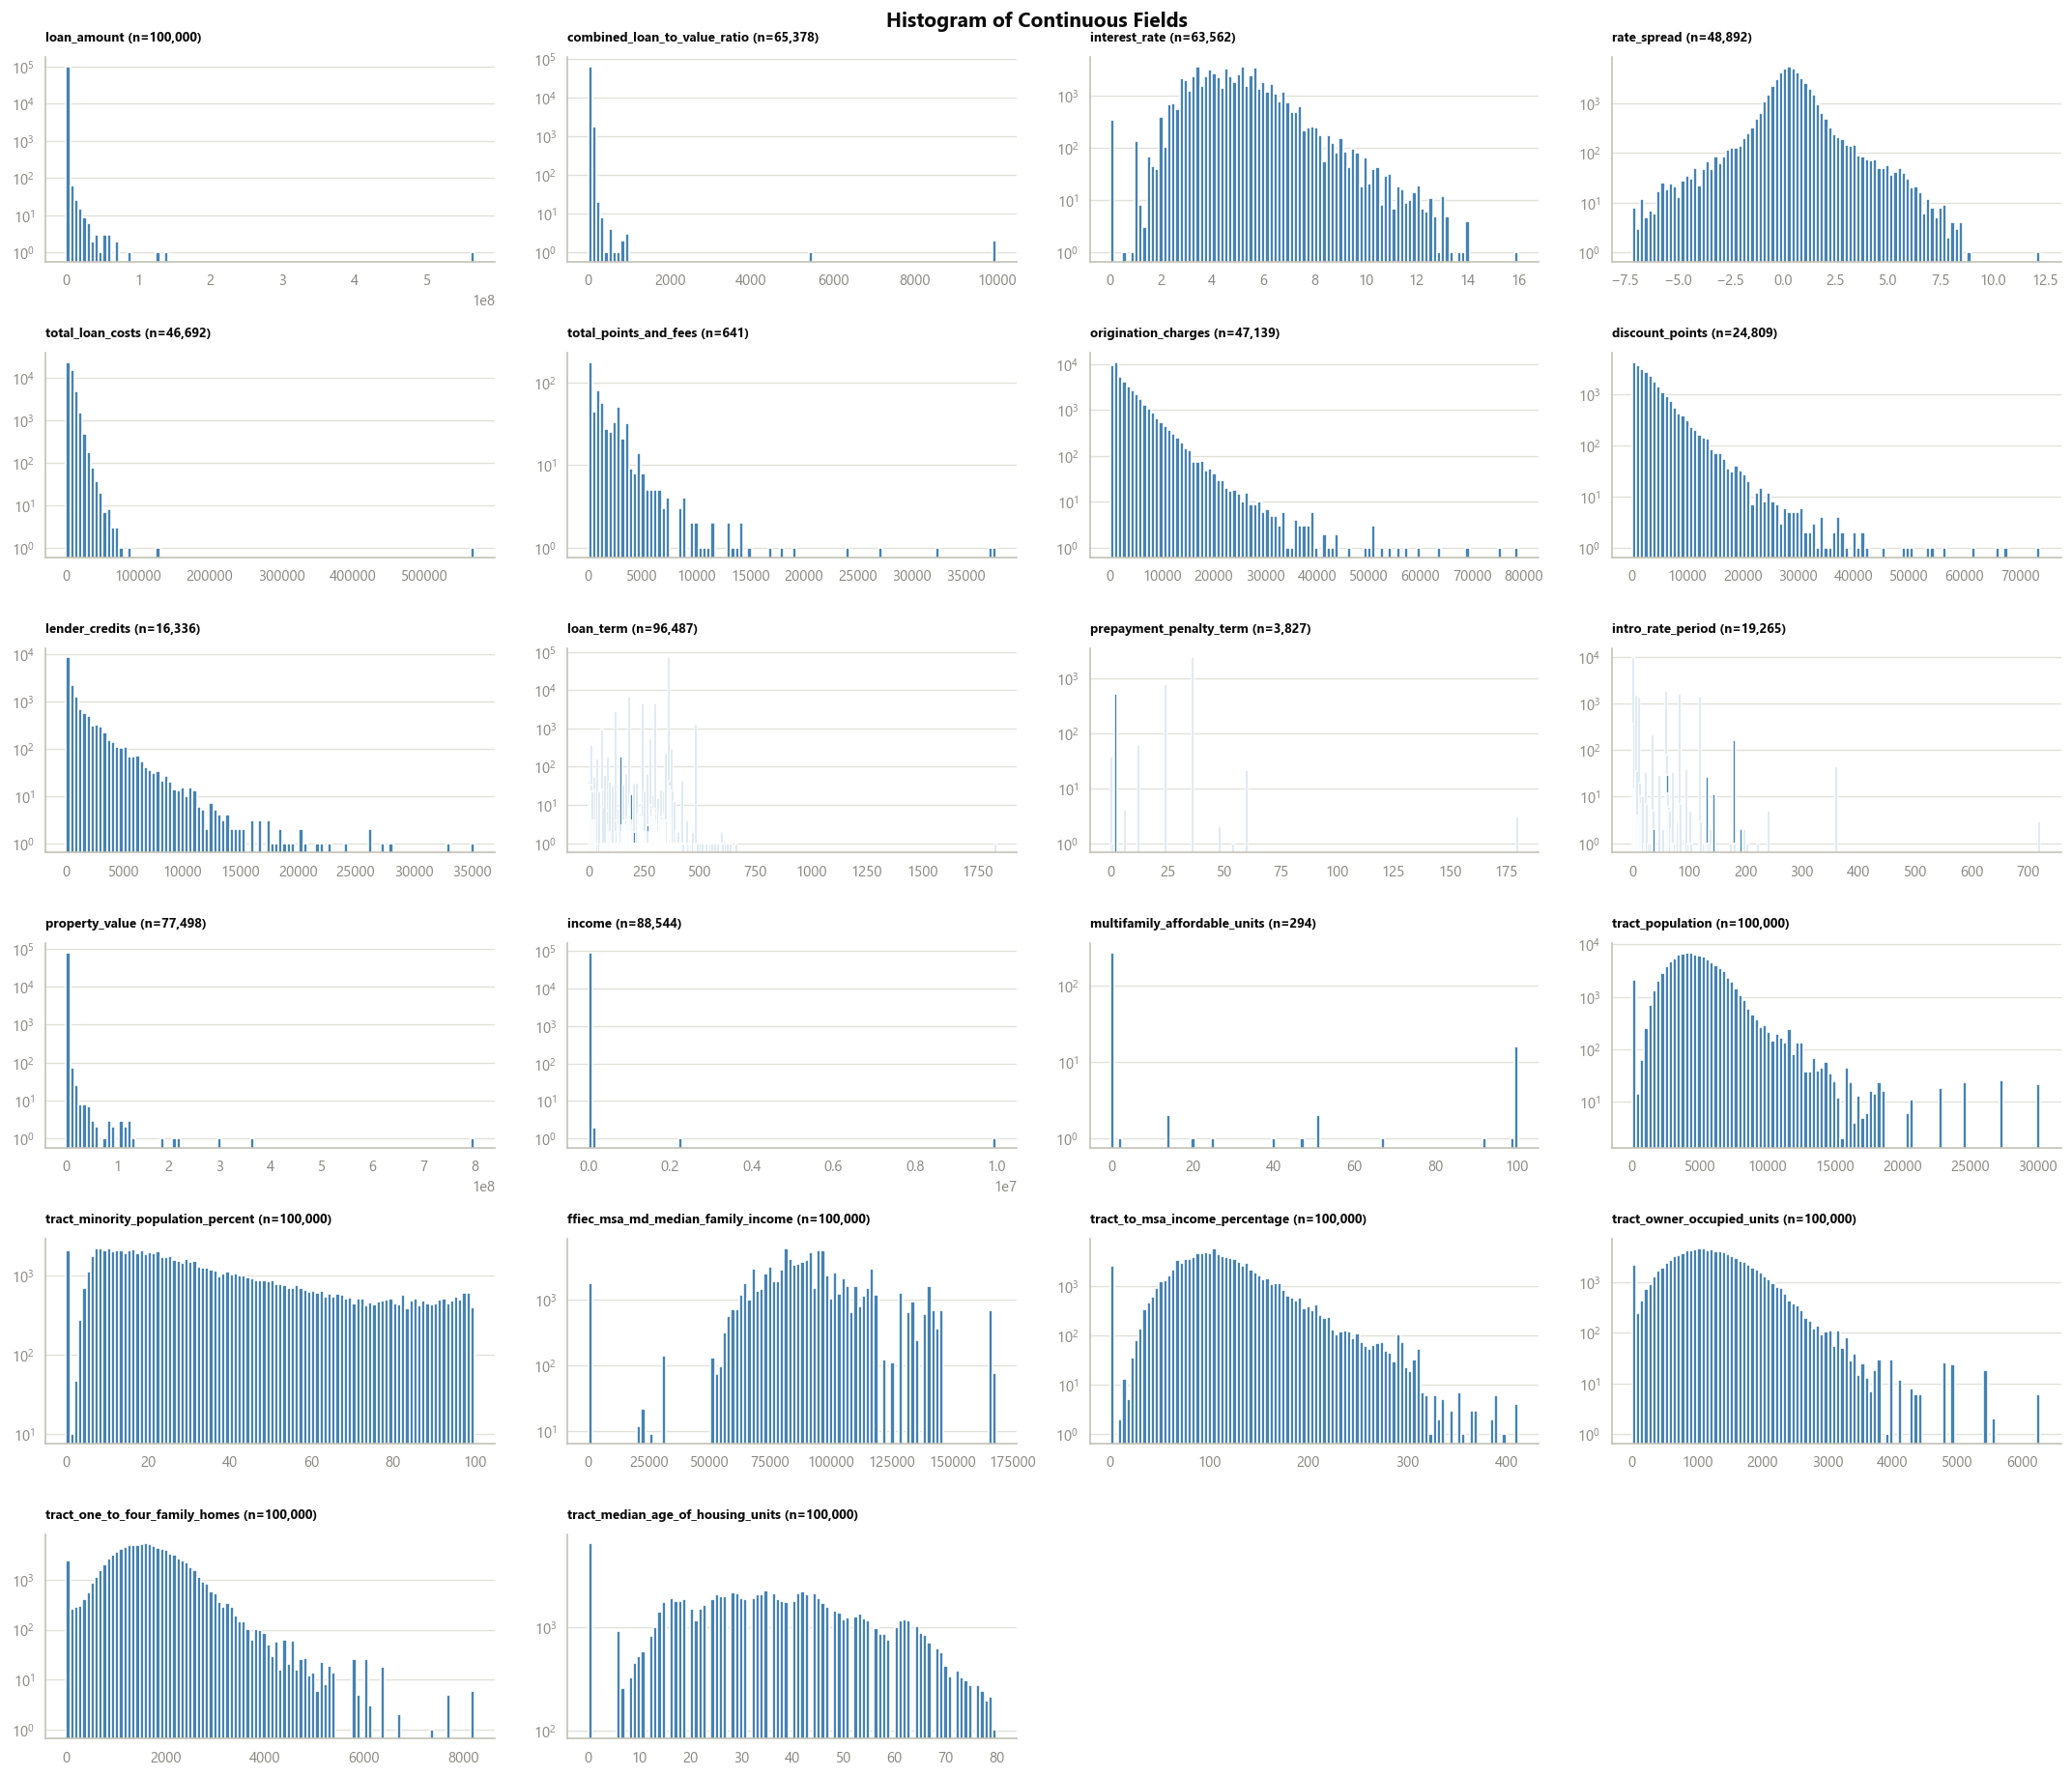

In [291]:
DISCRETE = ["loan_term", "prepayment_penalty_term", "intro_rate_period", "multifamily_affordable_units"]

cols = [c for c in CONTINUOUS if c in df.columns]
ncols = 4
nrows = (len(cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2.6))
axes = axes.flatten()
for ax, col in zip(axes, cols):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    if col in DISCRETE:
        vc = s.value_counts().sort_index()
        ax.bar(vc.index, vc.values, width=max(1, s.max() / 200), color="steelblue")
    else:
        ax.hist(s, bins=100, color="steelblue")
    ax.set_yscale("log")
    ax.set_title(f"{col} (n={len(s):,})", fontsize=8)
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.suptitle("Histogram of Continuous Fields", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p1_raw_distribution_scan.png", bbox_inches="tight")
plt.show()

In [292]:
SENTINEL_WHITELIST = cfg.SENTINEL_WHITELIST

print("Sentinel counts per dictionary whitelist:")
for code, wl in SENTINEL_WHITELIST.items():
    for col in wl:
        if col in df.columns:
            hits = int((df[col].astype(str) == code).sum())
            print(f"  {code}  {col:45s} {hits:,}")


Sentinel counts per dictionary whitelist:
  1111  reverse_mortgage                              1,861
  1111  open_end_line_of_credit                       1,854
  1111  business_or_commercial_purpose                1,862
  1111  negative_amortization                         1,873
  1111  interest_only_payment                         1,873
  1111  balloon_payment                               1,873
  1111  other_nonamortizing_features                  1,873
  1111  manufactured_home_secured_property_type       1,869
  1111  manufactured_home_land_property_interest      1,869
  1111  applicant_credit_score_type                   1,862
  1111  co_applicant_credit_score_type                1,862
  1111  submission_of_application                     1,870
  1111  initially_payable_to_institution              1,870
  1111  aus_1                                         1,890
  8888  applicant_age                                 10,466
  8888  co_applicant_age                              8,5

**Validasi — pemindaian sentinel diperluas ke seluruh kolom, bukan hanya whitelist terdokumentasi.** Whitelist merepresentasikan nilai yang *menurut* kamus FFIEC seharusnya muncul, tetapi tidak membuktikan bahwa `1111/8888/9999` tidak pernah muncul pada kolom lain. Pemindaian ulang dilakukan pada seluruh 99 kolom mentah. Setiap temuan dikelompokkan sebagai **whitelisted** bila berada pada kolom terdokumentasi atau **rogue** bila berada di luar kolom tersebut, sehingga setiap keputusan masking tidak bergantung pada asumsi bahwa whitelist pasti lengkap.

In [293]:
# Validasi - pemindaian sentinel diperluas ke seluruh kolom, bukan hanya whitelist terdokumentasi.
# Whitelist merepresentasikan nilai yang menurut kamus FFIEC diharapkan, tetapi tidak membuktikan
# bahwa 1111/8888/9999 tidak pernah muncul di tempat lain. Seluruh 99 kolom dipindai untuk ketiga
# kode tersebut dan setiap temuan dikelompokkan sebagai "whitelisted" atau "rogue" di luar
# kolom terdokumentasi agar keputusan masking tidak bergantung pada whitelist tanpa verifikasi.
rogue, whitelisted_total = p1.scan_rogue_sentinels(df, SENTINEL_WHITELIST, CONTINUOUS)

print(f"Whitelisted sentinel hits (already counted above): {whitelisted_total:,}")
print(f"Columns with rogue hits (code present outside its documented column list): {len(rogue)}\n")
for col, codes in sorted(rogue.items(), key=lambda kv: -sum(kv[1].values())):
    grp = membership.get(col, ["?"])[0]
    print(f"  {col:35s} [{grp:16s}] {codes}")

cont_total = sum(sum(c.values()) for col, c in rogue.items() if col in CONTINUOUS)
other_cols = {col: c for col, c in rogue.items() if col not in CONTINUOUS}
print(f"\nCONTINUOUS rogue total: {cont_total} -> matches the independent "
      f"'lookalike' count printed in the DTI-approval cell below (179) exactly; "
      f"same 8 columns, same rows, a genuine "
      f"cross-check rather than a new alarm.")
print(f"Non-CONTINUOUS rogue columns: {list(other_cols)}")

if "denial_reason_1" in other_cols:
    n = other_cols["denial_reason_1"][1111]
    n_denied = int((pd.to_numeric(df["denial_reason_1"], errors="coerce").eq(1111)
                    & df["action_taken"].eq("3")).sum())
    print(f"\ndenial_reason_1=1111 appears {n} times across every action_taken value "
          f"(not just Denied), consistent with 1111 meaning institution-level 'Exempt' "
          f"the same way it does in the 14 whitelisted columns - the FFIEC dictionary "
          f"just doesn't list this field alongside them. Only {n_denied} of those rows "
          f"are actually Denied (0.9% of the 15,684 denied rows), under the Phase 3 "
          f"denial-reason mining's 3% min_support floor - it was already silently "
          f"excluded from that result, not mishandled, but now that's demonstrated "
          f"rather than assumed. denial_reason_* is dropped from the main table "
          f"regardless (Phase 1 step 4), so no masking decision hinges on this finding.")

print("\nNo rogue hits in STRING_BAND, CATEG_CODE, TEXT_CATEG, IDS, DEMOGRAPHIC_RAW or "
      "AUS. One near-miss the string-exact match correctly rejected: county_code has 9 "
      "rows reading '01111' (a real zero-padded Alabama county FIPS code) that a naive "
      "numeric comparison would misread as the sentinel 1111 - exactly why coded/ID "
      "fields are matched by exact string here instead of by numeric value.")


Whitelisted sentinel hits (already counted above): 99,867
Columns with rogue hits (code present outside its documented column list): 8

  denial_reason_1                     [DENIAL          ] {1111: 1554}
  tract_owner_occupied_units          [CONTINUOUS      ] {1111: 109}
  tract_one_to_four_family_homes      [CONTINUOUS      ] {1111: 58}
  tract_population                    [CONTINUOUS      ] {1111: 1, 8888: 5}
  origination_charges                 [CONTINUOUS      ] {1111: 1, 9999: 1}
  lender_credits                      [CONTINUOUS      ] {1111: 2}
  total_points_and_fees               [CONTINUOUS      ] {9999: 1}
  income                              [CONTINUOUS      ] {8888: 1}

CONTINUOUS rogue total: 179 -> matches the independent 'lookalike' count printed in the DTI-approval cell below (179) exactly; same 8 columns, same rows, a genuine cross-check rather than a new alarm.
Non-CONTINUOUS rogue columns: ['denial_reason_1']

denial_reason_1=1111 appears 1554 times across ever

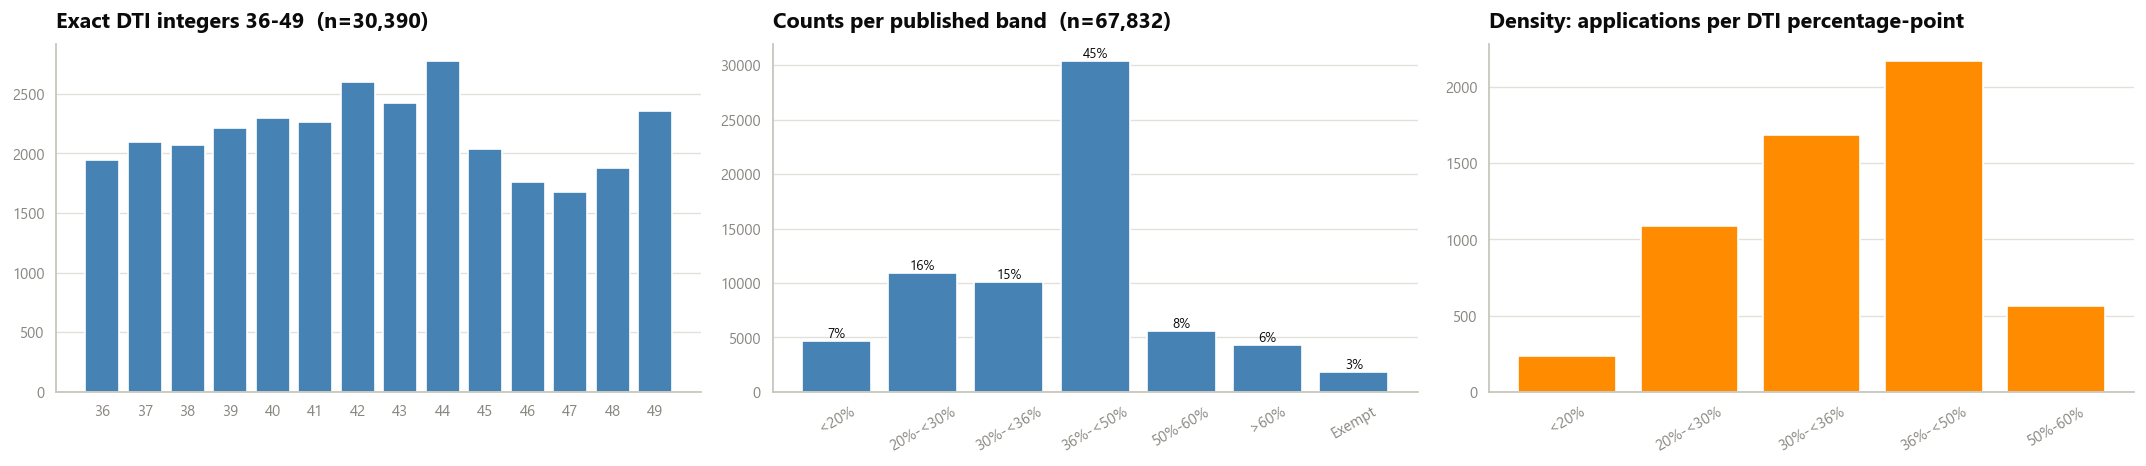

In [294]:
dti_raw = pd.to_numeric(df["debt_to_income_ratio"], errors="coerce")
exact = dti_raw[(dti_raw >= 36) & (dti_raw < 50)].astype(int)

s = df["debt_to_income_ratio"].astype(str).str.strip()
s = s.where(~s.str.fullmatch(r"\d+(\.0)?"), "36%-<50%")
BANDS = ["<20%", "20%-<30%", "30%-<36%", "36%-<50%", "50%-60%", ">60%", "Exempt", "NA"]
vc = s.value_counts().reindex([b for b in BANDS if b in s.unique()])
WIDTH = {"<20%": 20, "20%-<30%": 10, "30%-<36%": 6, "36%-<50%": 14, "50%-60%": 10}
density = pd.Series({b: vc[b] / w for b, w in WIDTH.items() if b in vc.index})

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(*np.unique(exact, return_counts=True), color="steelblue")
axes[0].set_xticks(range(36, 50))
axes[0].set_title(f"Exact DTI integers 36-49  (n={len(exact):,})")
axes[1].bar(vc.index, vc.values, color="steelblue")
axes[1].set_title(f"Counts per published band  (n={vc.sum():,})")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(vc.values):
    axes[1].text(i, v, f"{v/vc.sum()*100:.0f}%", ha="center", va="bottom", fontsize=8)
axes[2].bar(density.index, density.values, color="darkorange")
axes[2].set_title("Density: applications per DTI percentage-point")
axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "p1_dti_structure.png", bbox_inches="tight")
plt.show()

In [295]:
dti_raw = pd.to_numeric(df["debt_to_income_ratio"], errors="coerce")
m = dti_raw.between(36, 49) & df["action_taken"].astype(str).isin(["1", "3"])
tab = (
    pd.DataFrame({"dti": dti_raw[m].astype(int),
                  "approved": (df.loc[m, "action_taken"].astype(str) == "1").astype(int)}).groupby("dti")["approved"].agg(["mean", "size"]).round(3))
print("Approval rate by exact DTI (decisioned applications only):")
print(tab.to_string())

steps = tab["mean"].diff().dropna()
worst = steps.idxmin()
print(f"\nLargest single-step change: {worst - 1} {worst} "
      f"({steps[worst]:+.3f}; {tab.loc[worst - 1, 'mean']:.3f} {tab.loc[worst, 'mean']:.3f})")

lookalike = sum(int(pd.to_numeric(df[c], errors="coerce").isin([1111, 8888, 9999]).sum())
                for c in CONTINUOUS if c in df.columns)
print(f"\nNilai mirip kode di fitur continuous: {lookalike} baris — per kamus bukan kode, dibiarkan")

Approval rate by exact DTI (decisioned applications only):
      mean  size
dti             
36   0.857  1847
37   0.860  1988
38   0.860  1965
39   0.863  2096
40   0.866  2180
41   0.874  2148
42   0.878  2463
43   0.837  2275
44   0.853  2611
45   0.838  1935
46   0.813  1659
47   0.824  1581
48   0.834  1785
49   0.843  2230

Largest single-step change: 42 43 (-0.041; 0.878 0.837)

Nilai mirip kode di fitur continuous: 179 baris — per kamus bukan kode, dibiarkan


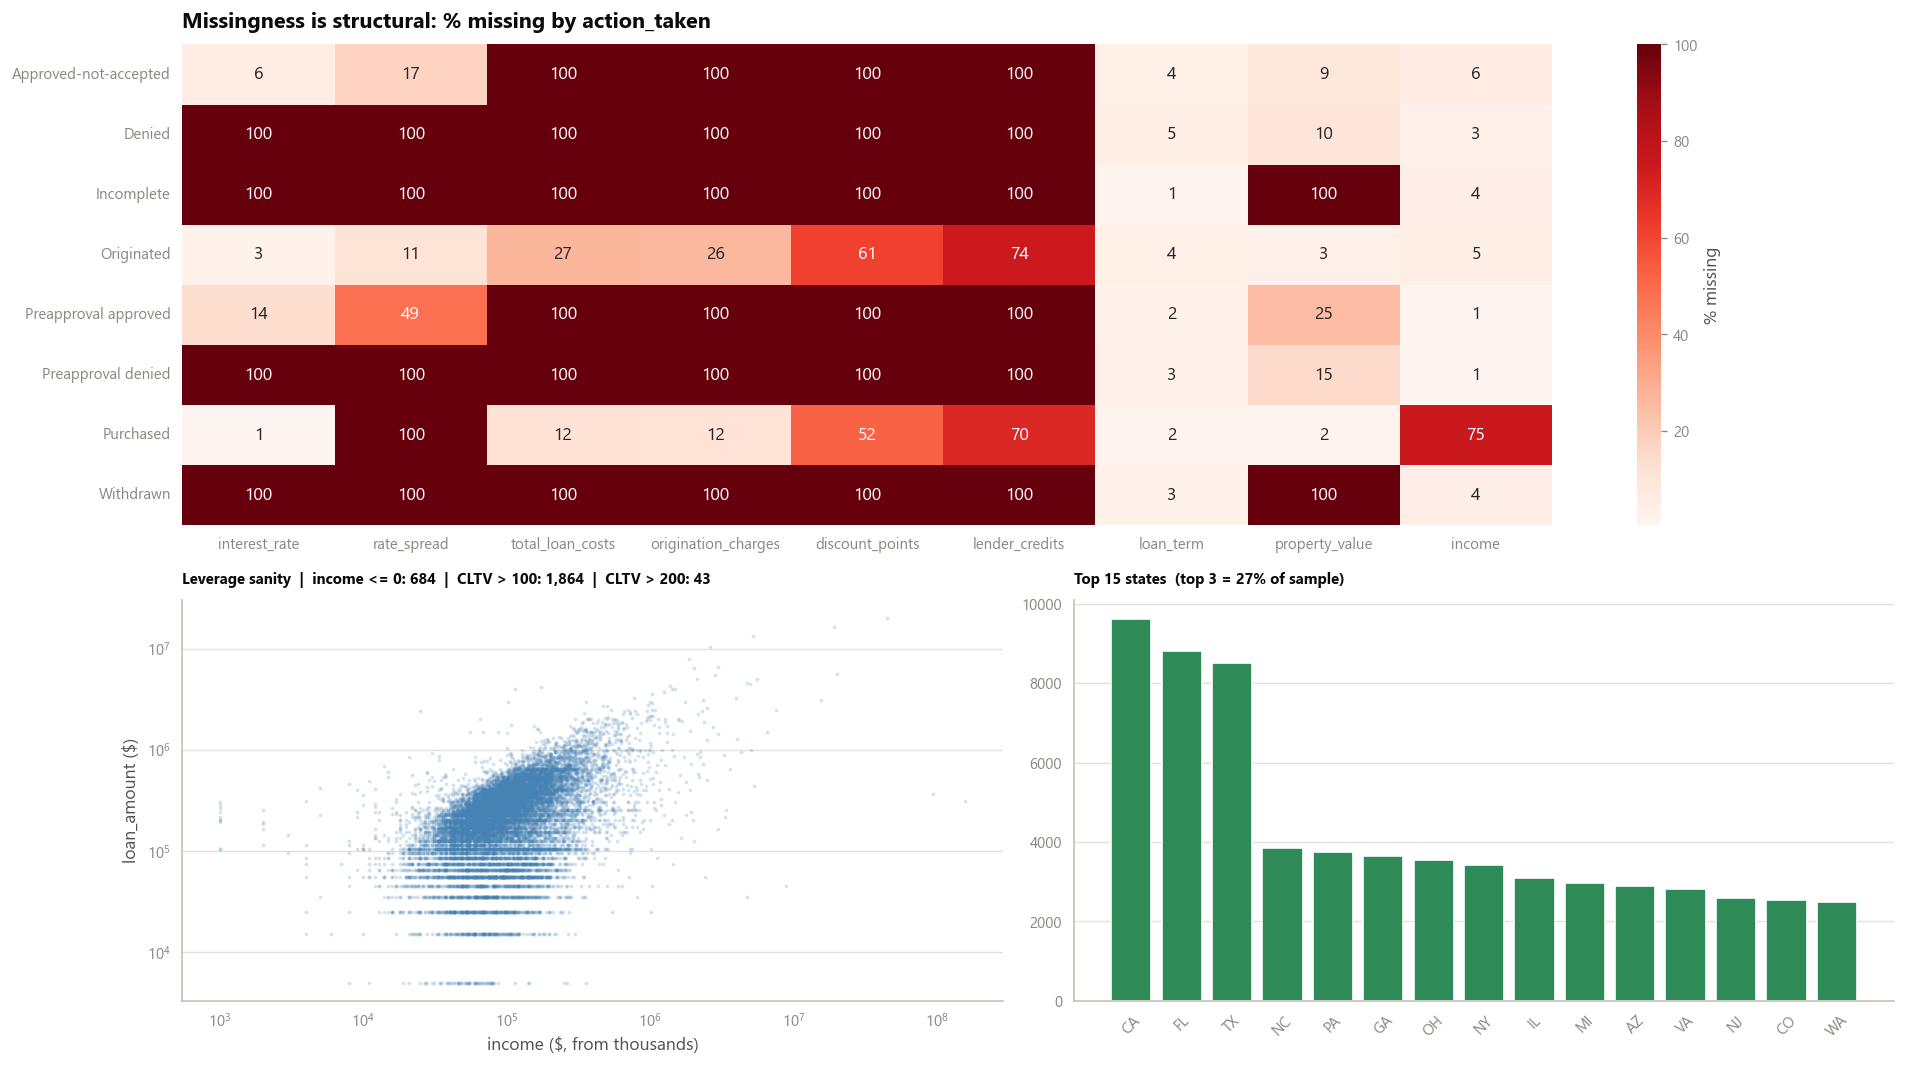

In [296]:
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

COND = ["interest_rate", "rate_spread", "total_loan_costs", "origination_charges",
        "discount_points", "lender_credits", "loan_term", "property_value", "income"]
ACTION = {"1": "Originated", "2": "Approved-not-accepted", "3": "Denied", "4": "Withdrawn",
          "5": "Incomplete", "6": "Purchased", "7": "Preapproval denied", "8": "Preapproval approved"}
miss_act = (df.assign(act=df["action_taken"].astype(str).map(ACTION))
              .groupby("act")[COND]
              .apply(lambda g: g.apply(pd.to_numeric, errors="coerce").isna().mean()) * 100)
ax0 = fig.add_subplot(gs[0, :])
sns.heatmap(miss_act, annot=True, fmt=".0f", cmap="Reds", cbar_kws={"label": "% missing"}, ax=ax0)
ax0.set_title("Missingness is structural: % missing by action_taken", fontweight="bold")
ax0.set_ylabel("")

inc = pd.to_numeric(df["income"], errors="coerce")
amt = pd.to_numeric(df["loan_amount"], errors="coerce")
cltv = pd.to_numeric(df["combined_loan_to_value_ratio"], errors="coerce")
ax1 = fig.add_subplot(gs[1, 0])
m = (inc > 0) & (amt > 0)
idx = df.index[m].to_series().sample(min(15000, int(m.sum())), random_state=RANDOM_STATE)
ax1.scatter(inc[idx] * 1000, amt[idx], s=2, alpha=0.15, color="steelblue")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("income ($, from thousands)"); ax1.set_ylabel("loan_amount ($)")
ax1.set_title(f"Leverage sanity  |  income <= 0: {int((inc <= 0).sum()):,}  |  "
              f"CLTV > 100: {int((cltv > 100).sum()):,}  |  CLTV > 200: {int((cltv > 200).sum()):,}",
              fontsize=9, fontweight="bold")

ax2 = fig.add_subplot(gs[1, 1])
st = df["state_code"].value_counts().head(15)
ax2.bar(st.index, st.values, color="seagreen")
ax2.set_title(f"Top 15 states  (top 3 = {st.head(3).sum() / len(df) * 100:.0f}% of sample)",
              fontsize=9, fontweight="bold")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / "p1_structural_diagnostics.png", bbox_inches="tight")
plt.show()


**Probe — apakah `1111` pada `lender_credits` merupakan sentinel atau nominal nyata?** Ini satu-satunya kolom kontinu yang nilai 1111-nya bisa diperdebatkan, dan keputusan pada langkah 3 untuk **tidak** melakukan masking numerik bergantung pada jawabannya. Cell berikut mencetak baris yang bersangkutan beserta `1111 / loan_amount` dalam persen. Bila 1111 merupakan kode Exempt, nilainya akan muncul pada aplikasi dengan ukuran mana pun secara acak. Bila merupakan dolar sungguhan, rasionya akan berada pada kisaran lender credit yang wajar, yaitu sepersekian persen dari nominal pinjaman.

In [297]:
rows = df.index[pd.to_numeric(df["lender_credits"], errors="coerce") == 1111]
print(df.loc[rows, ["lender_credits", "loan_amount", "origination_charges", "action_taken"]])
print((1111 / pd.to_numeric(df.loc[rows, "loan_amount"])) * 100)

      lender_credits loan_amount origination_charges action_taken
25842         1111.0      325000               987.0            1
89933         1111.0      295000              6559.0            1
25842    0.341846
89933    0.376610
Name: loan_amount, dtype: float64


### Temuan sebelum cleaning

- **Distribusi kontinu:** hampir seluruh fitur uang sangat right-skewed sehingga winsorization diperlukan untuk clustering. CLTV hingga 10.000 merupakan anomali, sedangkan `income ≤ 0` dapat valid karena mencerminkan kerugian usaha.
- **Kode janggal:** dokumentasi menempatkan `1111/8888/9999` hanya pada kolom kategorikal dan umur. Pengecualian numerik diterbitkan sebagai string `"Exempt"` yang otomatis menjadi `NaN` ketika dikoersi ke numerik.
- **Missingness bersifat struktural, bukan acak:** fitur pricing hampir 100% kosong untuk `Denied`, `Withdrawn`, dan `Incomplete` karena nilai tersebut baru tersedia setelah pinjaman memasuki tahap pricing. Karena itu, fitur tersebut tidak boleh diimputasi global dan harus dikeluarkan dari feature set. Tiga negara bagian terbesar mencakup sekitar 27% sampel; data cukup tersebar, tetapi temuan geografis tetap menggambarkan komposisi sampel ini.
- **Struktur DTI:** band gabungan `36%-<50%` mencakup sekitar 45% aplikasi dan akan membanjiri rule mining dengan rule ber-lift rendah, sehingga perlu dibagi.
- **DTI terhadap approval:** approval relatif datar pada 36–42 dan 43–49. Penurunan terbesar terjadi pada 42→43 sebesar 4,1 poin, bertepatan dengan bekas ambang QM. Satu batas pada 43 sudah menangkap perubahan utama; bin ketiga tidak memberi informasi berarti.

## 3 - Penanganan Sentinel / Exempt / Not-Applicable

Penanganan `1111 / 8888 / 9999`:

- **Fitur kontinu:** seluruh nilai dikoersi ke numerik. Berdasarkan kamus data, tidak ada fitur kontinu yang mendokumentasikan kode sentinel; pengecualian numerik direpresentasikan sebagai string `"Exempt"` dan otomatis menjadi null saat koersi. Karena itu, tidak dilakukan masking nilai numerik sehingga nominal valid yang kebetulan bernilai 1.111 tetap dipertahankan. `any_exempt_field` diturunkan dari blok kategorikal yang memang mendokumentasikan `1111`, sehingga sekitar 1.861 baris dari institusi exempt tetap dapat dikenali. Kolom tambahan berbasis sensus tidak memerlukan perlakuan khusus karena tidak ada nilai numerik yang dimask.
- **Fitur umur:** `8888 → "Age_NA"` dan `9999 → "No_CoApplicant"`; keduanya dipertahankan sebagai kategori terurut dengan arti berbeda.
- **`debt_to_income_ratio`:** HMDA menerbitkan bilangan bulat eksak hanya untuk `36 ≤ DTI < 50`, sedangkan bagian lainnya berupa rentang. Bilangan tersebut dibagi pada 43% menjadi `36%-<43%` dan `43%-<50%`, lalu disatukan ke skala ordinal HMDA. Satu band gabungan ditolak karena akan mencakup 45% aplikasi dan menghasilkan banyak item ber-lift rendah. Tiga bin equal-depth juga ditolak karena approval datar di masing-masing sisi, sedangkan perubahan 4,1 poin terjadi tepat di 43%; satu batas ini menangkap seluruh sinyal utama dengan support item yang tetap besar.
- **`total_units`:** sudah berbentuk band (`1,2,3,4,5-24,…,>149`) dan dipertahankan sebagai kategori berurutan.
- **Kode kategorikal:** `1111 → "Exempt"` dan seluruh kode diterjemahkan menjadi label yang mudah dibaca.

In [298]:
df = p1.coerce_and_label(df)

print(f"3a. Continuous coerced to numeric; rows touched by an Exempt(1111) code: "
      f"{df['any_exempt_field'].sum():,}")
print("3b. Age fields mapped and ordered.")
print("3c. debt_to_income_ratio ->", list(df["debt_to_income_ratio"].cat.categories))
print("3d. total_units ->", list(df["total_units"].cat.categories))
print("3e. Categorical codes mapped to 'Exempt' / readable labels.")


3a. Continuous coerced to numeric; rows touched by an Exempt(1111) code: 1,896
3b. Age fields mapped and ordered.
3c. debt_to_income_ratio -> ['<20%', '20%-<30%', '30%-<36%', '36%-<43%', '43%-<50%', '50%-60%', '>60%', 'Exempt']
3d. total_units -> ['1', '2', '3', '4', '5-24', '25-49', '50-99', '100-149', '>149']
3e. Categorical codes mapped to 'Exempt' / readable labels.


## 4 - Menyelesaikan tumpang tindih fitur derived dan inherited

Setiap konsep hanya diwakili oleh satu representasi; sisi yang redundan dibuang:

| Konsep | DIPERTAHANKAN | DIBUANG (redundan) |
|---|---|---|
| Race | `derived_race` | `applicant_race_1..5`, `co_applicant_race_1..5` |
| Ethnicity | `derived_ethnicity` | `applicant_ethnicity_1..5`, `co_applicant_ethnicity_1..5` |
| Sex | `derived_sex` | `applicant_sex`, `co_applicant_sex`, `*_observed` |
| Produk pinjaman | `loan_type` + `lien_status` | `derived_loan_product_type` (= fungsi dari keduanya) |
| Jenis hunian | `construction_method` + `total_units` | `derived_dwelling_category` (= fungsi dari keduanya) |
| Usia >62 | band `applicant_age` | `applicant_age_above_62`, `co_applicant_age_above_62` |
| Geografi | `state_code` + konteks `tract_*` | `census_tract`, `county_code`, `derived_msa_md` (kardinalitas tinggi) |
| Konstan / ID | — | `activity_year` (konstan 2022), `lei` (ID institusi) |
| Underwriting | — | `aus_1..5` (alat institusi, bukan karakteristik applicant) |

**`denial_reason_*` dipisahkan, bukan dihapus.** Fitur ini hanya ada ketika `action_taken=Denied`, sehingga penggunaannya dalam analisis approval-vs-denial akan bersifat tautologis. Dataframe khusus baris denial digunakan untuk analisis “mengapa pinjaman ditolak” pada Fase 3.

**Validasi — fitur derived yang dibuang harus merupakan fungsi murni dari fitur yang dipertahankan.** Setiap kombinasi fitur sumber harus memetakan ke tepat satu nilai derived (`max = 1` pada hasil di bawah). Dengan demikian, kolom derived dapat direkonstruksi sepenuhnya dan penghapusannya tidak menghilangkan informasi. Pemetaan sebaliknya boleh many-to-one, misalnya `total_units` 1–4 sama-sama menjadi `"Single Family (1-4 Units)"`; kondisi ini diharapkan dan tidak bermasalah.

In [299]:
for derived, parts in [("derived_loan_product_type", ["loan_type", "lien_status"]),
                       ("derived_dwelling_category", ["construction_method", "total_units"])]:
    combos = df.groupby(parts, observed=True)[derived].nunique()
    status = "PURE FUNCTION - safe to drop" if combos.max() == 1 else "NOT redundant - do not drop"
    print(f"{derived}: distinct derived values per kept-field combo (max={combos.max()}) -> {status}")
    print(combos.to_string(), "\n")


derived_loan_product_type: distinct derived values per kept-field combo (max=1) -> PURE FUNCTION - safe to drop
loan_type     lien_status     
Conventional  First_Lien          1
              Subordinate_Lien    1
FHA           First_Lien          1
              Subordinate_Lien    1
RHS_FSA       First_Lien          1
              Subordinate_Lien    1
VA            First_Lien          1 

derived_dwelling_category: distinct derived values per kept-field combo (max=1) -> PURE FUNCTION - safe to drop
construction_method  total_units
Manufactured         1              1
                     2              1
                     3              1
                     4              1
                     5-24           1
                     50-99          1
                     100-149        1
                     >149           1
Site_Built           1              1
                     2              1
                     3              1
                     4              1
  

In [300]:
df, df_denials, to_drop = p1.resolve_overlap_and_denials(df)

print(f"Denial-only side frame: {df_denials.shape[0]:,} denied rows x {df_denials.shape[1]} cols")
print(f"Dropped {len(to_drop)} redundant/ID/outcome columns.")
print(f"Remaining: {df.shape[1]} columns.")


Denial-only side frame: 15,684 denied rows x 5 cols
Dropped 46 redundant/ID/outcome columns.
Remaining: 54 columns.


## 5 - Duplikat

Duplikat baris eksak merepresentasikan catatan yang dikirim ulang dengan atribut identik. Karena `lei` dan `census_tract` telah dibuang, deduplikasi dilakukan berdasarkan profil atribut yang tersisa.

In [301]:
df, n_dupes, n_before = p1.drop_duplicate_rows(df)
print(f"Duplicate rows removed: {n_dupes:,}")
print(f"Rows: {n_before:,} -> {len(df):,}")


Duplicate rows removed: 5
Rows: 100,000 -> 99,995


## 6 - EDA pada data yang telah dibersihkan

Setelah sentinel ditangani, statistik menjadi lebih dapat dipercaya.

- **6a** — profil tipe data dan missingness;
- **6b** — distribusi fitur kontinu beserta mean dan median;
- **6c** — frekuensi kategori utama;
- **6d** — pemindaian eksploratif outlier berbasis IQR sebagai dasar analisis anomali formal pada Fase 4.

In [302]:
# 6a
prof = []
for col in df.columns:
    s = df[col]
    prof.append({
        "feature": col,
        "dtype": str(s.dtype),
        "n_unique": s.nunique(dropna=True),
        "missing": int(s.isna().sum()),
        "missing_pct": round(s.isna().mean() * 100, 1),
    })
profile_df = pd.DataFrame(prof).sort_values("missing_pct", ascending=False)
print("Post-clean profile (top 25 by missingness):")
print(profile_df.head(25).to_string(index=False))

Post-clean profile (top 25 by missingness):
                     feature    dtype  n_unique  missing  missing_pct
multifamily_affordable_units  float64        12    99701         99.7
       total_points_and_fees  float64       401    99354         99.4
     prepayment_penalty_term  float64        11    96168         96.2
              lender_credits  float64      8756    83659         83.7
           intro_rate_period  float64        68    80730         80.7
             discount_points  float64     20067    75186         75.2
            total_loan_costs  float64     42329    53303         53.3
         origination_charges  float64     25000    52856         52.9
                 rate_spread  float64      6762    51103         51.1
               interest_rate  float64      1763    36434         36.4
combined_loan_to_value_ratio  float64     21797    34617         34.6
        debt_to_income_ratio category         8    32165         32.2
              property_value  float64       61

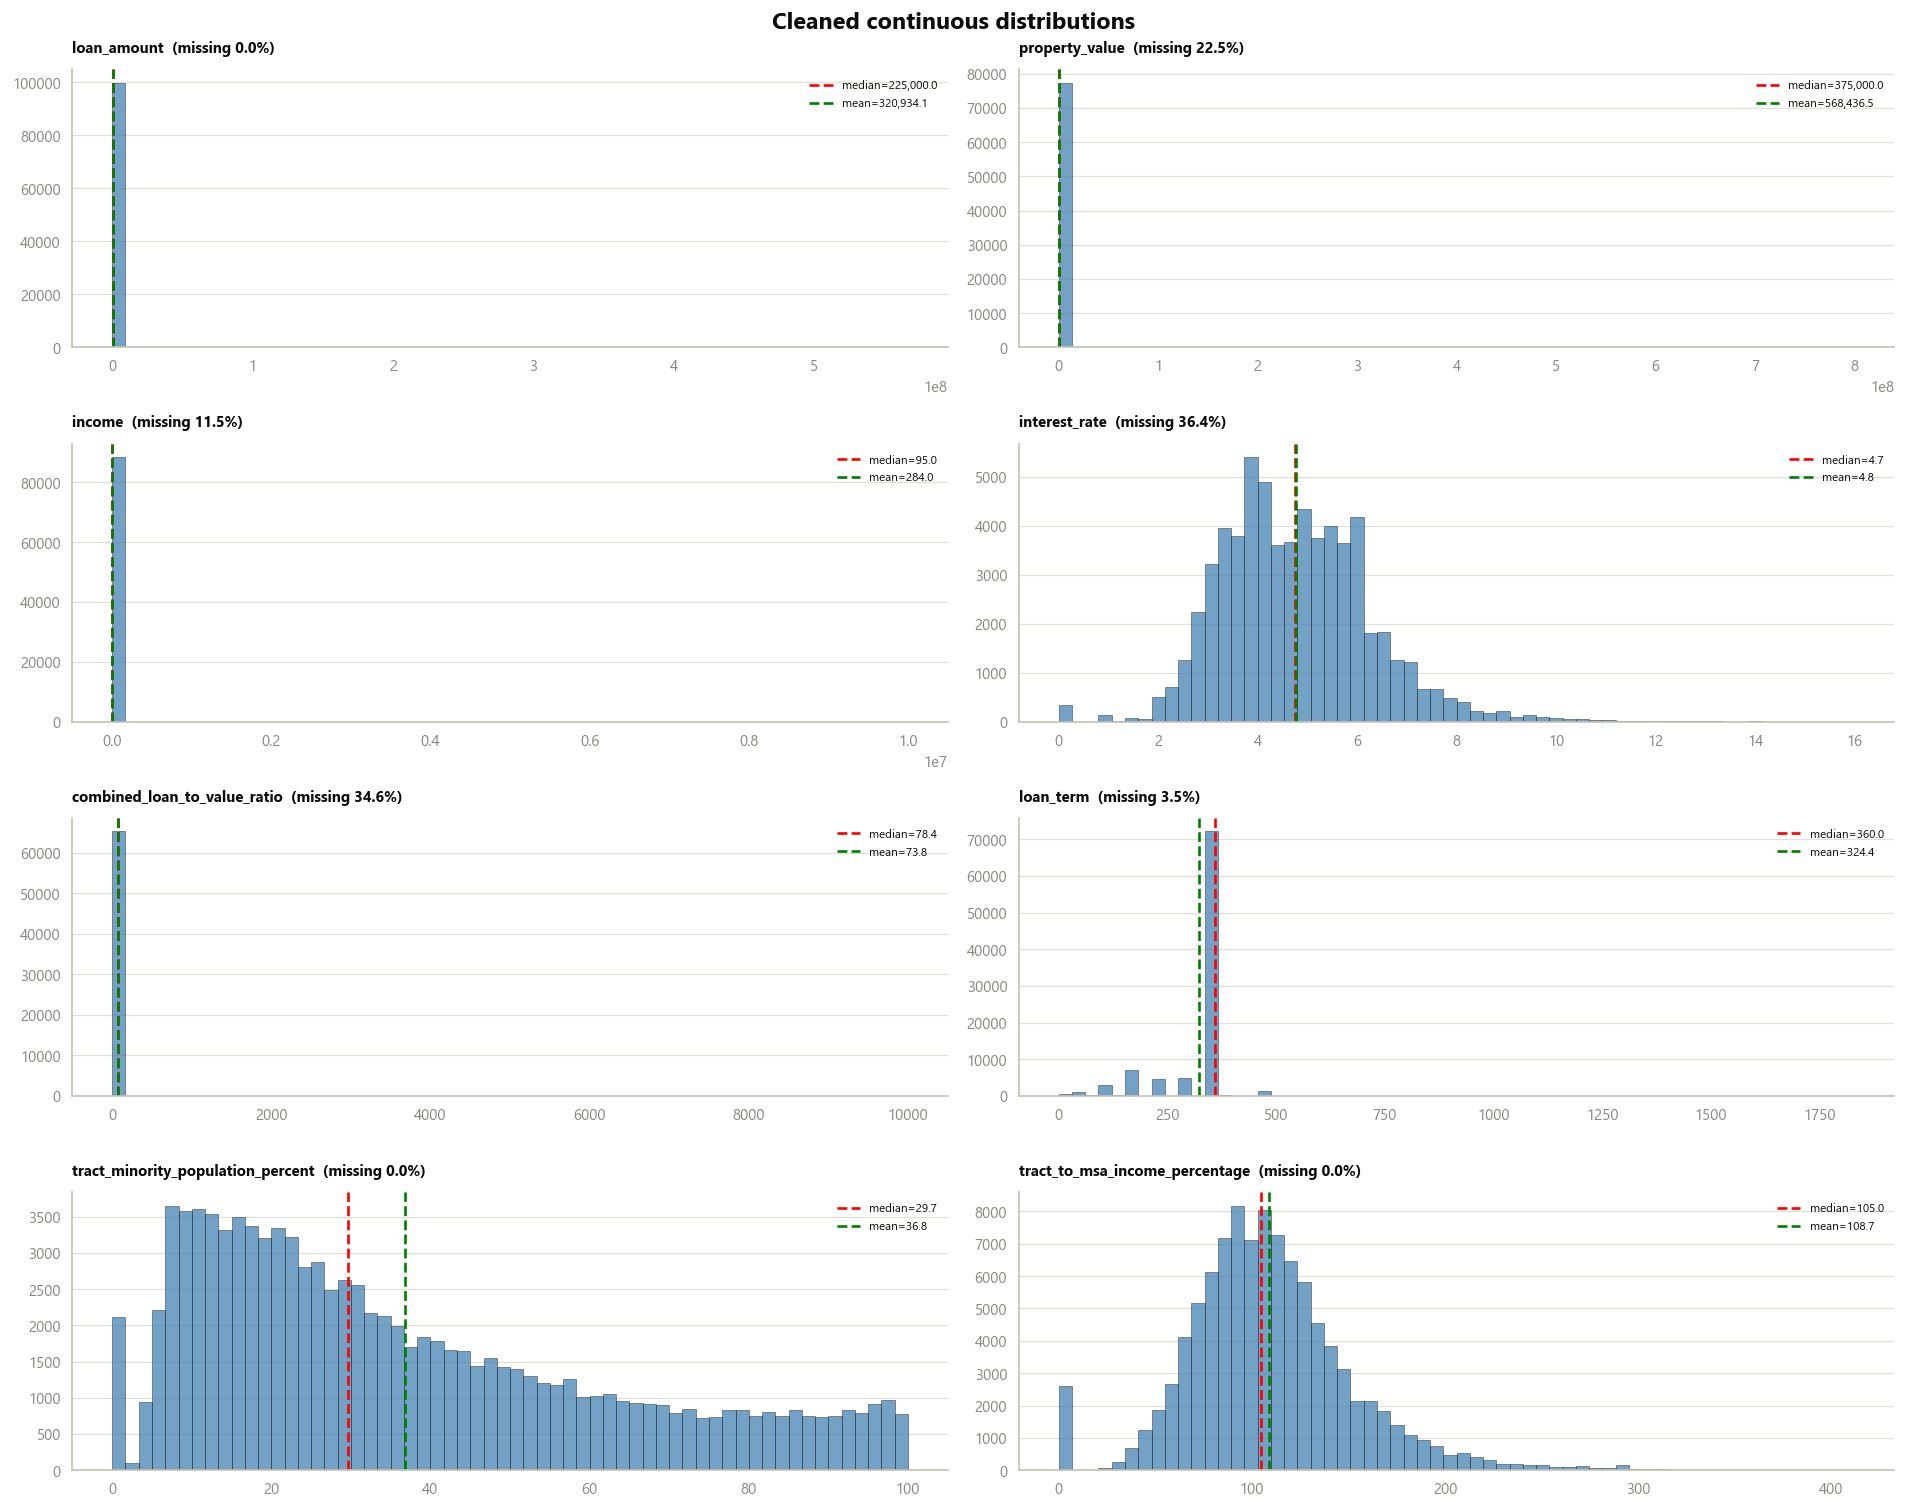

In [303]:
# 6b
key_cont = [c for c in ["loan_amount", "property_value", "income", "interest_rate",
                        "combined_loan_to_value_ratio", "loan_term",
                        "tract_minority_population_percent", "tract_to_msa_income_percentage"]
            if c in df.columns]

if key_cont:
    nrows = (len(key_cont) + 1) // 2
    fig, axes = plt.subplots(nrows, 2, figsize=(16, nrows * 3.2))
    axes = np.atleast_1d(axes).flatten()
    for i, col in enumerate(key_cont):
        d = df[col].dropna()
        if len(d):
            axes[i].hist(d, bins=60, color="steelblue", alpha=0.75, edgecolor="black", linewidth=0.3)
            axes[i].axvline(d.median(), color="red", ls="--", lw=1.6, label=f"median={d.median():,.1f}")
            axes[i].axvline(d.mean(), color="green", ls="--", lw=1.6, label=f"mean={d.mean():,.1f}")
            axes[i].set_title(f"{col}  (missing {df[col].isna().mean()*100:.1f}%)", fontsize=9, fontweight="bold")
            axes[i].legend(fontsize=7)
    for j in range(len(key_cont), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Cleaned continuous distributions", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "p1_continuous_distributions.png", bbox_inches="tight")
    plt.show()

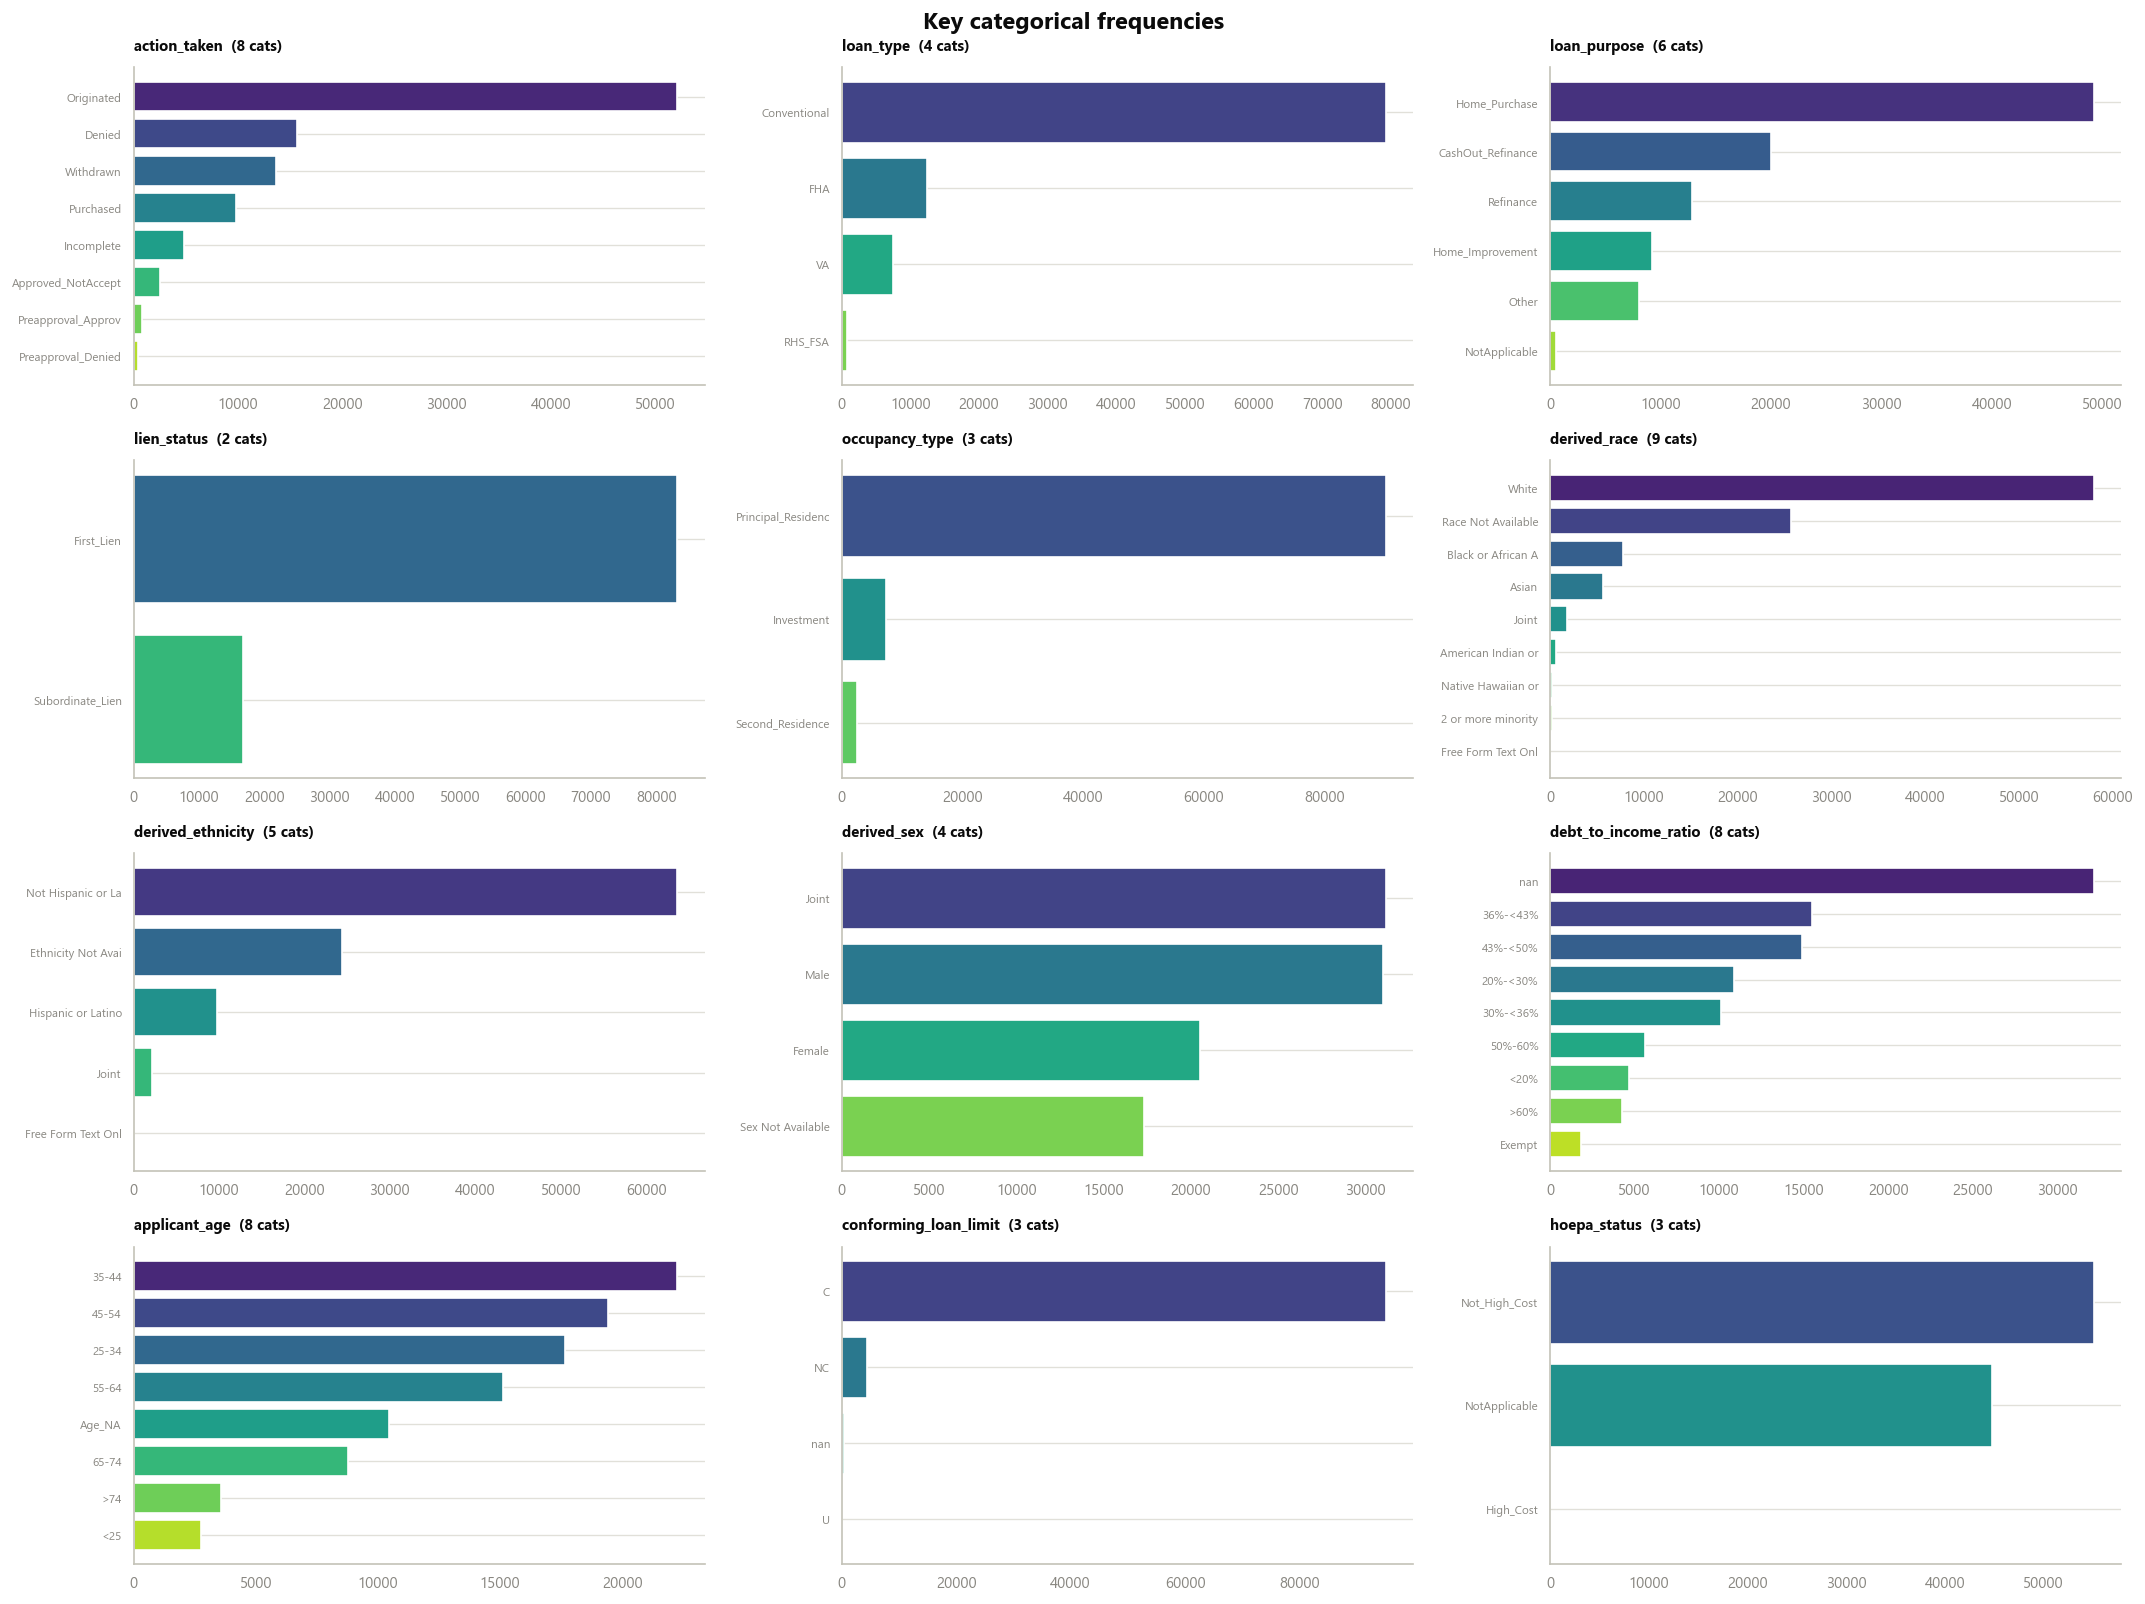

In [304]:
# 6c
key_cat = [c for c in ["action_taken", "loan_type", "loan_purpose", "lien_status", "occupancy_type",
                       "derived_race", "derived_ethnicity", "derived_sex", "debt_to_income_ratio",
                       "applicant_age", "conforming_loan_limit", "hoepa_status"]
           if c in df.columns]

if key_cat:
    ncols = 3
    nrows = (len(key_cat) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.4))
    axes = np.atleast_1d(axes).flatten()
    for i, col in enumerate(key_cat):
        vc = df[col].value_counts(dropna=False).head(10)
        axes[i].barh(range(len(vc)), vc.values, color=sns.color_palette("viridis", len(vc)))
        axes[i].set_yticks(range(len(vc)))
        axes[i].set_yticklabels([str(x)[:18] for x in vc.index], fontsize=7)
        axes[i].invert_yaxis()
        axes[i].set_title(f"{col}  ({df[col].nunique()} cats)", fontsize=9, fontweight="bold")
    for j in range(len(key_cat), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Key categorical frequencies", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "p1_categorical_frequencies.png", bbox_inches="tight")
    plt.show()

In [305]:
# 6d
rows = []
for col in [c for c in CONTINUOUS if c in df.columns]:
    d = df[col].dropna()
    if len(d) < 100:
        continue
    q1, q3 = d.quantile(0.25), d.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((d < lo) | (d > hi)).sum())
    rows.append({"feature": col, "median": round(d.median(), 2), "IQR": round(iqr, 2),
                 "lower": round(lo, 2), "upper": round(hi, 2),
                 "n_outliers": n_out, "outlier_pct": round(n_out / len(d) * 100, 2),
                 "min": round(d.min(), 2), "max": round(d.max(), 2)})
iqr_df = pd.DataFrame(rows).sort_values("outlier_pct", ascending=False)
print("IQR outlier scan (cleaned continuous):")
print(iqr_df.to_string(index=False))

IQR outlier scan (cleaned continuous):
                          feature    median       IQR      lower      upper  n_outliers  outlier_pct      min          max
                        loan_term    360.00      0.00     360.00     360.00       24601        25.50     1.00      1830.00
          prepayment_penalty_term     36.00     12.00       6.00      54.00         584        15.26     0.00       180.00
                   lender_credits    300.00   1035.63   -1499.25    2643.27        1902        11.64     0.01     35270.66
     multifamily_affordable_units      0.00      0.00       0.00       0.00          28         9.52     0.00       100.00
                           income     95.00     89.00     -72.50     283.50        6432         7.26 -2058.00  10000000.00
                      rate_spread      0.36      0.99      -1.60       2.37        3515         7.19    -7.17        12.27
ffiec_msa_md_median_family_income  90400.00  21900.00   47050.00  134650.00        7001         7.00

## 7 - Penanganan missing value

1. **Membuang fitur yang sebagian besar kosong karena desain data** menggunakan ambang berbasis data `>60%`. Fitur yang diperkirakan terbuang meliputi blok biaya pinjaman, `prepayment_penalty_term`, `intro_rate_period`, dan `multifamily_affordable_units`, yang lebih dari 70% berisi Exempt/NA pada sampel nasional dan memiliki nilai penemuan rendah.
2. **Menambahkan indikator missingness** untuk fitur kontinu penting sebelum imputasi, sehingga Fase 3 masih dapat menemukan pola seperti “`property_value` missing ⇒ tingkat denial lebih tinggi”.
3. **Mengimputasi fitur kontinu dengan median**, yang lebih tahan terhadap right-skew berat pada fitur nominal uang dan tetap mudah diinterpretasikan.
4. **Mengisi missing kategorikal tersisa dengan `Unknown`**. Missing struktural sebelumnya telah dipertahankan sebagai `Exempt`, `No_CoApplicant`, atau `Age_NA`.

In [306]:
MISSING_DROP_THRESHOLD = cfg.MISSING_DROP_THRESHOLD
df, miss, high_missing, signal_cont, residual_missing_after_cleaning, missing_columns_after_cleaning = \
    p1.handle_missing(df, MISSING_DROP_THRESHOLD)

print(f"Dropped {len(high_missing)} fields with >{MISSING_DROP_THRESHOLD:.0%} missing:")
print("  ", high_missing)
print(f"Remaining columns: {df.shape[1]}")
print(f"Added missingness indicators for: {signal_cont}")

print(f"\nRemaining missing values: {residual_missing_after_cleaning} (should be 0)")
assert residual_missing_after_cleaning == 0, (
    "Missing-value handling is incomplete. Remaining columns: "
    f"{missing_columns_after_cleaning}"
)


Dropped 6 fields with >60% missing:
   ['total_points_and_fees', 'discount_points', 'lender_credits', 'prepayment_penalty_term', 'intro_rate_period', 'multifamily_affordable_units']
Remaining columns: 53
Added missingness indicators for: ['property_value', 'income', 'combined_loan_to_value_ratio', 'interest_rate', 'loan_term']

Remaining missing values: 0 (should be 0)


**Validasi — missingness setiap fitur dan perlakuan akhirnya.** Persentase missing sebelum penanganan divisualisasikan dan diberi kategori berdasarkan tindakan pada langkah 7: dibuang (`>60%`), diimputasi median untuk fitur kontinu, atau diisi `Unknown` untuk fitur kategorikal. Garis ambang membuat aturan drop dapat diaudit. Fitur yang memiliki indikator `_was_missing` juga ditandai agar informasi yang hilang akibat imputasi terbukti tetap tersedia untuk rule mining.

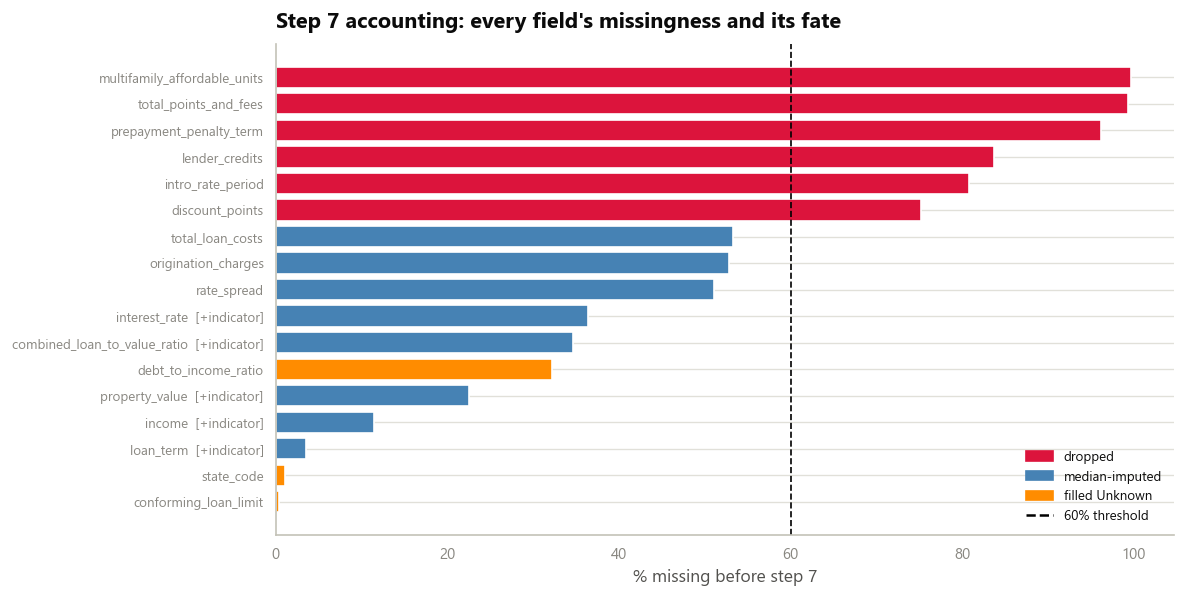

In [307]:
fate, pct = {}, miss[miss > 0].sort_values(ascending=False)
for col in pct.index:
    if col in high_missing:
        fate[col] = ("dropped", "crimson")
    elif col in CONTINUOUS:
        fate[col] = ("median-imputed", "steelblue")
    else:
        fate[col] = ("filled Unknown", "darkorange")

fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(pct))))
ax.barh(range(len(pct)), pct.values * 100, color=[fate[c][1] for c in pct.index])
ax.set_yticks(range(len(pct)))
ax.set_yticklabels([f"{c}  [+indicator]" if f"{c}_was_missing" in df.columns else c
                    for c in pct.index], fontsize=8)
ax.invert_yaxis()
ax.axvline(MISSING_DROP_THRESHOLD * 100, color="black", ls="--", lw=1, label="60% drop threshold")
ax.set_xlabel("% missing before step 7")
ax.set_title("Step 7 accounting: every field's missingness and its fate", fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="crimson", label="dropped"),
                   Patch(color="steelblue", label="median-imputed"),
                   Patch(color="darkorange", label="filled Unknown"),
                   plt.Line2D([0], [0], color="black", ls="--", label="60% threshold")],
          fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "p1_missingness_fate.png", bbox_inches="tight")
plt.show()


## 8 - Transformasi data: pembentukan target dan binning

- **Pembentukan outcome untuk penemuan, bukan prediksi:** `target_approved` (`Originated`=1 dan `Denied`=0) hanya berada pada subset analisis. Tabel bersih lengkap tetap bebas target untuk Fase 2 dan 4 yang bersifat unsupervised. Hal ini sesuai dengan tujuan analisis, yaitu mengurutkan kekuatan asosiasi atribut terhadap keputusan, bukan melatih classifier.
- **Binning untuk association rule mining:** fitur kontinu diubah menjadi band domain yang mudah diinterpretasikan. Jumlah anggota setiap band dicetak untuk memastikan tidak ada kategori kosong. Dua band yang relevan terhadap analisis redlining, yaitu `tract_income_cat` dan `tract_minority_cat`, disertakan karena proyek secara eksplisit membahas geografi dan demografi.
- **Scaling** ditunda ke bagian Jembatan: `StandardScaler` setelah winsorization untuk clustering dan `RobustScaler` untuk anomaly detection. Langkah ini menghindari pembuatan salinan penuh DataFrame pada tahap ini.

In [308]:
df, approve_deny = p1.frame_target_and_bin(df)
bin_specs = cfg.bin_specs

if "action_taken" in df.columns:
    print(f"Approve-vs-Deny analysis subset: {len(approve_deny):,} rows "
          f"(approval rate {approve_deny['target_approved'].mean()*100:.1f}%)")
    print(f"Full table keeps all {len(df):,} rows (incl. withdrawn/incomplete) for clustering/anomaly.")

print("Binning complete. Band distributions (check for empty bands):")
for new_col in bin_specs:
    if new_col in df.columns:
        print(f"\n{new_col}:")
        print(df[new_col].value_counts(dropna=False).sort_index().to_string())


Approve-vs-Deny analysis subset: 67,827 rows (approval rate 76.9%)
Full table keeps all 99,995 rows (incl. withdrawn/incomplete) for clustering/anomaly.
Binning complete. Band distributions (check for empty bands):

income_band:
income_band
<30k         4311
30-50k      10560
50-75k      17650
75-100k     26459
100-150k    18996
150-200k     9222
>200k       12797

loan_amount_band:
loan_amount_band
<100k       19351
100-200k    24640
200-300k    20733
300-500k    22017
500-750k     8712
>750k        4542

property_value_band:
property_value_band
<100k        2588
100-200k    10864
200-350k    22194
350-500k    39501
500-750k    13433
>750k       11415

interest_rate_band:
interest_rate_band
<3%      7269
3-4%    15902
4-5%    51467
5-6%    14486
6-7%     6804
>7%      4067

cltv_band:
cltv_band
<60%       16088
60-80%     60681
80-90%      8439
90-95%      5285
95-100%     7638
>100%       1864

tract_income_cat:
tract_income_cat
Low_Income          5505
Moderate_Income    17589
Middl

**Validasi — batas bin harus menghasilkan kategori yang berisi data dan relevan terhadap outcome.** Jumlah data per band ditampilkan sebagai batang dan approval rate per band sebagai garis pada subset yang memiliki keputusan. Pola yang diharapkan, yaitu approval meningkat seiring income dan menurun seiring CLTV, menunjukkan bahwa batas bin ditempatkan pada perubahan perilaku lending yang bermakna, sejalan dengan perlakuan DTI pada langkah 3.

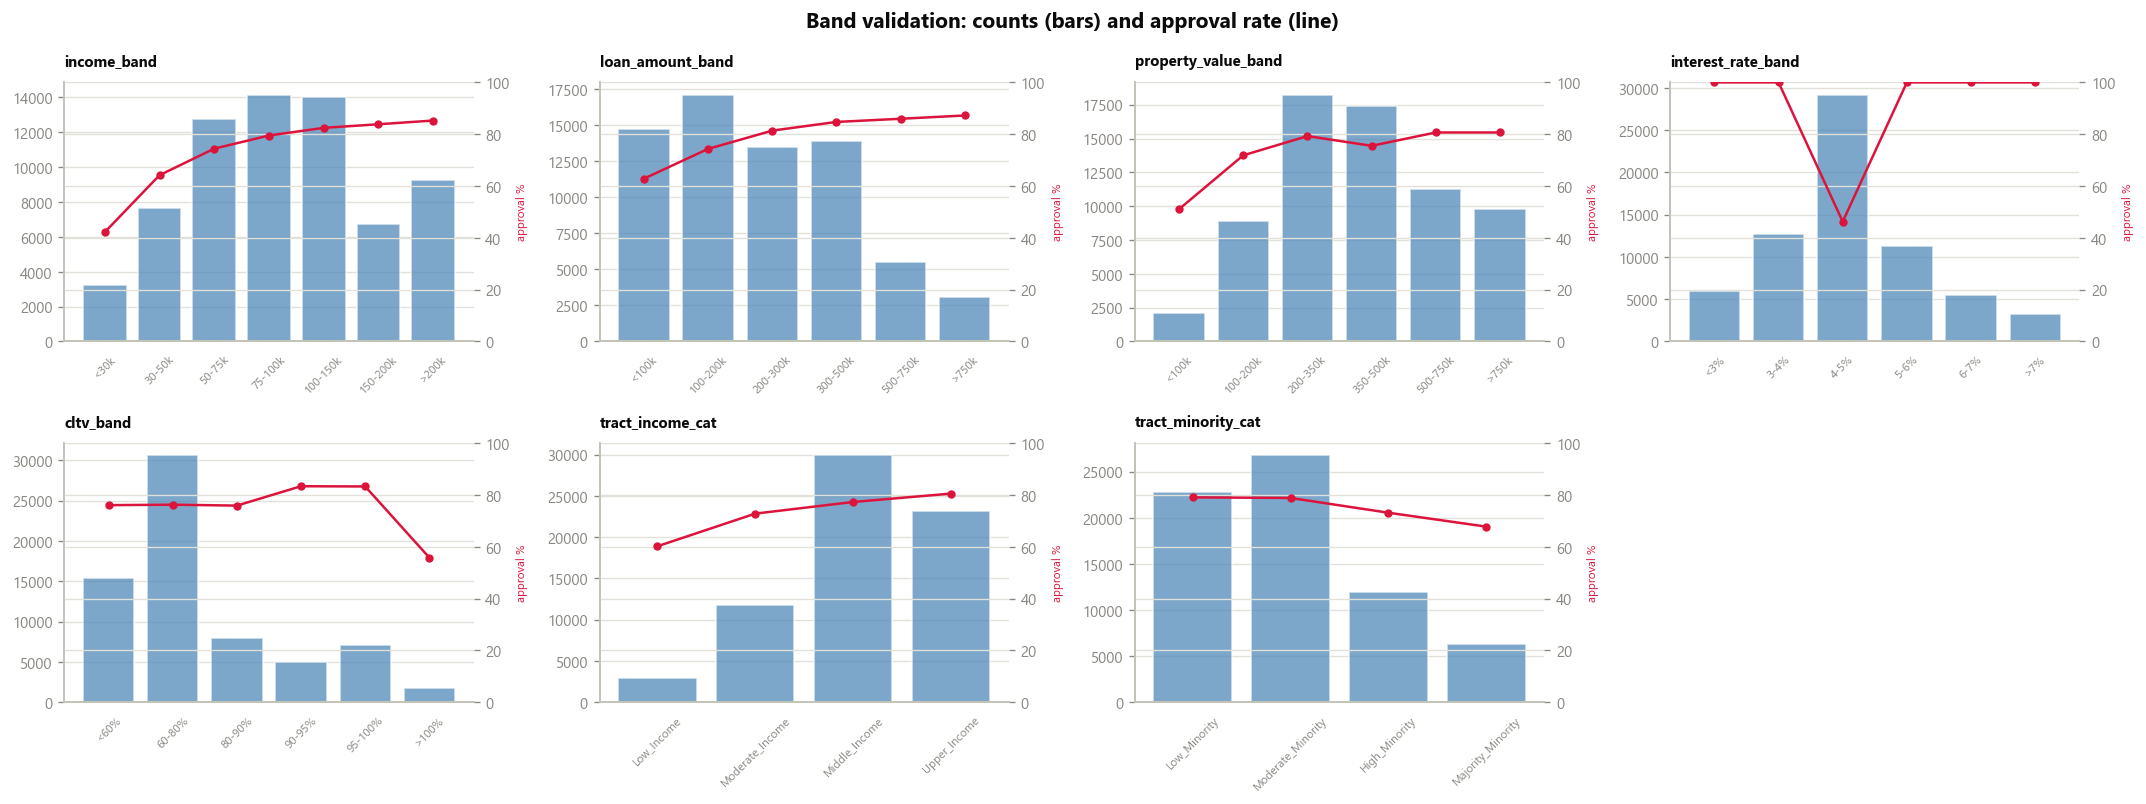

In [309]:
band_cols = [c for c in bin_specs if c in approve_deny.columns]
ncols = 4
nrows = (len(band_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.4))
axes = np.atleast_1d(axes).flatten()
for ax, col in zip(axes, band_cols):
    g = approve_deny.groupby(col, observed=True)["target_approved"].agg(["size", "mean"])
    ax.bar(range(len(g)), g["size"], color="steelblue", alpha=0.7)
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels(g.index, rotation=45, fontsize=7)
    ax2 = ax.twinx()
    ax2.plot(range(len(g)), g["mean"] * 100, color="crimson", marker="o", ms=4)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("approval %", fontsize=7, color="crimson")
    ax.set_title(col, fontsize=9, fontweight="bold")
for ax in axes[len(band_cols):]:
    ax.set_visible(False)
plt.suptitle("Band validation: counts (bars) and approval rate (line)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p1_band_validation.png", bbox_inches="tight")
plt.show()


## 9 - Seleksi fitur: korelasi dan **Mutual Information berbasis entropi**

Seleksi fitur menjawab beberapa pertanyaan berbeda sehingga digunakan ukuran yang saling melengkapi:

1. **Korelasi dengan outcome:** korelasi point-biserial, yang ekuivalen dengan Pearson untuk target biner, mengukur arah dan kekuatan hubungan linear terhadap `target_approved`.
2. **Pemeriksaan redundansi — dua tingkat.** *Pairwise* (9b): pasangan fitur numerik dengan `|r| > 0.90` ditandai agar informasi duplikat tidak mendominasi clustering atau interpretasi. *Multivariat* (9c): ambang pairwise tidak dapat melihat redundansi yang hanya muncul sebagai kombinasi beberapa fitur sekaligus, sehingga VIF dihitung untuk setiap fitur numerik. Keduanya menggunakan ambang yang identik karena `VIF = 1 / (1 - R²)`, sehingga `VIF > 10` setara dengan `R² > 0,90`.
3. **Mutual Information (MI) berbasis entropi:** `mutual_info_classif` mengukur ketergantungan non-linear antara setiap fitur dan outcome keputusan. Fitur kategorikal diperlakukan sebagai nilai diskrit, bukan angka berurutan.
4. **Bukti gabungan:** nilai absolut korelasi yang telah dinormalisasi dan MI digabungkan menjadi tabel relevansi yang dapat diaudit.

Fitur pricing dan cost yang terbentuk setelah outcome dikeluarkan sebelum penilaian. Flag missingness yang terutama menunjukkan sejauh mana aplikasi telah diproses tetap dilaporkan sebagai **diagnostik proses**, tetapi tidak dimasukkan ke feature set Fase 2–4. Bagian Jembatan mendokumentasikan pilihan fitur akhir per fase beserta bukti sumbernya.

Top 20 |correlation| with approval (Originated=1 vs Denied=0):
  down combined_loan_to_value_ratio_was_missing   -0.1561
  down property_value_was_missing                 -0.1318
  up  tract_to_msa_income_percentage             +0.0941
  down tract_minority_population_percent          -0.0779
  up  ffiec_msa_md_median_family_income          +0.0635
  up  tract_owner_occupied_units                 +0.0577
  up  loan_amount                                +0.0437
  up  any_exempt_field                           +0.0389
  up  tract_one_to_four_family_homes             +0.0385
  up  tract_population                           +0.0334
  down loan_term_was_missing                      -0.0281
  up  income_was_missing                         +0.0277
  up  loan_term                                  +0.0136
  up  property_value                             +0.0077
  down combined_loan_to_value_ratio               -0.0076
  down income                                     -0.0058
  up  tract_median_

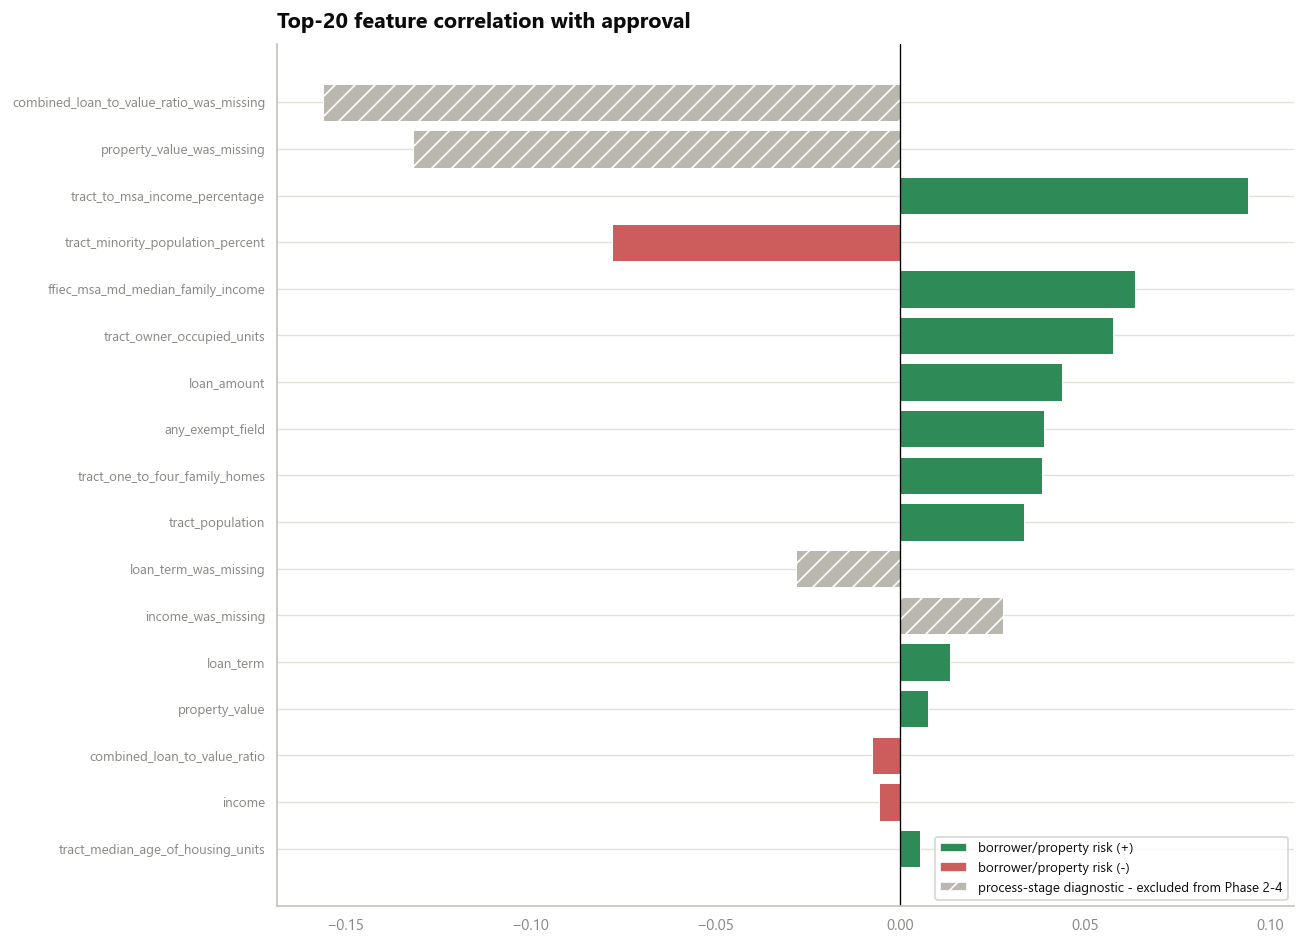

In [310]:
corr_target, mi_series, comb, num_feats = p1.score_features(approve_deny, RANDOM_STATE)
LEAKAGE = cfg.LEAKAGE

print("Top 20 |correlation| with approval (Originated=1 vs Denied=0):")
for f, c in corr_target.head(20).items():
    arrow = "up " if c > 0 else "down"
    print(f"  {arrow} {f:42s} {c:+.4f}")

# Korelasi teratas dikuasai indikator `_was_missing`, yang mengukur sejauh mana
# aplikasi telah diproses, bukan risiko borrower. Indikator itu memang sengaja
# dikecualikan dari feature set Fase 2-4 (lihat 9e), tetapi figure ini beredar
# terpisah dari teksnya. Batang tersebut karena itu diberi arsir dan warna abu-abu
# agar gambar tidak dapat dibaca terbalik oleh orang yang hanya melihat gambarnya.
fig, ax = plt.subplots(figsize=(11, 8))
top = corr_target.head(20)
is_proc = [str(f).endswith("_was_missing") for f in top.index]
ax.barh(range(len(top)), top.values,
        color=["#b9b7ae" if p else ("seagreen" if v > 0 else "indianred")
               for v, p in zip(top.values, is_proc)],
        hatch=["//" if p else "" for p in is_proc],
        edgecolor="white", linewidth=0.6)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top-20 feature correlation with approval", fontsize=13, fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="seagreen", label="borrower/property risk (+)"),
                   Patch(facecolor="indianred", label="borrower/property risk (-)"),
                   Patch(facecolor="#b9b7ae", hatch="//",
                         label="process-stage diagnostic - excluded from Phase 2-4")],
          fontsize=8, loc="lower right", frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "p1_correlation_with_target.png", bbox_inches="tight")
plt.show()


In [311]:
# 9b
cmat = approve_deny[num_feats].corr().abs()
upper = cmat.where(np.triu(np.ones(cmat.shape), k=1).astype(bool))
redundant_pairs = [(r, c, round(upper.loc[r, c], 3))
                   for r in upper.index for c in upper.columns
                   if pd.notna(upper.loc[r, c]) and upper.loc[r, c] > 0.90]
print(f"Highly-correlated pairs (|r|>0.90): {len(redundant_pairs)}")
for a, b, v in redundant_pairs:
    print(f"  {a}  <->  {b}   r={v}")

Highly-correlated pairs (|r|>0.90): 0


### 9c - Audit multikolinearitas: dari pairwise ke multivariat

Cek 9b membandingkan fitur **berpasangan**. Uji itu tidak dapat menemukan redundansi yang hanya muncul ketika beberapa fitur digabung: tiga fitur dapat masing-masing berkorelasi sedang terhadap fitur keempat, namun kombinasi liniernya merekonstruksi fitur tersebut hampir sempurna, dan tidak satu pun pasangan akan melewati ambang `0,90`. Ukuran yang tepat adalah **Variance Inflation Factor**, yaitu `VIFᵢ = 1 / (1 - R²ᵢ)` dengan `R²ᵢ` berasal dari regresi fitur *i* terhadap seluruh fitur numerik lainnya. Ambangnya dibuat identik dengan 9b: `VIF > 10` persis berarti `R² > 0,90`.

**Uji khusus — apakah DTI dapat direkonstruksi dari fitur ukuran?** `income`, `loan_amount`, dan `property_value` tampak tumpang tindih dengan `debt_to_income_ratio`, sehingga muncul pertanyaan wajar mengapa keduanya sama-sama masuk `ITEM_FEATURES`. Pertanyaan itu tidak dapat dijawab oleh 9b karena dua alasan struktural. Pertama, ia multivariat, seperti dijelaskan di atas. Kedua, dan lebih menentukan, bentuk tumpang tindihnya adalah **rasio** — komponen DTI yang memang berasal dari pinjaman ini kira-kira `loan_amount / income` — sedangkan korelasi Pearson pada kolom mentah hanya mengukur hubungan linear dan tidak akan pernah memunculkannya. Rasio tersebut karena itu dibentuk secara eksplisit lalu diuji.

Secara teori nilainya tidak akan mendekati satu, dan tiga alasannya bersifat struktural, bukan kebetulan sampel:

1. **Utang lain tidak terekam.** Pembilang DTI mencakup seluruh kewajiban bulanan — cicilan kendaraan, kartu kredit, student loan — dan tidak ada satu pun kolom HMDA yang memuatnya.
2. **Cicilan bulanan bukan pokok pinjaman.** Pembilang DTI adalah arus bulanan yang bergantung pada bunga dan tenor, sedangkan `loan_amount` adalah stok. `interest_rate` sendiri sudah dikeluarkan sebagai fitur pasca-keputusan.
3. **DTI telah dikoarsakan.** HMDA hanya menerbitkan bilangan bulat eksak pada `36 ≤ DTI < 50`; sisanya berupa rentang, sehingga variabel ini hanya memiliki tujuh tingkat ordinal.

Angka di bawah menggantikan penalaran tersebut dengan bukti. Hasil `R²` yang rendah mengubah klaim yang dapat dipertahankan dari “tidak ada pasangan yang melewati 0,90” menjadi “DTI tidak dapat direkonstruksi dari fitur ukuran”, dan hanya klaim kedua yang benar-benar menjawab pertanyaannya.

In [312]:
# 9c - VIF: padanan multivariat dari cek pairwise 9b.
# VIF_i = elemen diagonal ke-i dari invers matriks korelasi = 1 / (1 - R^2_i),
# jadi VIF > 10 persis setara dengan R^2 > 0.90 -- ambang yang sama dengan 9b,
# hanya diterapkan pada dimensi yang benar. Digunakan pinv agar matriks yang
# singular (kolinearitas sempurna) tetap menghasilkan angka, bukan exception.
VIF_THRESHOLD = 10.0

Xv = approve_deny[num_feats].apply(pd.to_numeric, errors="coerce").dropna()
Xv = Xv.loc[:, Xv.std() > 0]

R = np.corrcoef(Xv.values, rowvar=False)
vif = pd.Series(np.diag(np.linalg.pinv(R)), index=Xv.columns).sort_values(ascending=False)

print(f"VIF pada {Xv.shape[1]} fitur numerik ({len(Xv):,} baris lengkap). "
      f"VIF>{VIF_THRESHOLD:.0f} setara R^2>{1 - 1/VIF_THRESHOLD:.2f}:")
print(vif.head(15).round(2).to_string())

vif_flagged = vif[vif > VIF_THRESHOLD]
print(f"\nFitur di atas ambang: {len(vif_flagged)}"
      + (f" -> {list(vif_flagged.index)}" if len(vif_flagged) else
         "  (tidak ada; sejalan dengan 0 pasangan pada cek pairwise 9b)"))

VIF pada 17 fitur numerik (67,827 baris lengkap). VIF>10 setara R^2>0.90:
tract_owner_occupied_units                  6.00
tract_one_to_four_family_homes              4.05
tract_population                            3.58
any_exempt_field                            2.95
property_value_was_missing                  2.61
loan_term_was_missing                       2.29
combined_loan_to_value_ratio_was_missing    2.00
tract_minority_population_percent           1.51
loan_amount                                 1.30
tract_to_msa_income_percentage              1.29
property_value                              1.27
ffiec_msa_md_median_family_income           1.14
tract_median_age_of_housing_units           1.11
income_was_missing                          1.08
loan_term                                   1.05

Fitur di atas ambang: 0  (tidak ada; sejalan dengan 0 pasangan pada cek pairwise 9b)


In [313]:
# 9c (lanjutan) - Dapatkah DTI direkonstruksi dari fitur ukuran?
# Ini uji terarah, bukan sekadar VIF: DTI dikeluarkan dari ruang fitur numerik oleh
# binning, sehingga tidak muncul di tabel di atas. Rasio loan_amount/income dibentuk
# eksplisit karena bentuk tumpang tindih yang dipertanyakan adalah rasio, dan korelasi
# Pearson pada kolom mentah secara definisi tidak dapat melihatnya.
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

DTI_MIDPOINT = {"<20%": 15.0, "20%-<30%": 25.0, "30%-<36%": 33.0, "36%-<43%": 39.5,
                "43%-<50%": 46.5, "50%-60%": 55.0, ">60%": 65.0}   # 'Exempt'/'Unknown' -> NaN

if "debt_to_income_ratio" in approve_deny.columns:
    y = approve_deny["debt_to_income_ratio"].astype(str).map(DTI_MIDPOINT)

    inc = pd.to_numeric(approve_deny["income"], errors="coerce") * 1000   # HMDA: ribuan USD
    amt = pd.to_numeric(approve_deny["loan_amount"], errors="coerce")
    pv = pd.to_numeric(approve_deny["property_value"], errors="coerce")
    inc_pos = inc.clip(lower=1)   # income <= 0 valid (rugi usaha), tetapi tidak bisa jadi penyebut

    Xd = pd.DataFrame({
        "log_income": np.log1p(inc_pos),
        "log_loan_amount": np.log1p(amt.clip(lower=0)),
        "log_property_value": np.log1p(pv.clip(lower=0)),
        "loan_to_income": (amt / inc_pos).clip(upper=20),
    })

    ok = y.notna() & Xd.notna().all(axis=1) & np.isfinite(Xd).all(axis=1)
    Xd, yd = Xd[ok], y[ok]

    print(f"DTI dipetakan ke titik tengah band; {len(yd):,} dari {len(y):,} baris terpakai "
          f"({(~y.notna()).sum():,} Exempt/Unknown dibuang).\n")
    print("Spearman terhadap DTI (monoton, tahan skew):")
    for c in Xd.columns:
        print(f"  {c:20s} rho = {spearmanr(Xd[c], yd)[0]:+.3f}")

    r2 = float(LinearRegression().fit(Xd, yd).score(Xd, yd))
    print(f"\nR^2 (DTI ~ ketiga fitur ukuran + rasio) = {r2:.3f}"
          f"   -> VIF setara = {1 / max(1 - r2, 1e-9):.2f}")
    print("VERDICT:", (
        "DTI TIDAK dapat direkonstruksi dari fitur ukuran; keduanya membawa informasi "
        "berbeda dan sama-sama layak dipertahankan di ITEM_FEATURES."
        if r2 < 1 - 1 / VIF_THRESHOLD else
        "DTI sebagian besar dapat direkonstruksi; tinjau ulang apakah keduanya perlu "
        "dipertahankan bersama pada fitur berbasis jarak."))
    print(f"Sisa varians {1 - r2:.1%} sejalan dengan tiga alasan struktural di atas: "
          "utang non-hipotek tidak terekam, cicilan bergantung pada bunga dan tenor, "
          "serta DTI hanya diterbitkan sebagai tujuh tingkat ordinal.")
else:
    print("debt_to_income_ratio tidak tersedia; uji rekonstruksi dilewati.")

DTI dipetakan ke titik tengah band; 62,618 dari 67,827 baris terpakai (5,209 Exempt/Unknown dibuang).

Spearman terhadap DTI (monoton, tahan skew):
  log_income           rho = -0.330
  log_loan_amount      rho = +0.057
  log_property_value   rho = +0.007
  loan_to_income       rho = +0.373

R^2 (DTI ~ ketiga fitur ukuran + rasio) = 0.100   -> VIF setara = 1.11
VERDICT: DTI TIDAK dapat direkonstruksi dari fitur ukuran; keduanya membawa informasi berbeda dan sama-sama layak dipertahankan di ITEM_FEATURES.
Sisa varians 90.0% sejalan dengan tiga alasan struktural di atas: utang non-hipotek tidak terekam, cicilan bergantung pada bunga dan tenor, serta DTI hanya diterbitkan sebagai tujuh tingkat ordinal.


Top 20 features by mutual information (entropy) with approval:
  debt_to_income_ratio                       0.09039
  combined_loan_to_value_ratio               0.03899
  income                                     0.02866
  loan_purpose                               0.02621
  income_band                                0.02483
  loan_amount                                0.02416
  loan_term                                  0.02202
  property_value                             0.01812
  lien_status                                0.01129
  tract_minority_population_percent          0.01127
  property_value_was_missing                 0.00918
  combined_loan_to_value_ratio_was_missing   0.00860
  tract_population                           0.00857
  ffiec_msa_md_median_family_income          0.00761
  derived_race                               0.00677
  tract_one_to_four_family_homes             0.00631
  derived_sex                                0.00606
  cltv_band                         

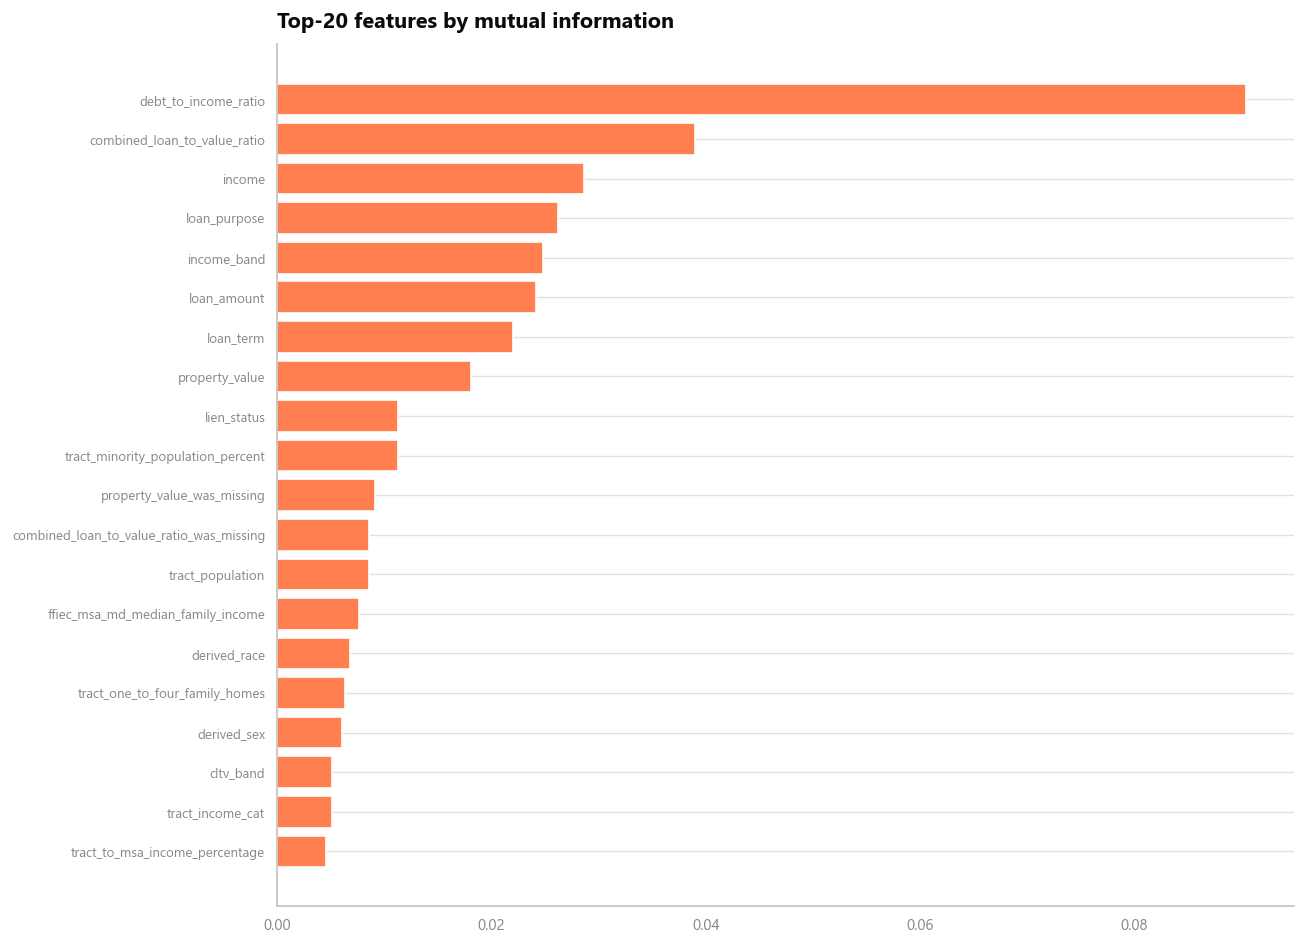

In [314]:
print("Top 20 features by mutual information (entropy) with approval:")
for f, s in mi_series.head(20).items():
    print(f"  {f:42s} {s:.5f}")

fig, ax = plt.subplots(figsize=(11, 8))
top = mi_series.head(20)
ax.barh(range(len(top)), top.values, color="coral")
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=8)
ax.invert_yaxis()
ax.set_title("Top-20 features by mutual information", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p1_mutual_information.png", bbox_inches="tight")
plt.show()


In [315]:
strong = comb[comb.score > 0.15]["feature"].tolist()
moderate = comb[(comb.score > 0.05) & (comb.score <= 0.15)]["feature"].tolist()
weak = comb[comb.score <= 0.05]["feature"].tolist()

print("Combined importance (correlation + entropy) -- top 20:")
print(comb.head(20)[["feature", "corr", "mi", "score"]].to_string(index=False))
print(f"\nSTRONG (score>0.15): {len(strong)}\n  {strong}")
print(f"MODERATE (0.05-0.15): {len(moderate)}")
print(f"WEAK (<=0.05): {len(weak)}")


Combined importance (correlation + entropy) -- top 20:
                                 feature      corr       mi    score
combined_loan_to_value_ratio_was_missing -0.156060 0.008600 0.547572
                    debt_to_income_ratio       NaN 0.090390 0.500000
              property_value_was_missing -0.131825 0.009184 0.473157
          tract_to_msa_income_percentage  0.094092 0.004527 0.326501
       tract_minority_population_percent -0.077914 0.011268 0.311959
                             loan_amount  0.043658 0.024162 0.273531
       ffiec_msa_md_median_family_income  0.063535 0.007615 0.245681
            combined_loan_to_value_ratio -0.007591 0.038994 0.240019
              tract_owner_occupied_units  0.057668 0.004062 0.207232
                                  income -0.005844 0.028657 0.177243
                               loan_term  0.013599 0.022019 0.165371
          tract_one_to_four_family_homes  0.038508 0.006309 0.158277
                        tract_population  0.0333

### 9e - Audit akhir seleksi fitur

Peringkat sebelumnya diubah menjadi tabel seleksi yang transparan. Fitur yang mengodekan tahap proses melalui missingness dilaporkan secara terpisah dan tidak digunakan sebagai input penemuan. Pemisahan ini mencegah korelasi tinggi akibat progres aplikasi disalahartikan sebagai faktor risiko borrower yang sesungguhnya.

In [316]:
feature_selection_audit, eligible_feature_ranking, PROCESS_STAGE_DIAGNOSTICS = p1.audit_feature_selection(comb)

print("Feature-selection audit (top 25):")
print(feature_selection_audit.head(25)[
    ["feature", "corr", "mi", "score", "role"]
].round({"corr": 4, "mi": 5, "score": 3}).to_string(index=False))
print("\nProcess-stage diagnostics excluded from Phase 2-4 inputs:")
print("  ", PROCESS_STAGE_DIAGNOSTICS)

feature_selection_audit.to_csv(TABLE_DIR / "p1_feature_selection_audit.csv", index=False)
print("\nSaved p1_feature_selection_audit.csv")


Feature-selection audit (top 25):
                                 feature    corr      mi  score                         role
combined_loan_to_value_ratio_was_missing -0.1561 0.00860  0.548      Process diagnostic only
                    debt_to_income_ratio     NaN 0.09039  0.500   Strong discovery candidate
              property_value_was_missing -0.1318 0.00918  0.473      Process diagnostic only
          tract_to_msa_income_percentage  0.0941 0.00453  0.327   Strong discovery candidate
       tract_minority_population_percent -0.0779 0.01127  0.312   Strong discovery candidate
                             loan_amount  0.0437 0.02416  0.274   Strong discovery candidate
       ffiec_msa_md_median_family_income  0.0635 0.00761  0.246   Strong discovery candidate
            combined_loan_to_value_ratio -0.0076 0.03899  0.240   Strong discovery candidate
              tract_owner_occupied_units  0.0577 0.00406  0.207   Strong discovery candidate
                                  in

## 10 - Mengekspor artefak yang siap dianalisis

In [317]:
p1.export_phase1(df, approve_deny, df_denials, comb, DATA_INTERIM, TABLE_DIR)

print("=" * 64)
print("PHASE 1 COMPLETE")
print("=" * 64)
print(f"  hmda_clean.csv            {df.shape[0]:,} x {df.shape[1]}   (labels+bands; rules/profiling)")
print(f"  hmda_approve_deny.csv     {approve_deny.shape[0]:,} x {approve_deny.shape[1]}   (primary mining table)")
print(f"  feature_ranking_combined.csv   (correlation + entropy)")
print(f"  hmda_denials.csv          {len(df_denials):,} denied rows (denial-reason analysis)")
print(f"\n  Duplicates removed: {n_dupes:,}")
print(f"  High-missing fields dropped: {len(high_missing)}")
print(f"  Residual missing values: {int(df.isna().sum().sum())}")


PHASE 1 COMPLETE
  hmda_clean.csv            99,995 x 60   (labels+bands; rules/profiling)
  hmda_approve_deny.csv     67,827 x 61   (primary mining table)
  feature_ranking_combined.csv   (correlation + entropy)
  hmda_denials.csv          15,684 denied rows (denial-reason analysis)

  Duplicates removed: 5
  High-missing fields dropped: 6
  Residual missing values: 0


---
# Jembatan antar fase

In [318]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

rng = np.random.default_rng(RANDOM_STATE)

In [319]:
# Salinan independen diperlukan pada bagian ini.
# Penggunaan `clean = df` akan membuat keduanya menunjuk DataFrame yang sama, sehingga kolom bantu berikutnya
# seperti `_approved = np.nan` dapat membuat audit preprocessing gagal secara keliru.
clean = df.copy(deep=True)
appdeny = approve_deny.copy(deep=True)
denials = df_denials.copy(deep=True)


## Peran fitur untuk Fase 2–4

- **`ANOMALY_FEATS`:** fitur dengan magnitudo mentah; nilai ekstrem seperti pinjaman $70 juta harus tetap terlihat.
- **`CLUSTER_FEATS`:** `loan_amount`, `property_value`, dan `income` saling berkorelasi karena semuanya merepresentasikan “ukuran”. Menggunakan ketiganya sekaligus menciptakan satu sumbu dominan sehingga K-Means hanya memisahkan pinjaman besar dan kecil. Satu proksi ukuran, yaitu income, dipertahankan lalu ditambah sumbu yang lebih ortogonal: leverage (CLTV), lokasi (persentase minoritas dan income tract), serta flag perilaku. Dengan demikian, segmen berbeda berdasarkan profil finansial dan lokasi, bukan hanya nominal uang.
- **`ITEM_FEATURES`:** fitur kategorikal atau band yang tersedia pada saat aplikasi untuk association rule mining; tidak mengandung outcome. **Redundansi sengaja tidak di-*pre-filter* di sini,** berbeda dengan perlakuan pada `CLUSTER_FEATS`. Alasannya adalah sifat algoritmanya: support, confidence, dan lift dihitung dari frekuensi itemset, bukan dari jarak, sehingga fitur yang berkorelasi tidak menggandakan bobot sumbu mana pun maupun membiaskan estimasinya. Membuang `income_band` atau `loan_amount_band` di awal justru menghilangkan kemungkinan rule yang benar-benar informatif tanpa ada yang diperbaiki. Redundansi tetap muncul, tetapi dalam bentuk berbeda, yaitu *frequent bystander* pada tabel lift, dan ditangani **setelah** mining oleh improvement criterion pada 3.5. Uji empiris atas keputusan ini ada pada hasilnya: seandainya band ukuran hanyalah proksi DTI, rule gabungannya akan gagal mengungguli parent rule DTI dan tersapu filter tersebut, persis seperti yang terjadi pada 17 varian yang runtuh di sana.

In [320]:
clean, ANOMALY_FEATS, CLUSTER_CONT_PART, CLUSTER_FLAGS, CLUSTER_FEATS = p2.add_engineered_flags(clean)
ITEM_FEATURES = p2.item_features_for_rules(appdeny)

print(f"ANOMALY_FEATS ({len(ANOMALY_FEATS)}): {ANOMALY_FEATS}")
print(f"CLUSTER_FEATS ({len(CLUSTER_FEATS)}): {CLUSTER_FEATS}")
print(f"ITEM_FEATURES ({len(ITEM_FEATURES)}): {ITEM_FEATURES}")


ANOMALY_FEATS (8): ['income', 'loan_amount', 'property_value', 'combined_loan_to_value_ratio', 'loan_term', 'tract_minority_population_percent', 'tract_to_msa_income_percentage', 'ffiec_msa_md_median_family_income']
CLUSTER_FEATS (9): ['income', 'combined_loan_to_value_ratio', 'tract_minority_population_percent', 'tract_to_msa_income_percentage', '_is_investment', '_is_refinance', '_is_manufactured', '_is_subordinate', '_is_high_dti']
ITEM_FEATURES (19): ['derived_race', 'derived_ethnicity', 'derived_sex', 'applicant_age', 'loan_type', 'loan_purpose', 'lien_status', 'occupancy_type', 'construction_method', 'preapproval', 'conforming_loan_limit', 'total_units', 'income_band', 'loan_amount_band', 'property_value_band', 'cltv_band', 'debt_to_income_ratio', 'tract_income_cat', 'tract_minority_cat']


**Pencegahan leakage.** Pemindaian struktural menunjukkan bahwa fitur pricing dan cost hanya tersedia setelah keputusan (`memiliki rate ⟺ approved`). Langkah 7 mengimputasi median pada fitur yang lolos aturan missing 60%, sehingga nilai pricing terimputasi pada baris denial merupakan nilai buatan. Hal ini hanya aman bila fitur tersebut tidak pernah masuk ke feature set. Cell ini menjadikan jaminan tersebut dapat dieksekusi, bukan sekadar diasumsikan.

In [321]:
POST_DECISION = cfg.POST_DECISION
for name, feats in [("CLUSTER_FEATS", CLUSTER_FEATS), ("ANOMALY_FEATS", ANOMALY_FEATS),
                    ("ITEM_FEATURES", ITEM_FEATURES)]:
    leak = sorted(set(feats) & set(POST_DECISION))
    assert not leak, f"post-decision fields leaked into {name}: {leak}"
    print(f"{name}: no post-decision fields  ({len(feats)} features clean)")


CLUSTER_FEATS: no post-decision fields  (9 features clean)
ANOMALY_FEATS: no post-decision fields  (8 features clean)
ITEM_FEATURES: no post-decision fields  (19 features clean)


## Matriks numerik dan sampel

- **`Xc` untuk clustering:** bagian kontinu diwinsorize pada persentil 1 dan 99, flag tetap bernilai 0/1, lalu seluruh fitur distandardisasi.
- **`Xa` untuk anomaly detection:** menggunakan magnitudo mentah dengan `RobustScaler` agar ekstrem tetap terlihat.
- **Sampel:** 20 ribu baris untuk DBSCAN/LOF dan 4 ribu baris untuk hierarchical/CLARANS karena metode berkompleksitas `O(n²)` tidak praktis pada 100 ribu baris.

In [322]:
Xc, Xa, idx_med, idx_small = p2.prepare_matrices(
    clean, CLUSTER_CONT_PART, CLUSTER_FLAGS, CLUSTER_FEATS, ANOMALY_FEATS, RANDOM_STATE)

print(f"Clustering matrix Xc: {Xc.shape}")
print(f"Anomaly matrix  Xa: {Xa.shape}")
print(f"Samples -> medium (DBSCAN/LOF): {len(idx_med):,} | small (hierarchical/CLARANS): {len(idx_small):,}")


Clustering matrix Xc: (99995, 9)
Anomaly matrix  Xa: (99995, 8)
Samples -> medium (DBSCAN/LOF): 20,000 | small (hierarchical/CLARANS): 4,000


**Validasi — dampak nyata winsorization.** Input clustering mentah dibandingkan dengan versi yang dicapping pada persentil 1/99 menggunakan skala log-y. Visualisasi ini membuktikan bahwa temuan dari pemindaian struktural, seperti CLTV mentah hingga 10.000, tidak lagi menguasai geometri clustering setelah capping. Input anomaly detection sengaja tidak diwinsorize karena Fase 4 memang harus melihat nilai ekstrem.

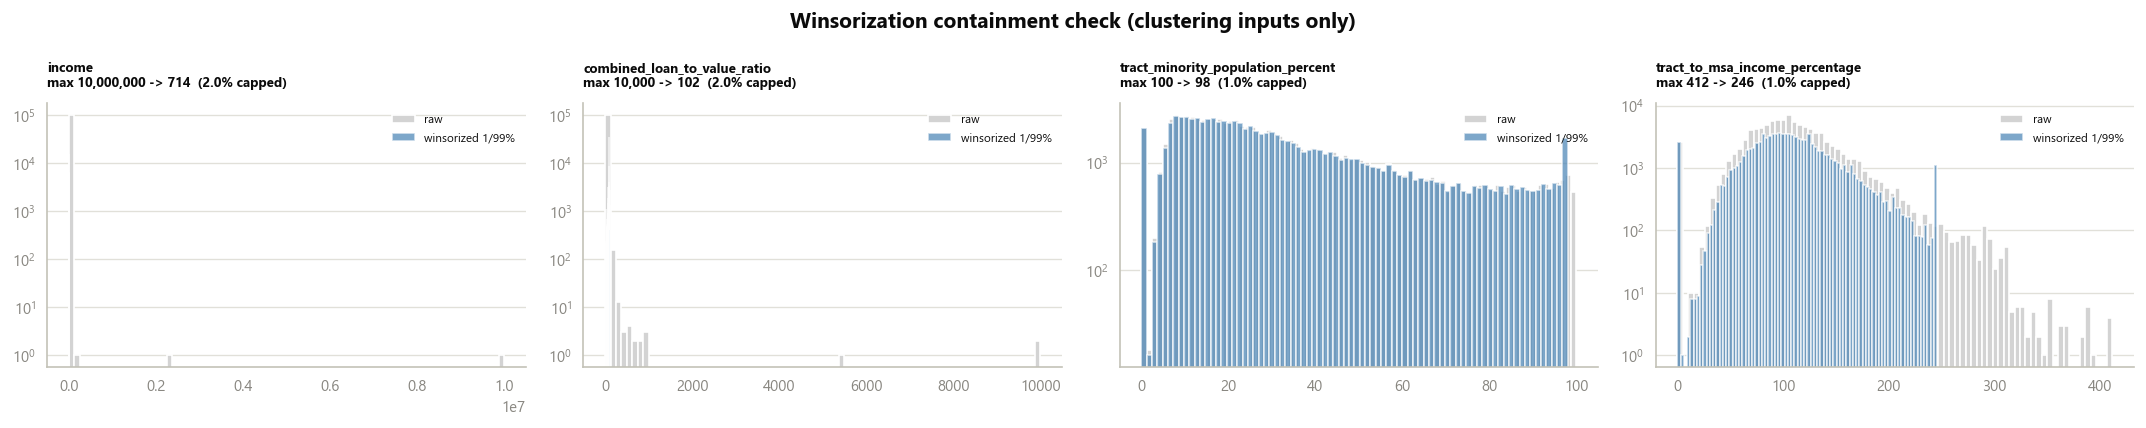

In [323]:
fig, axes = plt.subplots(1, len(CLUSTER_CONT_PART), figsize=(4.5 * len(CLUSTER_CONT_PART), 3.6))
for ax, col in zip(np.atleast_1d(axes), CLUSTER_CONT_PART):
    raw_s = clean[col].astype(float).dropna()
    cap_s = p2.winsorize(clean[col].astype(float)).dropna()
    ax.hist(raw_s, bins=80, color="lightgray", label="raw")
    ax.hist(cap_s, bins=80, color="steelblue", alpha=0.7, label="winsorized 1/99%")
    ax.set_yscale("log")
    pct = (raw_s != cap_s.reindex(raw_s.index)).mean() * 100
    ax.set_title(f"{col}\nmax {raw_s.max():,.0f} -> {cap_s.max():,.0f}  ({pct:.1f}% capped)",
                 fontsize=8, fontweight="bold")
    ax.legend(fontsize=7)
plt.suptitle("Winsorization containment check (clustering inputs only)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p2_winsorize_check.png", bbox_inches="tight")
plt.show()


---
# Fase 2 — Segmentasi melalui Clustering

Aplikasi pinjaman disegmentasikan berdasarkan profil finansial dan geografis menggunakan **empat** algoritma: tiga algoritma wajib, yaitu **K-Means**, **DBSCAN**, dan **hierarchical clustering**, ditambah **CLARANS** sebagai k-medoids dengan randomized search (Ng & Han, 1994). Nilai **K** dipilih dengan Elbow Method dan Silhouette Score. Linkage **Ward / complete / average** dibandingkan melalui dendrogram, sedangkan DBSCAN mengisolasi noise yang kemudian diteruskan ke Fase 4. Setiap cluster akhir diprofilkan dengan **approval rate** sebagai jembatan dari “segmen” menuju “penemuan”.

**Alasan menambahkan CLARANS:** pusat cluster pada CLARANS berupa **medoid**, yaitu catatan pinjaman nyata, bukan rata-rata sintetis. Setiap segmen karena itu memiliki applicant representatif yang konkret, dan medoid lebih tahan terhadap outlier ekstrem yang ditemukan pada Fase 1. Biaya CLARANS adalah `O(n·k)` per pertukaran, sehingga dapat dijalankan pada sampel 4 ribu yang sama dengan hierarchical clustering dan memungkinkan perbandingan K-Means, hierarchical, serta CLARANS pada baris identik.

### 2.1 - Memilih K: Elbow (inertia) + Silhouette

Kedua kriteria wajib diinterpretasikan bersama:

- **Elbow** menunjukkan titik setelah penambahan cluster hanya menghasilkan penurunan variasi dalam cluster yang semakin kecil.
- **Silhouette** mengukur seberapa kompak sebuah cluster dibandingkan dengan cluster alternatif terdekat.

Ketika keduanya berbeda, notebook melaporkan kedua nilai tersebut. Nilai optimum silhouette hanya dipilih bila cluster tambahan masih memberikan penurunan inertia yang berarti serta membentuk segmen yang dapat diinterpretasikan dan tidak terlalu kecil. Pilihan akhir kemudian divalidasi silang menggunakan hierarchical Ward dan CLARANS, bukan diterima hanya berdasarkan K-Means.

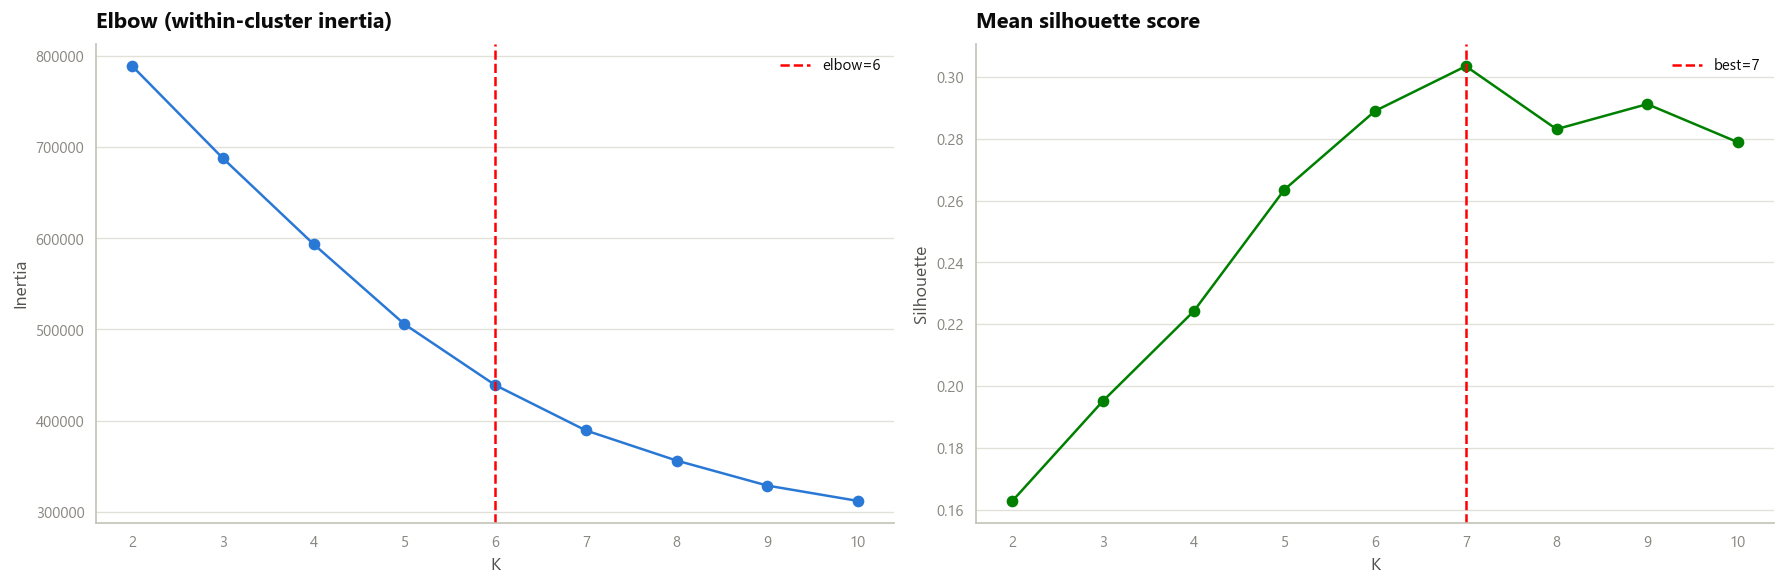

 K  inertia  silhouette  inertia_reduction_pct
 2 788963.0       0.163                    NaN
 3 687734.0       0.195                  12.83
 4 593509.0       0.224                  13.70
 5 505832.0       0.264                  14.77
 6 439002.0       0.289                  13.21
 7 389220.0       0.303                  11.34
 8 356165.0       0.283                   8.49
 9 328716.0       0.291                   7.71
10 311839.0       0.279                   5.13

Elbow suggests K=6; silhouette peaks at K=7. K=7 is retained and must also pass the hierarchical/CLARANS stability and business-interpretability checks below.


In [324]:
elbow_k, sil_k, BEST_K, k_selection = p2.select_k(Xc, range(2, 11), RANDOM_STATE)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(k_selection["K"], k_selection["inertia"], "o-")
ax[0].axvline(elbow_k, color="red", ls="--", label=f"elbow={elbow_k}")
ax[0].set_title("Elbow (within-cluster inertia)")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inertia")
ax[0].legend()

ax[1].plot(k_selection["K"], k_selection["silhouette"], "o-", color="green")
ax[1].axvline(sil_k, color="red", ls="--", label=f"best={sil_k}")
ax[1].set_title("Mean silhouette score")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Silhouette")
ax[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "p2_k_selection.png", bbox_inches="tight")
plt.show()

print(k_selection.round({"inertia": 0, "silhouette": 3}).to_string(index=False))
print(f"\nElbow suggests K={elbow_k}; silhouette peaks at K={sil_k}. "
      f"K={BEST_K} is retained and must also pass the hierarchical/CLARANS "
      "stability and business-interpretability checks below.")


### 2.2 - K-Means akhir dengan indeks validitas

In [325]:
clean["kmeans_cluster"] = p2.run_kmeans(Xc, BEST_K, RANDOM_STATE)
print("K-Means cluster sizes:")
print(clean["kmeans_cluster"].value_counts().sort_index().to_string())
print(f"\nValidity  |  silhouette={silhouette_score(Xc, clean['kmeans_cluster'], sample_size=min(10000, len(Xc)), random_state=RANDOM_STATE):.3f}"
      f"  davies_bouldin={davies_bouldin_score(Xc, clean['kmeans_cluster']):.3f}"
      f"  calinski_harabasz={calinski_harabasz_score(Xc, clean['kmeans_cluster']):.0f}")


K-Means cluster sizes:
kmeans_cluster
0    25565
1     7036
2    36833
3     4529
4     8732
5     4447
6    12853

Validity  |  silhouette=0.303  davies_bouldin=1.146  calinski_harabasz=21869


### 2.3 - DBSCAN

Nilai `eps` diperoleh dari knee pada k-distance plot, sedangkan `min_samples = 2 × jumlah dimensi`. ID baris noise dipertahankan untuk cross-reference pada Fase 4.

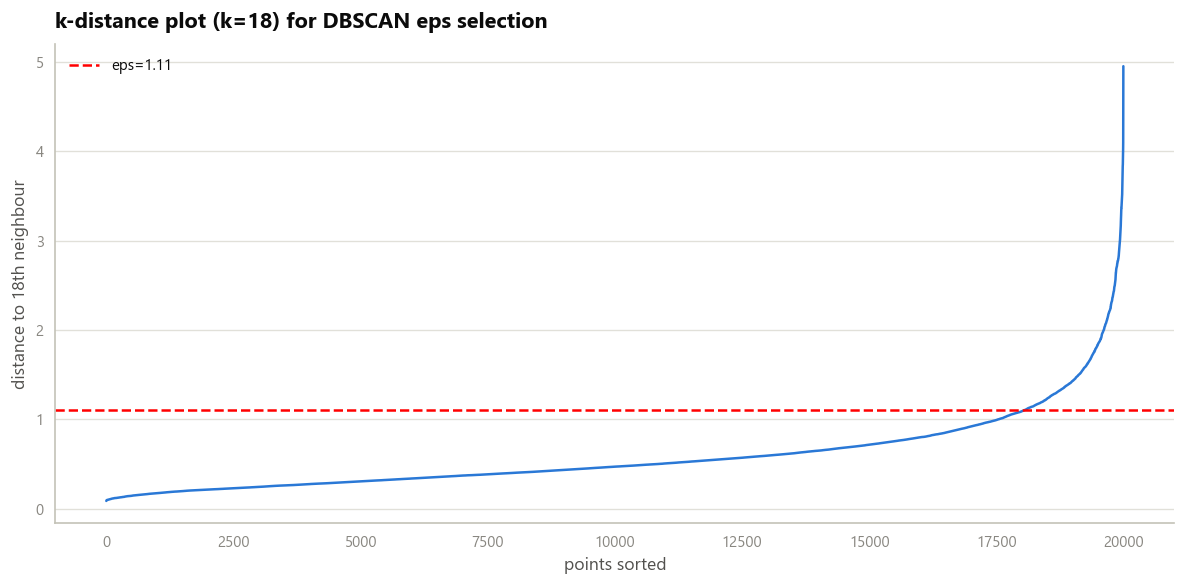

DBSCAN -> 17 clusters, 895 noise points (4.5% of sample). Noise rows feed Phase 4.


In [326]:
db_labels, dbscan_noise_ids, eps, min_samples, kdist = p2.run_dbscan(Xc, idx_med, CLUSTER_FEATS)

plt.figure(figsize=(10, 5))
plt.plot(kdist); plt.axhline(eps, color="red", ls="--", label=f"eps={eps:.2f}")
plt.title(f"k-distance plot (k={min_samples}) for DBSCAN eps selection")
plt.xlabel("points sorted"); plt.ylabel(f"distance to {min_samples}th neighbour"); plt.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "p2_dbscan_kdist.png", bbox_inches="tight"); plt.show()

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())
print(f"DBSCAN -> {n_clusters_db} clusters, {n_noise:,} noise points "
      f"({n_noise/len(db_labels)*100:.1f}% of sample). Noise rows feed Phase 4.")


### 2.4 - Hierarchical clustering

Linkage Ward, complete, dan average dibandingkan melalui dendrogram pada sampel 4 ribu baris. Pohon Ward dipotong pada `BEST_K`, kemudian hasilnya dibandingkan dengan K-Means menggunakan Adjusted Rand Index.

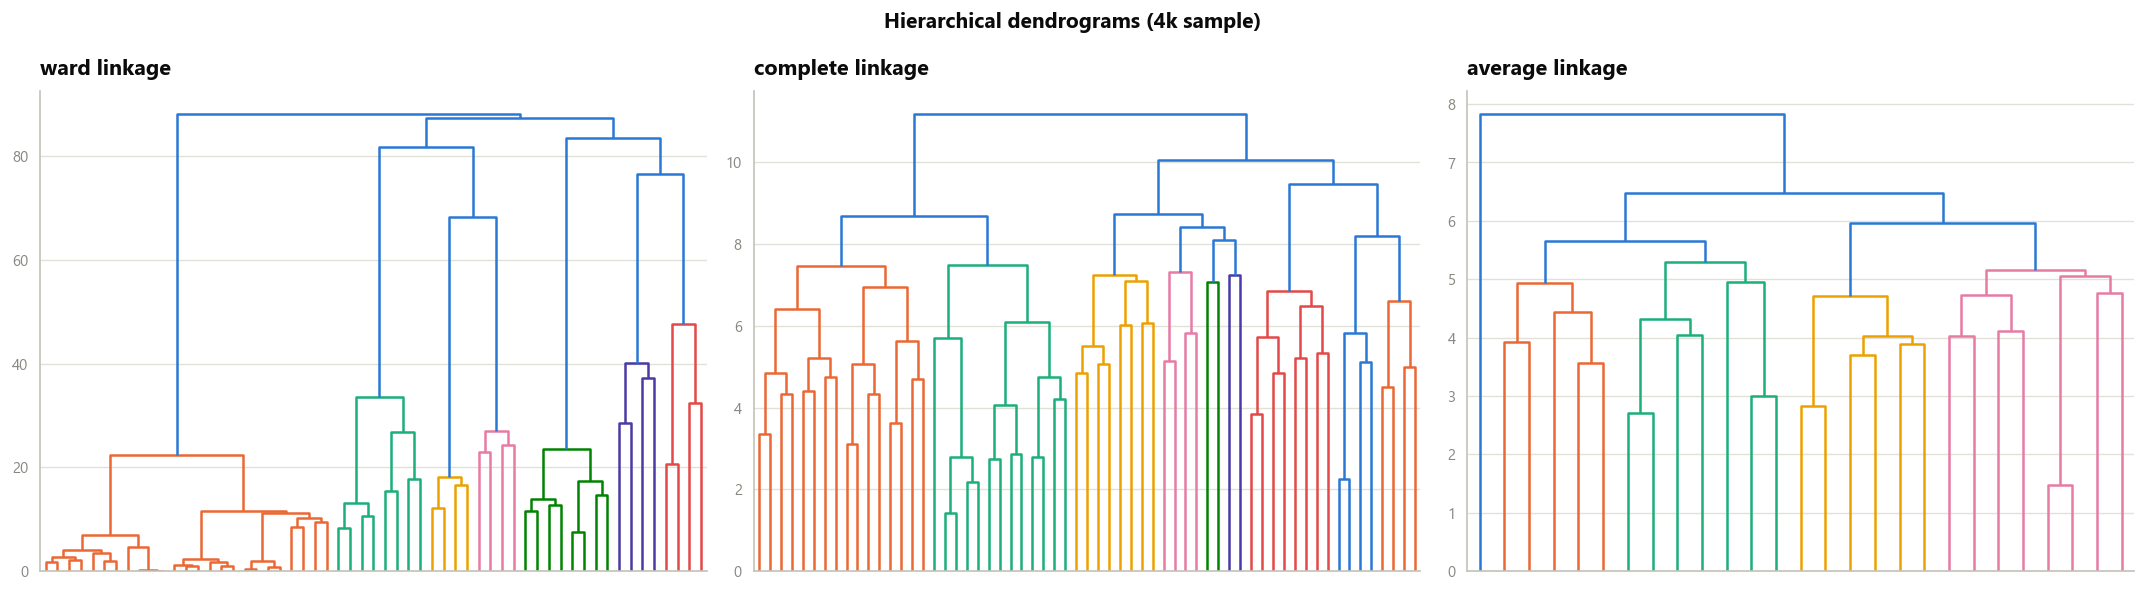

Ward linkage reused from run_hierarchical: True
Agreement K-Means vs Ward-hierarchical (same 4000 rows): ARI=0.907


In [327]:
# Linkage Ward dihitung sekali lalu dipakai bersama. Versi sebelumnya menghitungnya
# dua kali: sekali di dalam loop dendrogram, sekali lagi di p2.run_hierarchical.
# Panel ward hanya memakai ulang matriks tersebut bila bentuknya memang cocok dengan
# sampel ini, sehingga penggunaan ulang tetap terverifikasi, bukan diasumsikan.
Xs = Xc.iloc[idx_small].values
hier_labels, Zward = p2.run_hierarchical(Xc, idx_small, BEST_K)

reuse_ward = getattr(Zward, "shape", (0,))[0] == len(Xs) - 1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, method in zip(axes, ["ward", "complete", "average"]):
    Z = Zward if (method == "ward" and reuse_ward) else linkage(Xs, method=method)
    dendrogram(Z, truncate_mode="level", p=5, ax=ax, no_labels=True)
    ax.set_title(f"{method} linkage")
plt.suptitle("Hierarchical dendrograms (4k sample)", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG_DIR / "p2_dendrograms.png", bbox_inches="tight"); plt.show()
print(f"Ward linkage reused from run_hierarchical: {reuse_ward}")
km_small = clean["kmeans_cluster"].iloc[idx_small].values
print(f"Agreement K-Means vs Ward-hierarchical (same {len(idx_small)} rows): "
      f"ARI={adjusted_rand_score(km_small, hier_labels):.3f}")


### 2.5 - Visualisasi PCA untuk cluster K-Means

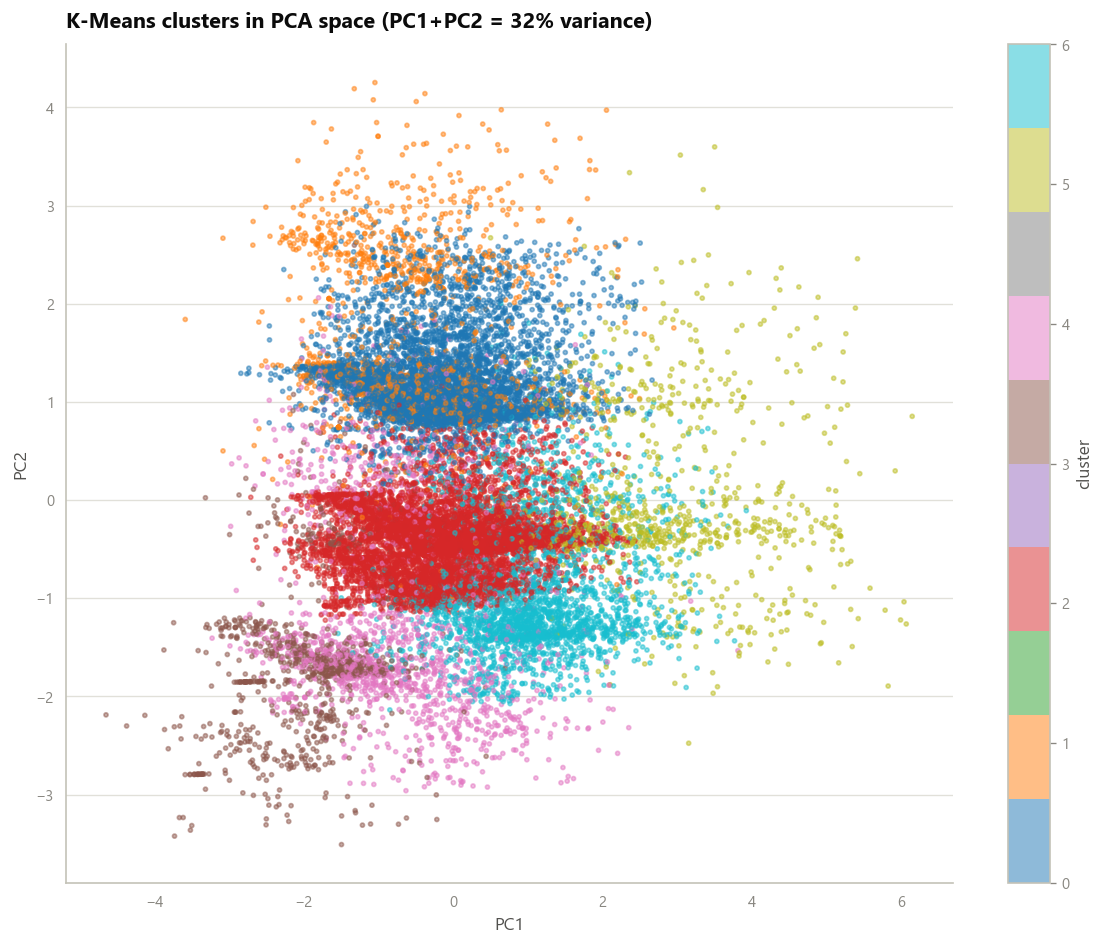

In [328]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Xc.iloc[idx_med])
plt.figure(figsize=(10, 8))
sc = plt.scatter(coords[:, 0], coords[:, 1],
                 c=clean["kmeans_cluster"].iloc[idx_med], cmap="tab10", s=6, alpha=0.5)
plt.colorbar(sc, label="cluster")
plt.title(f"K-Means clusters in PCA space "
          f"(PC1+PC2 = {pca.explained_variance_ratio_[:2].sum()*100:.0f}% variance)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.savefig(FIG_DIR / "p2_pca_clusters.png", bbox_inches="tight"); plt.show()

### 2.6 - Profil cluster dan penamaan bisnis

Setiap segmen diprofilkan berdasarkan outcome serta proporsi perilaku dan lokasi. Nama cluster kemudian **dibentuk otomatis dari atribut paling menonjol yang benar-benar terukur**. Aturan penamaan membaca profil sehingga nama tetap konsisten secara makna walaupun label numerik cluster berubah antar-run. Kategori dominan dicetak bersama proporsinya agar sifat pembeda dapat diukur, bukan hanya dinyatakan.

In [329]:
clean, profile = p2.profile_clusters(clean, "kmeans_cluster")

print("CLUSTER PROFILES  (medians; *_rate / pct_* in %):")
print(profile.round(1).to_string())

def _mode_share(s):
    vc = s.value_counts(normalize=True)
    return f"{vc.index[0]} ({vc.iloc[0]*100:.0f}%)" if len(vc) else None
print("\nDominant category (share) by cluster:")
for f in [c for c in ["derived_race", "loan_purpose", "occupancy_type", "tract_minority_cat",
                      "debt_to_income_ratio"] if c in clean.columns]:
    top = clean.groupby("kmeans_cluster")[f].agg(_mode_share)
    print(f"  {f:22s}: {top.to_dict()}")

clean[["kmeans_cluster"]].to_csv(DATA_PROCESSED / "p2_cluster_assignments.csv", index=True)
profile.to_csv(DATA_PROCESSED / "p2_cluster_profiles.csv")
print("\nSaved p2_cluster_assignments.csv, p2_cluster_profiles.csv")


CLUSTER PROFILES  (medians; *_rate / pct_* in %):
                    n  approval_rate  med_income  med_loan  med_cltv  pct_investment  pct_refinance  pct_high_dti  pct_manufactured  med_tract_minority  share_of_data                     segment_name
kmeans_cluster                                                                                                                                                                                         
0               25565           79.7        89.0  215000.0      78.4             0.0           94.5           0.0               0.0                30.3           25.6    Refinancers (rate & cash-out)
1                7036           83.0        95.0  215000.0      78.4           100.0           37.7           4.4               0.0                40.6            7.0               Property investors
2               36833           91.5        95.0  295000.0      78.4             0.0            0.0           0.0               0.0                29.

### 2.7 - Silhouette per cluster

Skor global dapat menyembunyikan segmen yang kompak atau menyebar. Silhouette per cluster menampilkannya secara langsung; segmen yang ditentukan oleh flag diperkirakan lebih kompak, sedangkan kelompok purchaser yang luas lebih menyebar.

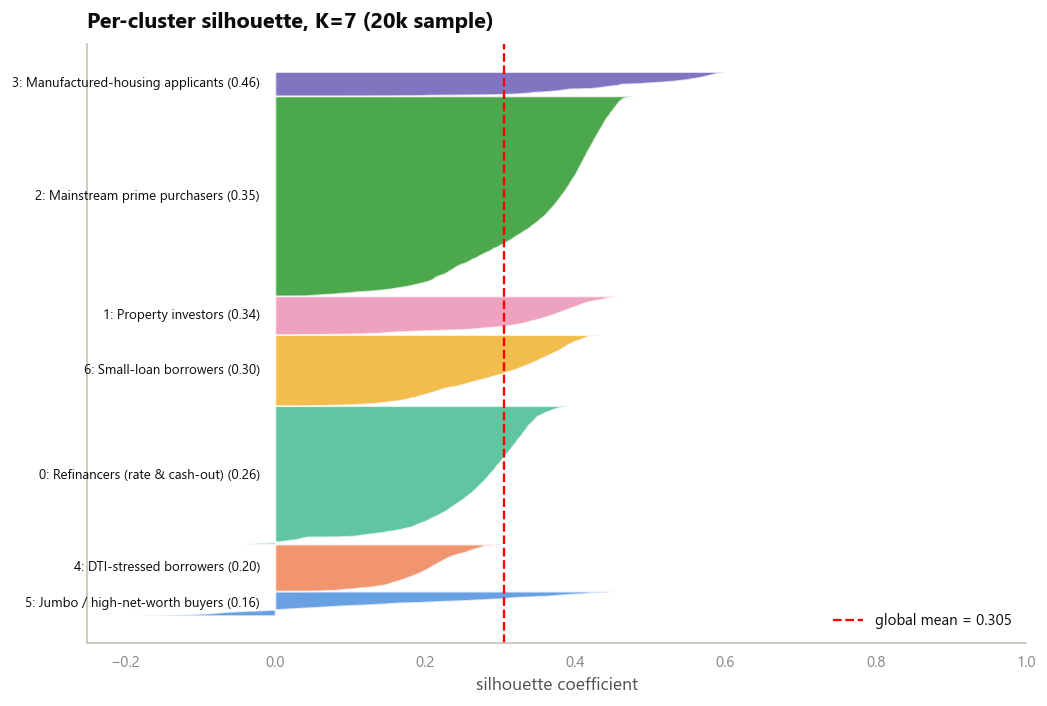

In [330]:
from sklearn.metrics import silhouette_samples

lab_med = clean["kmeans_cluster"].iloc[idx_med].values
sil_vals = silhouette_samples(Xc.iloc[idx_med].values, lab_med)

fig, ax = plt.subplots(figsize=(9, 6))
y_lo = 10
# Sampel 20k belum tentu memuat setiap cluster; np.mean atas slice kosong menghasilkan
# NaN sehingga urutannya menjadi acak tanpa peringatan. Cluster kosong dilewati secara
# eksplisit dan dilaporkan agar ketidakhadirannya terlihat, bukan tersembunyi.
present = [k for k in range(BEST_K) if (lab_med == k).any()]
if len(present) < BEST_K:
    print(f"Catatan: cluster {sorted(set(range(BEST_K)) - set(present))} tidak muncul "
          f"pada sampel {len(lab_med):,} baris; dilewati pada plot ini.")
order = [present[i] for i in np.argsort([sil_vals[lab_med == k].mean() for k in present])]
for k in order:
    vals = np.sort(sil_vals[lab_med == k])
    y_hi = y_lo + len(vals)
    name = profile["segment_name"].get(k, f"cluster {k}")
    ax.fill_betweenx(np.arange(y_lo, y_hi), 0, vals, alpha=0.7)
    ax.text(-0.02, (y_lo + y_hi) / 2, f"{k}: {name} ({vals.mean():.2f})",
            ha="right", va="center", fontsize=8)
    y_lo = y_hi + 10
ax.axvline(sil_vals.mean(), color="red", ls="--", lw=1.4,
           label=f"global mean = {sil_vals.mean():.3f}")
ax.set_xlabel("silhouette coefficient"); ax.set_yticks([])
ax.set_title(f"Per-cluster silhouette, K={BEST_K} (20k sample)", fontweight="bold")
ax.legend(loc="lower right"); ax.set_xlim(-0.25, 1.0)
plt.tight_layout(); plt.savefig(FIG_DIR / "p2_silhouette_per_cluster.png", bbox_inches="tight"); plt.show()

### 2.8 - CLARANS: k-medoids dengan randomized search

Implementasi divektorisasi dan matriks jarak dihitung satu kali agar setiap evaluasi biaya lebih murah. Nilai `maxneighbor` mengikuti heuristik Ng & Han dengan batas maksimum.

In [331]:
t0 = time.time()
clarans_labels, medoid_ids, clarans_cost = p2.run_clarans(Xc, idx_small, BEST_K, RANDOM_STATE)
print(f"CLARANS: k={BEST_K} on {len(idx_small):,} rows in {time.time()-t0:.1f}s | total cost={clarans_cost:.0f}")
print(f"  silhouette = {silhouette_score(Xc.iloc[idx_small].values, clarans_labels):.3f}")

km_small = clean["kmeans_cluster"].iloc[idx_small].values
print(f"  ARI vs K-Means      = {adjusted_rand_score(km_small, clarans_labels):.3f}")
print(f"  ARI vs Hierarchical = {adjusted_rand_score(hier_labels, clarans_labels):.3f}")


CLARANS: k=7 on 4,000 rows in 0.7s | total cost=7376
  silhouette = 0.245
  ARI vs K-Means      = 0.711
  ARI vs Hierarchical = 0.701


### 2.9 - Medoid CLARANS: catatan pinjaman nyata yang mewakili pusat setiap cluster

CLARANS medoids:
       income  loan_amount  property_value  combined_loan_to_value_ratio  loan_term      loan_purpose       occupancy_type        derived_race action_taken
55283    96.0       505000        635000.0                        80.000      360.0     Home_Purchase  Principal_Residence  Race Not Available       Denied
88052    95.0       385000        405000.0                        78.353      360.0     Home_Purchase  Principal_Residence  Race Not Available    Purchased
23264    95.0       365000        365000.0                        78.353      360.0     Home_Purchase  Principal_Residence  Race Not Available    Purchased
75458    95.0       235000        295000.0                        78.353      360.0     NotApplicable           Investment  Race Not Available    Purchased
65291   186.0        65000        335000.0                        72.206      480.0  Home_Improvement  Principal_Residence  Race Not Available   Originated
64827    95.0        45000         45000.0     

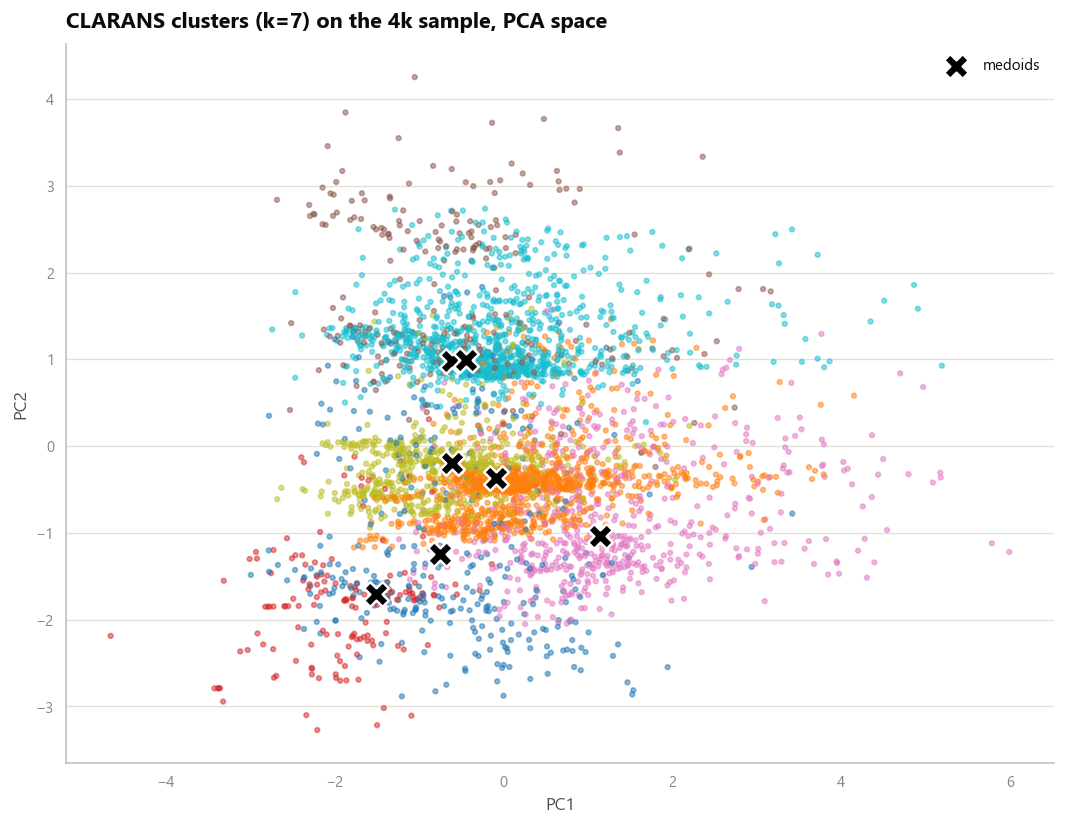


Saved p2_clarans_assignments.csv


In [332]:
global_medoids = np.array(idx_small)[medoid_ids]
show = [c for c in ["income", "loan_amount", "property_value", "combined_loan_to_value_ratio",
                    "loan_term", "loan_purpose", "occupancy_type", "derived_race", "action_taken"]
        if c in clean.columns]
print("CLARANS medoids:")
print(clean.iloc[global_medoids][show].to_string())

coords_s = pca.transform(Xc.iloc[idx_small])
plt.figure(figsize=(9, 7))
plt.scatter(coords_s[:, 0], coords_s[:, 1], c=clarans_labels, cmap="tab10", s=8, alpha=0.5)
plt.scatter(coords_s[medoid_ids, 0], coords_s[medoid_ids, 1],
            c="black", marker="X", s=220, edgecolors="white", linewidths=1.5, label="medoids")
plt.legend(); plt.title(f"CLARANS clusters (k={BEST_K}) on the 4k sample, PCA space")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.savefig(FIG_DIR / "p2_clarans_pca.png", bbox_inches="tight"); plt.show()

pd.DataFrame({"row": np.array(idx_small), "clarans_cluster": clarans_labels}) \
    .to_csv(DATA_PROCESSED / "p2_clarans_assignments.csv", index=False)
print("\nSaved p2_clarans_assignments.csv")

### 2.10 — Audit stabilitas cluster: apakah ada *spurious / fake cluster*?

Cluster kecil **tidak otomatis** merupakan collective anomaly, dan cluster yang berbeda secara bisnis juga tidak otomatis "palsu". Sebelum membawa hasil clustering ke Fase 4, setiap cluster K-Means diperiksa dari tiga sisi:

1. **Ukuran** — cluster yang sangat kecil (`<1%`) lebih rentan menjadi artefak segmentasi.
2. **Kohesi internal** — mean silhouette per cluster; nilai sangat rendah menunjukkan anggota tidak benar-benar cocok dengan clusternya.
3. **Replikasi lintas algoritma** — *purity* terhadap Ward hierarchical dan CLARANS pada **4.000 baris yang sama**. Jika dua metode lain sama-sama memecah sebuah cluster secara ekstrem, cluster tersebut layak ditinjau sebagai *spurious-cluster candidate*.

Audit ini **tidak memaksa harus ada fake cluster**. Bila semua cluster berukuran material, cukup kohesif, dan direplikasi oleh metode lain, kesimpulan yang benar adalah *tidak ada bukti kuat bahwa segmentasi K-Means mengandung cluster palsu*. Cluster yang sah tetap dapat menjadi **collective anomaly candidate** kemudian jika profil kelompoknya tidak biasa tetapi anggotanya mayoritas normal secara individual.


In [333]:
from sklearn.metrics import silhouette_samples

# Use the same 4k rows for K-Means, Ward, and CLARANS so stability is comparable.
X_stab = Xc.iloc[idx_small].values
km_stab = clean["kmeans_cluster"].iloc[idx_small].to_numpy()

sil_stab = silhouette_samples(X_stab, km_stab)

def _cluster_purity(reference_labels, alternative_labels, cluster_id):
    mask = reference_labels == cluster_id
    if not mask.any():
        return np.nan
    vals, counts = np.unique(alternative_labels[mask], return_counts=True)
    return counts.max() / counts.sum() if len(counts) else np.nan

rows = []
for k in sorted(np.unique(clean["kmeans_cluster"])):
    full_n = int((clean["kmeans_cluster"] == k).sum())
    full_share = full_n / len(clean) * 100

    smask = km_stab == k
    mean_sil = float(sil_stab[smask].mean()) if smask.any() else np.nan
    ward_purity = _cluster_purity(km_stab, hier_labels, k)
    clarans_purity = _cluster_purity(km_stab, clarans_labels, k)

    # Conservative "spurious" screen:
    # - extremely tiny cluster, OR
    # - almost no internal separation, OR
    # - both independent methods fail to reproduce even half of its membership together.
    weak_size = full_share < 1.0
    weak_cohesion = (mean_sil < 0.05) if np.isfinite(mean_sil) else True
    weak_replication = (
        np.isfinite(ward_purity) and np.isfinite(clarans_purity)
        and ward_purity < 0.50 and clarans_purity < 0.50
    )
    spurious_candidate = bool(weak_size or weak_cohesion or weak_replication)

    segment_name = (
        str(profile.loc[k, "segment_name"])
        if "profile" in globals() and k in profile.index and "segment_name" in profile.columns
        else f"Cluster {k}"
    )

    rows.append({
        "kmeans_cluster": int(k),
        "segment_name": segment_name,
        "n": full_n,
        "share_pct": full_share,
        "mean_silhouette_4k": mean_sil,
        "ward_purity_4k": ward_purity,
        "clarans_purity_4k": clarans_purity,
        "weak_size_lt1pct": weak_size,
        "weak_cohesion_sil_lt005": weak_cohesion,
        "weak_replication_both_lt050": weak_replication,
        "spurious_cluster_candidate": spurious_candidate,
    })

cluster_stability_audit = pd.DataFrame(rows).sort_values("kmeans_cluster")

print("K-Means cluster stability audit:")
print(
    cluster_stability_audit[
        [
            "kmeans_cluster", "segment_name", "n", "share_pct",
            "mean_silhouette_4k", "ward_purity_4k", "clarans_purity_4k",
            "spurious_cluster_candidate",
        ]
    ].to_string(
        index=False,
        formatters={
            "share_pct": lambda x: f"{x:.2f}%",
            "mean_silhouette_4k": lambda x: f"{x:.3f}",
            "ward_purity_4k": lambda x: f"{x:.3f}",
            "clarans_purity_4k": lambda x: f"{x:.3f}",
        },
    )
)

n_spurious = int(cluster_stability_audit["spurious_cluster_candidate"].sum())
if n_spurious == 0:
    print(
        "\nConclusion: no K-Means cluster meets the conservative spurious-cluster screen. "
        "This does NOT mean collective anomalies cannot exist; it means the 7 business "
        "segments themselves are not obviously clustering artifacts."
    )
else:
    print(
        f"\nReview needed: {n_spurious} K-Means cluster(s) meet at least one conservative "
        "spurious-cluster criterion. Treat them as candidates, not automatic errors."
    )

cluster_stability_audit.to_csv(
    DATA_PROCESSED / "p2_cluster_stability_audit.csv", index=False
)


K-Means cluster stability audit:
 kmeans_cluster                    segment_name     n share_pct mean_silhouette_4k ward_purity_4k clarans_purity_4k  spurious_cluster_candidate
              0   Refinancers (rate & cash-out) 25565    25.57%              0.272          0.990             0.950                       False
              1              Property investors  7036     7.04%              0.334          1.000             1.000                       False
              2     Mainstream prime purchasers 36833    36.83%              0.343          0.961             0.644                       False
              3 Manufactured-housing applicants  4529     4.53%              0.495          1.000             1.000                       False
              4          DTI-stressed borrowers  8732     8.73%              0.209          0.997             1.000                       False
              5   Jumbo / high-net-worth buyers  4447     4.45%              0.167          0.584      

---
# Fase 3 — Association Rule Mining

Sudut analisis yang ditetapkan adalah **kombinasi applicant mana yang secara sistematis disetujui atau ditolak**. Setiap baris yang memiliki keputusan diubah menjadi transaksi berisi item `feature=value`, hanya menggunakan fitur yang tersedia saat aplikasi dan bebas leakage, kemudian ditambah item outcome `decision=Originated|Denied`. Frequent itemset ditambang dengan **Apriori** sesuai rubric. Pada matriks ini, Apriori ter-vectorisasi dari `mlxtend` berjalan sekitar dua detik, sedangkan FP-Growth Python murni dari library yang sama memerlukan sekitar 30 menit untuk hasil identik. Karena itu, FP-Growth disediakan sebagai opsi yang secara default dimatikan.

**Dirancang agar tidak memenuhi RAM Colab:** item hampir konstan dibuang, panjang antecedent dibatasi melalui `max_len=3`, Apriori mengalirkan kandidat menggunakan `low_memory=True`, dan decision rule diekstrak **langsung dari frequent itemset** tanpa memanggil `association_rules`, yang akan membentuk seluruh kemungkinan pemisahan antecedent dan consequent.

### 3.1 - Matriks transaksi

Item dengan support di luar `[MIN_SUPPORT, 0.95]` dibuang. Item di bawah batas minimum tidak mungkin menjadi frequent, sedangkan item di atas 0,95 tidak informatif dan hanya memperbesar ruang itemset. Matriks tetap menggunakan dense boolean karena ukurannya hanya beberapa MB dan `mlxtend` sangat lambat pada input sparse untuk kasus ini.

In [334]:
MIN_SUPPORT = 0.02
MAX_LEN = 3

onehot, decision_items, n_items_before = p3.build_transactions(appdeny, ITEM_FEATURES, MIN_SUPPORT)

mem_mb = onehot.memory_usage(deep=True).sum() / 1e6
print(f"Transaction matrix: {onehot.shape[0]:,} transactions x {onehot.shape[1]} items "
      f"(trimmed from {n_items_before}; dense {mem_mb:.1f} MB)")
if "decision=Denied" in onehot.columns:
    print(f"Denial base rate in transactions: {onehot['decision=Denied'].mean()*100:.1f}%")


Transaction matrix: 67,827 transactions x 82 items (trimmed from 102; dense 6.1 MB)
Denial base rate in transactions: 23.1%


### 3.2 - Frequent itemset: Apriori sebagai metode utama, FP-Growth sebagai opsi

In [335]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

t0 = time.time()
frequent = p3.mine_frequent_itemsets(onehot, MIN_SUPPORT, MAX_LEN)
print(f"Apriori: {len(frequent):,} frequent itemsets in {time.time()-t0:.2f}s")

RUN_FPGROWTH = False
if RUN_FPGROWTH:
    t0 = time.time()
    fi_fp = fpgrowth(onehot, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LEN)
    print(f"FP-Growth: {len(fi_fp):,} itemsets in {time.time()-t0:.1f}s (identical itemsets)")


Apriori: 10,013 frequent itemsets in 2.39s


### 3.3 - Decision rule melalui ekstraksi terarah

Hanya rule dengan keputusan sebagai consequent yang dibutuhkan. Rule karena itu diturunkan langsung dari frequent itemset: untuk setiap itemset `S = A + {decision}`, nilai `supp(S)` dan `supp(A)` telah tersedia dalam tabel. Filter yang digunakan adalah `lift > 1.2` dan `confidence ≥ 0.55`.

In [336]:
all_rules, decision_rules, dec_supp = p3.extract_decision_rules(frequent, onehot, decision_items)

cols = ["antecedent", "consequent", "support", "confidence", "lift", "leverage", "conviction"]
print(f"Non-trivial decision rules (lift>1.2, conf>=0.55): {len(decision_rules)} "
      f"(from {len(all_rules)} candidate decision rules)")
print("\nTOP 15 rules by lift:")
print(decision_rules[cols].head(15).round(3).to_string(index=False))

denied_rules = decision_rules[decision_rules["consequent"] == "decision=Denied"].copy()
print(f"\n-> {len(denied_rules)} rules conclude DENIED, "
      f"{len(decision_rules)-len(denied_rules)} conclude ORIGINATED.")
decision_rules.to_csv(DATA_PROCESSED / "p3_decision_rules.csv", index=False)


Non-trivial decision rules (lift>1.2, conf>=0.55): 28 (from 1605 candidate decision rules)

TOP 15 rules by lift:
                                                         antecedent      consequent  support  confidence  lift  leverage  conviction
            debt_to_income_ratio=>60%, lien_status=Subordinate_Lien decision=Denied    0.022       0.940 4.063     0.016      12.717
                  debt_to_income_ratio=>60%, loan_type=Conventional decision=Denied    0.049       0.933 4.034     0.037      11.457
                        cltv_band=60-80%, debt_to_income_ratio=>60% decision=Denied    0.025       0.923 3.991     0.018       9.961
      debt_to_income_ratio=>60%, occupancy_type=Principal_Residence decision=Denied    0.052       0.920 3.978     0.039       9.592
                 conforming_loan_limit=C, debt_to_income_ratio=>60% decision=Denied    0.053       0.919 3.973     0.040       9.461
                                          debt_to_income_ratio=>60% decision=Denied    0

**Validasi — posisi rule yang dipertahankan dalam ruang rule.** Seluruh kandidat decision rule ditampilkan dalam warna abu-abu dan rule terpilih diberi warna menurut lift. Rule terpilih harus berada pada wilayah confidence tinggi tanpa hanya menempel pada support yang sangat kecil. Bila seluruh rule terpilih berada tepat di batas support, threshold kemungkinan hanya memilih kebetulan statistik.

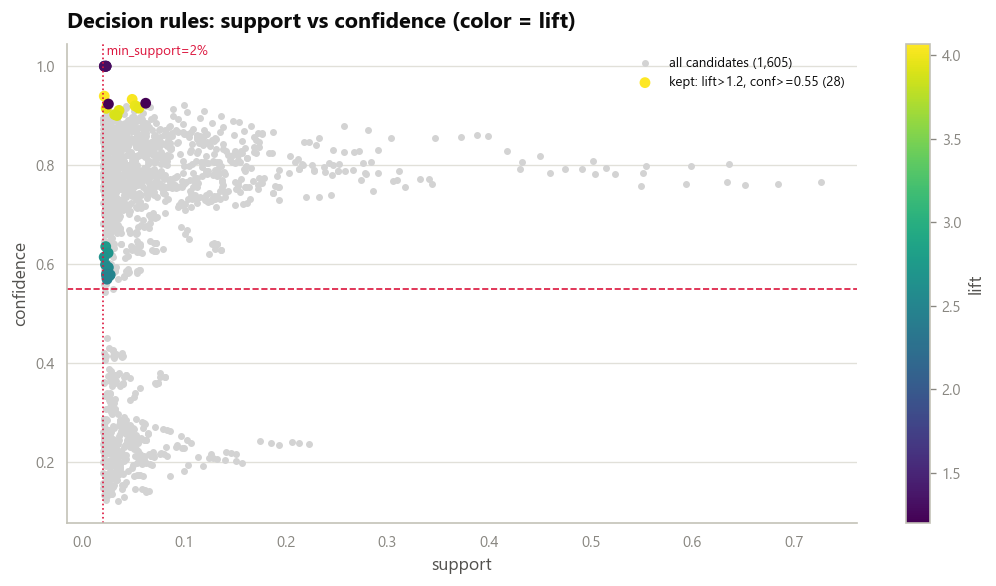

In [337]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(all_rules["support"], all_rules["confidence"], s=10, color="lightgray",
           label=f"all candidates ({len(all_rules):,})")
sc = ax.scatter(decision_rules["support"], decision_rules["confidence"], s=30,
                c=decision_rules["lift"], cmap="viridis",
                label=f"kept: lift>1.2, conf>=0.55 ({len(decision_rules):,})")
ax.axhline(0.55, color="crimson", ls="--", lw=1)
# Markdown di atas mengklaim rule terpilih tidak hanya menempel pada batas support.
# Batas itu digambar agar klaim tersebut dapat diperiksa langsung dari figure.
ax.axvline(MIN_SUPPORT, color="crimson", ls=":", lw=1)
ax.text(MIN_SUPPORT, ax.get_ylim()[1], f" min_support={MIN_SUPPORT:.0%}",
        va="top", ha="left", fontsize=8, color="crimson")
ax.set_xlabel("support"); ax.set_ylabel("confidence")
ax.set_title("Decision rules: support vs confidence (color = lift)", fontweight="bold")
plt.colorbar(sc, label="lift")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "p3_rule_space.png", bbox_inches="tight")
plt.show()


### 3.4 - Signifikansi rule: chi-square + Wilson CI 95%

Lift yang tinggi dapat muncul karena jumlah sampel kecil. Karena itu, denial rate kelompok yang cocok dengan setiap rule utama diuji terhadap base rate.

In [338]:
sig_df = p3.test_significance(decision_rules, onehot, top_n=10)
print("TOP RULES -- significance check (rate vs base, Wilson 95% CI, chi-square):")
print(sig_df.to_string(index=False))
sig_df.to_csv(TABLE_DIR / "p3_rule_significance.csv", index=False)


TOP RULES -- significance check (rate vs base, Wilson 95% CI, chi-square):
                                                         antecedent      consequent  n_matched  rate           ci95  lift    chi2 p_value
            debt_to_income_ratio=>60%, lien_status=Subordinate_Lien decision=Denied       1555 0.940 [92.7%, 95.0%]  4.06  4487.6 0.0e+00
                  debt_to_income_ratio=>60%, loan_type=Conventional decision=Denied       3562 0.933 [92.4%, 94.1%]  4.03 10407.9 0.0e+00
                        cltv_band=60-80%, debt_to_income_ratio=>60% decision=Denied       1801 0.923 [91.0%, 93.4%]  3.99  4973.9 0.0e+00
      debt_to_income_ratio=>60%, occupancy_type=Principal_Residence decision=Denied       3818 0.920 [91.1%, 92.8%]  3.98 10788.0 0.0e+00
                 conforming_loan_limit=C, debt_to_income_ratio=>60% decision=Denied       3926 0.919 [91.0%, 92.7%]  3.97 11076.3 0.0e+00
                                          debt_to_income_ratio=>60% decision=Denied       4121 0.

### 3.5 - Pengurangan redundansi dengan improvement filter

Tabel lift sebelumnya memiliki masalah redundansi: seluruh top-10 berisi `debt_to_income_ratio=>60%` ditambah satu item pendamping, dengan confidence 0,90–0,94 dibandingkan 0,915 untuk DTI>60% saja. Item kedua tersebut umumnya hanya *frequent bystander*, seperti Conventional, Principal_Residence, First_Lien, atau White, yang ikut muncul bersama parent rule dominan tanpa mengubah outcome. Pola serupa terjadi di bawah `preapproval=Requested` untuk outcome Originated.

Solusinya adalah **improvement criterion** (Bayardo et al., 1999): sebuah rule hanya dipertahankan bila confidence-nya mengungguli **setiap** proper sub-rule dengan consequent yang sama, termasuk empty rule yang setara dengan base rate 23,1%/76,9%, setidaknya dua percentage point. Rule yang tidak dapat mengungguli sub-rule-nya dengan margin tersebut tidak menambah informasi dan hanya menambah noise. Hanya satu interaksi top-10 yang lolos, yaitu `Subordinate_Lien` di atas DTI>60% dengan peningkatan 2,4 poin. Sebanyak 17 variasi lainnya runtuh ke parent rule, menyisakan 11 rule dengan antecedent yang benar-benar berbeda dan diuji ulang signifikansinya.

In [339]:
# Improvement filter bergaya Bayardo: sebuah rule hanya dipertahankan bila confidence-nya mengungguli
# setiap proper sub-rule dengan consequent yang sama, termasuk empty rule yang setara dengan base rate,
# setidaknya sebesar MIN_IMPROVEMENT. Selain itu hanya merupakan variasi trivial dari parent yang lebih kuat.
MIN_IMPROVEMENT = 0.02

final_rules, pruned_away, final_sig = p3.prune_redundant(
    decision_rules, all_rules, dec_supp, onehot, MIN_IMPROVEMENT)

print(f"Improvement filter (confidence gain >= {MIN_IMPROVEMENT:.0%} over the best sub-rule):")
print(f"  {len(decision_rules)} rules -> {len(final_rules)} kept, "
      f"{len(pruned_away)} pruned as trivial variants\n")
print("PRUNED - the extra item adds nothing over its sub-rule:")
print(pruned_away[["antecedent", "consequent", "confidence", "improvement", "best_subrule"]]
      .round(3).to_string(index=False))

print("\nFINAL RULE SET - diverse antecedents, all significant (base: 23.1% Denied / 76.9% Originated):")
print(final_sig.to_string(index=False))
final_sig.to_csv(DATA_PROCESSED / "p3_decision_rules_final.csv", index=False)


Improvement filter (confidence gain >= 2% over the best sub-rule):
  28 rules -> 11 kept, 17 pruned as trivial variants

PRUNED - the extra item adds nothing over its sub-rule:
                                                          antecedent          consequent  confidence  improvement                     best_subrule
                   debt_to_income_ratio=>60%, loan_type=Conventional     decision=Denied       0.933        0.018        debt_to_income_ratio=>60%
                         cltv_band=60-80%, debt_to_income_ratio=>60%     decision=Denied       0.923        0.008        debt_to_income_ratio=>60%
       debt_to_income_ratio=>60%, occupancy_type=Principal_Residence     decision=Denied       0.920        0.005        debt_to_income_ratio=>60%
                  conforming_loan_limit=C, debt_to_income_ratio=>60%     decision=Denied       0.919        0.004        debt_to_income_ratio=>60%
           debt_to_income_ratio=>60%, tract_income_cat=Middle_Income     decision=Denied

### 3.6 - Validasi rule set pada tingkat Excellent

Rubric mensyaratkan sedikitnya sepuluh rule nontrivial yang memiliki Support, Confidence, dan Lift. Cell berikut menegakkan persyaratan tersebut secara programatik setelah redundancy pruning. Notebook akan berhenti daripada diam-diam menampilkan jumlah rule yang tidak mencukupi.

In [340]:
MIN_INTERPRETED_RULES = 10
REQUIRED_RULE_METRICS = {"support", "confidence", "lift"}

missing_rule_metrics, interpreted_rules = p3.validate_rule_count(final_rules, MIN_INTERPRETED_RULES, REQUIRED_RULE_METRICS)

assert not missing_rule_metrics, f"Missing rule metrics: {sorted(missing_rule_metrics)}"
assert len(final_rules) >= MIN_INTERPRETED_RULES, (
    f"Only {len(final_rules)} non-trivial pruned rules remain; "
    f"at least {MIN_INTERPRETED_RULES} are required. Review thresholds transparently "
    "instead of padding the report with redundant variants."
)

interpreted_rules.to_csv(TABLE_DIR / "p3_interpreted_rules.csv", index=False)

print(f"Rule-count requirement passed: {len(final_rules)} non-trivial pruned rules; "
      f"{len(interpreted_rules)} selected for interpretation.")
print(interpreted_rules[["rule_id", "antecedent", "consequent", "support", "confidence", "lift"]]
      .round(3).to_string(index=False))
print("Saved p3_interpreted_rules.csv")


Rule-count requirement passed: 11 non-trivial pruned rules; 11 selected for interpretation.
rule_id                                                   antecedent          consequent  support  confidence  lift
     R1      debt_to_income_ratio=>60%, lien_status=Subordinate_Lien     decision=Denied    0.022       0.940 4.063
     R2                                    debt_to_income_ratio=>60%     decision=Denied    0.056       0.915 3.957
     R3     construction_method=Manufactured, loan_type=Conventional     decision=Denied    0.023       0.635 2.747
     R4         debt_to_income_ratio=50%-60%, loan_type=Conventional     decision=Denied    0.025       0.622 2.691
     R5 construction_method=Manufactured, loan_purpose=Home_Purchase     decision=Denied    0.021       0.614 2.655
     R6                     income_band=<30k, loan_type=Conventional     decision=Denied    0.023       0.599 2.589
     R7                                             income_band=<30k     decision=Denied    0.02

### 3.7 - Interpretasi bisnis dari rule akhir

Base rate pada subset yang memiliki keputusan adalah **23,1% Denied / 76,9% Originated**. Seluruh rule di bawah signifikan menurut chi-square dengan `p < 10⁻⁵⁷`; *n* adalah jumlah aplikasi yang cocok dan CI menggunakan Wilson 95%.

**Rule denial**

**R1 — DTI > 60% ∧ subordinate lien → Denied** · conf 94,0% · lift 4,06 · n = 1.555 · CI [92,7%, 95,0%]  
Kombinasi dengan penolakan paling konsisten dalam data: permintaan second lien dari borrower yang telah menghabiskan lebih dari 60% income untuk utang gagal pada 94 dari 100 aplikasi, sekitar empat kali base rate. Junior lien merupakan satu-satunya tambahan yang benar-benar memperburuk rule DTI>60% sebesar 2,4 poin. Subordinate lien mengindikasikan adanya hipotek senior sehingga leverage aktual lebih tinggi daripada yang terlihat dari masing-masing fitur secara terpisah. *Tindakan: dengan peluang approval sekitar 6%, identifikasi aplikasi ini sebelum full underwriting dan arahkan ke alternatif debt consolidation agar biaya lender lebih rendah dan dampak pada credit file applicant lebih ringan.*

**R2 — DTI > 60% → Denied** · conf 91,5% · lift 3,96 · n = 4.121 · CI [90,6%, 92,3%] · χ² = 11.538, terbesar dalam rule set  
Ini adalah rule utama: 6,1% aplikasi yang memiliki keputusan berada di atas DTI 60% dan 91,5% di antaranya ditolak. Kemampuan membayar mendominasi faktor lainnya. Hasil pruning juga penting: seluruh variasi ber-lift tinggi yang menambahkan Conventional, First_Lien, White, Not-Hispanic, dan item lain tidak memberi peningkatan. **Setelah DTI>60% diketahui, tidak ada atribut lain dalam item set, termasuk demografi, yang mengubah prediksi secara berarti.** *Tindakan untuk borrower: menurunkan DTI ke bawah 60% melalui co-borrower, tenor lebih panjang, atau loan lebih kecil merupakan perubahan dengan dampak terbesar. Tindakan untuk lender: pemeriksaan DTI pada awal aplikasi dapat menyelesaikan sekitar 9 dari 10 berkas ini tanpa menggunakan kapasitas underwriting penuh.*

**R3 — Manufactured home ∧ conventional loan → Denied** · conf 63,5% · lift 2,75 · n = 2.453 · CI [61,6%, 65,4%]  
Saluran pembiayaan memperkuat penalti jenis hunian pada R8. Underwriting conventional menganggap unit buatan pabrik sebagai collateral yang lebih cepat terdepresiasi dan memiliki pasar sekunder tipis, sehingga hampir dua dari tiga aplikasi ditolak, 6,6 poin lebih buruk daripada manufactured housing secara keseluruhan. *Tindakan: arahkan pembeli manufactured home ke program FHA/VA atau chattel khusus daripada jalur conventional.*

**R4 — DTI 50–60% ∧ conventional loan → Denied** · conf 62,2% · lift 2,69 · n = 2.759 · CI [60,4%, 64,0%] · improvement +20,5 poin  
Ini merupakan interaksi nyata terbesar yang ditemukan. DTI 50–60% saja memiliki denial rate 41,7%, tetapi di dalam jalur conventional nilainya meningkat menjadi 62,2%. Mekanismenya lebih bersifat regulasi daripada perilaku: underwriting GSE secara efektif membatasi DTI di sekitar 50%, sedangkan FHA/VA dapat menerima hingga sekitar 57% dengan compensating factors. *Tindakan: borrower pada band DTI 50–60% sebaiknya mempertimbangkan FHA/VA, bukan conventional; pada applicant yang sama, perbedaannya mendekati 20 poin pada peluang denial.*

**R5 — Manufactured home ∧ home purchase → Denied** · conf 61,4% · lift 2,65 · n = 2.370 · CI [59,4%, 63,3%]  
Pembelian manufactured home memiliki denial rate 4,5 poin lebih buruk daripada manufactured housing secara umum. Transaksi purchase memerlukan valuasi collateral baru dalam pasar dengan sedikit properti pembanding, sedangkan refinance memiliki riwayat pembayaran sebelumnya. *Tindakan: tuas yang tersedia adalah status kepemilikan tanah dan fondasi permanen; keduanya dapat mengubah unit dari chattel menjadi real property dan membuka akses ke program hipotek standar.*

**R6 — Income < $30k ∧ conventional loan → Denied** · conf 59,9% · lift 2,59 · n = 2.576 · CI [58,0%, 61,7%]  
Efek saluran pembiayaan yang sama dengan R3 dan R4 muncul dalam bentuk lebih ringan, yaitu peningkatan sekitar 2,0 poin dibandingkan income rendah saja. Batas kredit conventional paling tidak toleran pada kelompok income terendah.

**R7 — Income < $30k → Denied** · conf 57,8% · lift 2,50 · n = 3.212 · CI [56,1%, 59,5%]  
Band income terendah, sekitar 4,7% aplikasi, membalik norma pasar dari 77% approval menjadi 58% denial. Pruning menunjukkan bahwa income adalah faktor utama karena variasi occupancy dan conforming status tidak menambah informasi. *Tindakan: kelompok ini merupakan sasaran alami untuk down-payment assistance dan program manual underwriting; seluruh band income lainnya masih memiliki approval rate mayoritas.*

**R8 — Manufactured home → Denied** · conf 56,9% · lift 2,46 · n = 2.892 · CI [55,1%, 58,7%]  
Satu atribut *properti*, bukan atribut borrower, cukup untuk membalik outcome mayoritas menjadi denial. Temuan ini relevan secara kebijakan karena manufactured housing merupakan salah satu jalur kepemilikan rumah termurah dalam sampel, tetapi sebagian besar aplikasinya gagal. R3 dan R5 menunjukkan bahwa penalti bersifat struktural melalui saluran dan jenis transaksi, bukan semata-mata tract income atau atribut tambahan borrower.

**Rule origination**

**R9 — Preapproval requested → Originated** · conf 100,0% · lift 1,30 · n = 1.583 · CI [99,8%, 100,0%]  
Seluruh 1.583 aplikasi pada jalur preapproval yang mencapai keputusan akhir berhasil originated. Temuan ini harus dibaca sebagai desain funnel, bukan kekuatan underwriting secara ajaib: applicant yang ditolak pada tahap preapproval keluar menggunakan action code berbeda, yaitu `Preapproval_Denied`, dan tidak masuk ke perbandingan Originated-vs-Denied. *Tindakan: preapproval tetap menjadi tuas proses paling jelas karena memindahkan penolakan ke tahap awal yang lebih murah, dan berkas preapproved yang mencapai keputusan akhir hampir tidak pernah gagal.*

**R10 — DTI 30–<36% ∧ home purchase → Originated** · conf 92,5% · lift 1,20 · n = 4.566 · CI [91,7%, 93,2%]  
Ini merupakan profil borrower klasik: aplikasi purchase tepat di bawah pedoman affordability 36% memiliki approval 92,5%, atau 6,3 poin lebih tinggi daripada band DTI tersebut saja yang sebesar 86,2%. Purchase menambah sinyal nyata di atas DTI rendah karena collateral divalidasi oleh harga transaksi arm’s-length, bukan hanya appraisal refinance.

**R11 — DTI 30–<36% ∧ loan $300–500k → Originated** · conf 92,3% · lift 1,20 · n = 1.882 · CI [91,1%, 93,5%]  
Band DTI yang sama pada loan ukuran menengah membentuk sweet spot conforming: cukup besar untuk menutup fixed origination cost, tetapi masih berada dalam batas GSE. Bersama R2, rule ini membatasi decision boundary pasar secara jelas: **pipeline yang sama menyetujui sekitar 92% aplikasi pada DTI 30–36% dan menolak sekitar 92% pada DTI >60%.**

**Ringkasan satu slide:** approval terutama bergantung pada tiga tuas yang dapat diamati applicant, yaitu rasio utang (R1/R2/R4 dibandingkan R10/R11), jenis hunian (R3/R5/R8), dan saluran pembiayaan (R3/R4/R6). Item demografis tidak bertahan setelah pruning ketika DTI telah diketahui. Sinyal fairness yang tetap terlihat berada pada tingkat tract, dibahas pada bagian 3.9, dengan selisih approval hingga sekitar 12 poin di dalam kelompok DTI yang sama.

### 3.8 - Jaringan rule untuk rule denial utama

Jaringan digambar dari **rule set final setelah pruning**, bukan dari kandidat sebelum pruning. Versi sebelumnya memakai `decision_rules`, sehingga figure menampilkan justru varian *frequent bystander* yang pada 3.5 dinyatakan tidak menambah informasi, dan gambar itu bertentangan dengan argumen di sekitarnya. Bila `final_rules` tidak tersedia, cell akan mundur ke `decision_rules` sambil mencetak peringatan sehingga sumber yang dipakai tidak pernah ambigu.

Sumber jaringan rule: final_rules (setelah pruning)


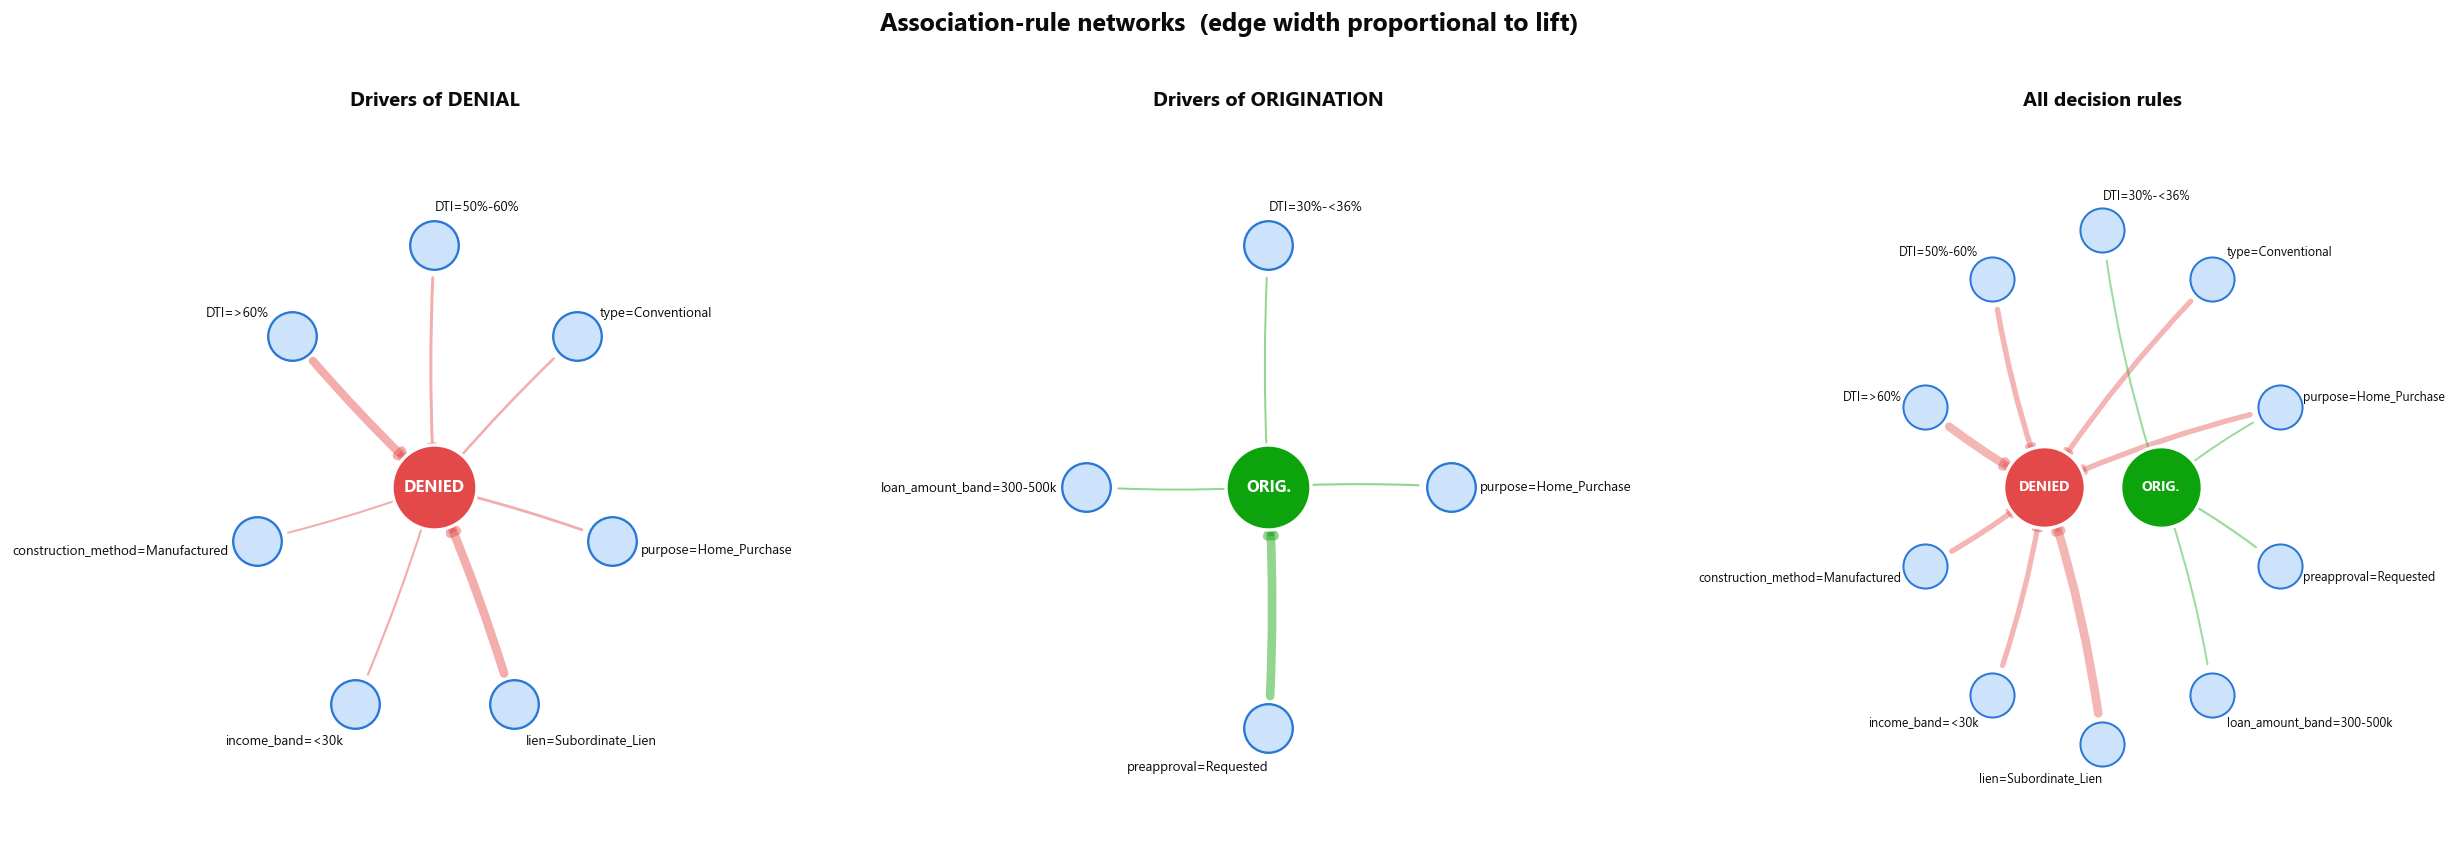

8 rule denial, 3 rule origination (sumber: final_rules (setelah pruning)).


In [341]:
import networkx as nx

ABBREV = {"debt_to_income_ratio": "DTI", "combined_loan_to_value_ratio": "CLTV",
          "loan_purpose": "purpose", "loan_type": "type", "occupancy_type": "occupancy",
          "derived_race": "race", "derived_ethnicity": "ethnicity", "lien_status": "lien",
          "tract_minority_cat": "tract", "tract_income_cat": "tract.inc",
          "applicant_age": "age", "conforming_loan_limit": "conforming"}

def _short(item):
    item = str(item)
    return f"{ABBREV.get(item.split('=', 1)[0], item.split('=', 1)[0])}={item.split('=', 1)[1]}" if "=" in item else item

def _radial_pos(ants, center=(0.0, 0.0), r=1.0, start=np.pi / 2):
    n = max(len(ants), 1)
    return {a: (center[0] + r * np.cos(start + 2 * np.pi * i / n),
                center[1] + r * np.sin(start + 2 * np.pi * i / n))
            for i, a in enumerate(sorted(ants))}

def _lw(w, lo, hi):
    return 2.4 if hi <= lo else 1.2 + (w - lo) / (hi - lo) * 4.0

def _draw_single(ax, rules_df, hub, hub_color, top_n, title):
    G = nx.DiGraph()
    for _, r in rules_df.head(top_n).iterrows():
        for a in str(r["antecedent"]).split(", "):
            G.add_edge(_short(a), hub, weight=float(r["lift"]))
    ants = [n for n in G.nodes if n != hub]
    pos = _radial_pos(ants, r=1.0); pos[hub] = (0.0, 0.0)
    ws = [G[u][v]["weight"] for u, v in G.edges()]; lo, hi = min(ws), max(ws)
    nx.draw_networkx_edges(G, pos, ax=ax, width=[_lw(w, lo, hi) for w in ws],
                           edge_color=hub_color, alpha=0.45, arrowsize=11,
                           connectionstyle="arc3,rad=0.03", node_size=1500)
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=ants, node_size=850,
                           node_color=NODE_FILL, edgecolors=NODE_EDGE, linewidths=1.4)
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[hub], node_size=2600,
                           node_color=hub_color, edgecolors="white", linewidths=2.0)
    ax.text(0, 0, hub, ha="center", va="center", color="white", fontsize=10, fontweight="bold", zorder=5)
    for a in ants:
        x, y = pos[a]
        ax.text(x * 1.16, y * 1.16, a, ha="left" if x >= 0 else "right", va="center", fontsize=8, color=INK)
    ax.set_title(title, fontweight="bold", fontsize=12, color=INK, pad=12, loc="center")
    ax.set_xlim(-1.9, 1.9); ax.set_ylim(-1.5, 1.5); ax.axis("off")

def _draw_all(ax, denied_df, orig_df, top_n, title):
    G = nx.DiGraph(); ecol = {}
    for _, r in denied_df.head(top_n).iterrows():
        for a in str(r["antecedent"]).split(", "):
            G.add_edge(_short(a), "DENIED", weight=float(r["lift"])); ecol[(_short(a), "DENIED")] = DENIED_COLOR
    for _, r in orig_df.head(top_n).iterrows():
        for a in str(r["antecedent"]).split(", "):
            G.add_edge(_short(a), "ORIGINATED", weight=float(r["lift"])); ecol[(_short(a), "ORIGINATED")] = ORIGINATED_COLOR
    hubs = ["DENIED", "ORIGINATED"]; ants = [n for n in G.nodes if n not in hubs]
    pos = _radial_pos(ants, r=1.35); pos["DENIED"] = (-0.42, 0.0); pos["ORIGINATED"] = (0.42, 0.0)
    edges = list(G.edges()); ws = [G[u][v]["weight"] for u, v in edges]; lo, hi = min(ws), max(ws)
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges, width=[_lw(w, lo, hi) for w in ws],
                           edge_color=[ecol[e] for e in edges], alpha=0.40, arrowsize=9,
                           connectionstyle="arc3,rad=0.05", node_size=1400)
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=ants, node_size=700,
                           node_color=NODE_FILL, edgecolors=NODE_EDGE, linewidths=1.2)
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=["DENIED"], node_size=2400,
                           node_color=DENIED_COLOR, edgecolors="white", linewidths=2.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=["ORIGINATED"], node_size=2400,
                           node_color=ORIGINATED_COLOR, edgecolors="white", linewidths=2.0)
    ax.text(-0.42, 0, "DENIED", ha="center", va="center", color="white", fontsize=8.5, fontweight="bold", zorder=5)
    ax.text(0.42, 0, "ORIG.", ha="center", va="center", color="white", fontsize=8.5, fontweight="bold", zorder=5)
    for a in ants:
        x, y = pos[a]
        ax.text(x * 1.13, y * 1.13, a, ha="left" if x >= 0 else "right", va="center", fontsize=7.5, color=INK)
    ax.set_title(title, fontweight="bold", fontsize=12, color=INK, pad=12, loc="center")
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-1.9, 1.9); ax.axis("off")

# Sumber = rule set setelah pruning. Menggambar decision_rules sebelum pruning akan
# menampilkan varian yang baru saja dinyatakan redundan pada 3.5, sehingga figure
# menyanggah teksnya sendiri.
_needed = {"antecedent", "consequent", "lift"}
if "final_rules" in globals() and _needed.issubset(set(final_rules.columns)):
    rule_source, _rules_for_network = "final_rules (setelah pruning)", final_rules
else:
    rule_source, _rules_for_network = "decision_rules (SEBELUM pruning - fallback)", decision_rules
    print("PERINGATAN: final_rules tidak tersedia; jaringan digambar sebelum pruning.")

denied_rules = _rules_for_network[_rules_for_network["consequent"] == "decision=Denied"].sort_values("lift", ascending=False)
orig_rules = _rules_for_network[_rules_for_network["consequent"] == "decision=Originated"].sort_values("lift", ascending=False)
print(f"Sumber jaringan rule: {rule_source}")

if len(denied_rules) or len(orig_rules):
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    fig.patch.set_facecolor("white")
    _draw_single(axes[0], denied_rules, "DENIED", DENIED_COLOR, 8, "Drivers of DENIAL")
    _draw_single(axes[1], orig_rules, "ORIG.", ORIGINATED_COLOR, 8, "Drivers of ORIGINATION")
    _draw_all(axes[2], denied_rules, orig_rules, 6, "All decision rules")
    fig.suptitle("Association-rule networks  (edge width proportional to lift)",
                 fontsize=15, fontweight="bold", color=INK, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "p3_rule_network.png", bbox_inches="tight")
    plt.show()
    print(f"{len(denied_rules)} rule denial, {len(orig_rules)} rule origination "
          f"(sumber: {rule_source}).")


### 3.9 - Geografi × DTI

Proyek secara eksplisit menanyakan geografi dan demografi: apakah proporsi minoritas pada tract berkaitan dengan approval setelah DTI dikendalikan? Bandingkan selisih di dalam kelompok DTI dengan selisih marginal. Hasil ini menunjukkan asosiasi, bukan penetapan pelanggaran fair-lending atau hubungan kausal.

In [342]:
DTI_GRP = cfg.DTI_GRP
tmp, marg, piv_rate, piv_n = p3.geography_dti_crosstab(appdeny, DTI_GRP)

print("Approval rate by tract minority band (marginal):")
print(marg.rename(columns={"mean": "approval_%", "size": "n"}).to_string())

print("\nApproval % by tract minority band WITHIN each DTI group:")
print(piv_rate.round(1).to_string())
print("\nCell counts:")
print(piv_n.to_string())

if {"Low_Minority", "Majority_Minority"}.issubset(piv_rate.index):
    gap = (piv_rate.loc["Low_Minority"] - piv_rate.loc["Majority_Minority"]).round(1)
    print(f"\nLow-minority minus majority-minority approval gap, within DTI group:\n{gap.to_string()}")


Approval rate by tract minority band (marginal):
                    approval_%      n
tract_minority_cat                   
Low_Minority              79.1  22844
Moderate_Minority         78.8  26756
High_Minority             73.1  11941
Majority_Minority         67.8   6286

Approval % by tract minority band WITHIN each DTI group:
dti_grp             High(>50%)  Low(<36%)  Mid(36-50%)  Unknown/Exempt
tract_minority_cat                                                    
Low_Minority              34.8       85.5         86.7            74.6
Moderate_Minority         39.3       85.4         86.1            74.6
High_Minority             37.0       78.7         82.9            70.4
Majority_Minority         33.0       73.4         80.3            66.3

Cell counts:
dti_grp             High(>50%)  Low(<36%)  Mid(36-50%)  Unknown/Exempt
tract_minority_cat                                                    
Low_Minority              2706       9178         9043            1917
Moderate_Min

### 3.10 - Mengapa pinjaman ditolak? Pola alasan denial

In [343]:
if len(denials):
    fi_dr = p3.denial_reason_itemsets(denials)
    print("Most frequent denial-reason itemsets:")
    print(fi_dr.sort_values("support", ascending=False).head(12).to_string(index=False))
else:
    print("No denial frame available.")


Most frequent denial-reason itemsets:
 support                               itemsets
0.305407                    (denial_reason_1=1)
0.270339                    (denial_reason_1=3)
0.137784                    (denial_reason_1=4)
0.114384                    (denial_reason_1=7)
0.089135                    (denial_reason_1=9)
0.040742                    (denial_reason_2=9)
0.039786                    (denial_reason_2=1)
0.039467                    (denial_reason_1=6)
0.036980                    (denial_reason_2=3)
0.030222 (denial_reason_1=1, denial_reason_2=3)


---
# Fase 4 — Deteksi Anomali dan Outlier

Fase ini membedakan **tiga level anomali** agar istilah yang dipakai konsisten dengan cara detektornya bekerja:

1. **Individual / global outlier** — satu aplikasi menyimpang dari distribusi seluruh dataset.  
   Dideteksi dengan **IQR, Z-score, dan Isolation Forest pada level record**.
2. **Contextual / local outlier** — satu aplikasi tidak harus ekstrem secara global, tetapi tidak wajar dibanding tetangga terdekatnya.  
   Dideteksi dengan **LOF** dan di-*cross-reference* dengan **DBSCAN noise** dari Fase 2.
3. **Collective anomaly candidate** — sekumpulan aplikasi secara individual dapat terlihat normal, tetapi **profil agregat kelompoknya** tidak biasa.  
   Untuk ini, aplikasi dikelompokkan berdasarkan kombinasi konteks bisnis (mis. state × loan purpose), lalu **Isolation Forest dijalankan lagi pada feature agregat level kelompok**.

Dengan pemisahan ini, Isolation Forest tidak diklaim otomatis menemukan pola kelompok ketika dijalankan pada record individual. Collective anomaly memiliki unit analisis berbeda: **kelompok**, bukan satu loan.

> Catatan: pola nominal HMDA yang berakhir `...5,000` tidak dipakai sebagai bukti collective anomaly karena pola tersebut berasal dari transformasi public-disclosure dan berlaku luas pada dataset, bukan hanya pada subset yang menyimpang.


### 4.1 - Flag statistik: IQR dan Z-score per fitur, lalu diagregasi

In [344]:
clean = p4.flag_statistical(clean, ANOMALY_FEATS)
print(f"IQR: rows flagged on >=1 feature = {(clean['iqr_n']>0).sum():,}; "
      f"on >=3 features = {(clean['iqr_n']>=3).sum():,}")
print(f"Z>3: rows flagged on >=1 feature = {(clean['z_n']>0).sum():,}")


IQR: rows flagged on >=1 feature = 57,202; on >=3 features = 7,085
Z>3: rows flagged on >=1 feature = 5,854


### 4.2 - Isolation Forest pada seluruh data

Isolation Forest flagged 1,000 anomalies (contamination=1%).


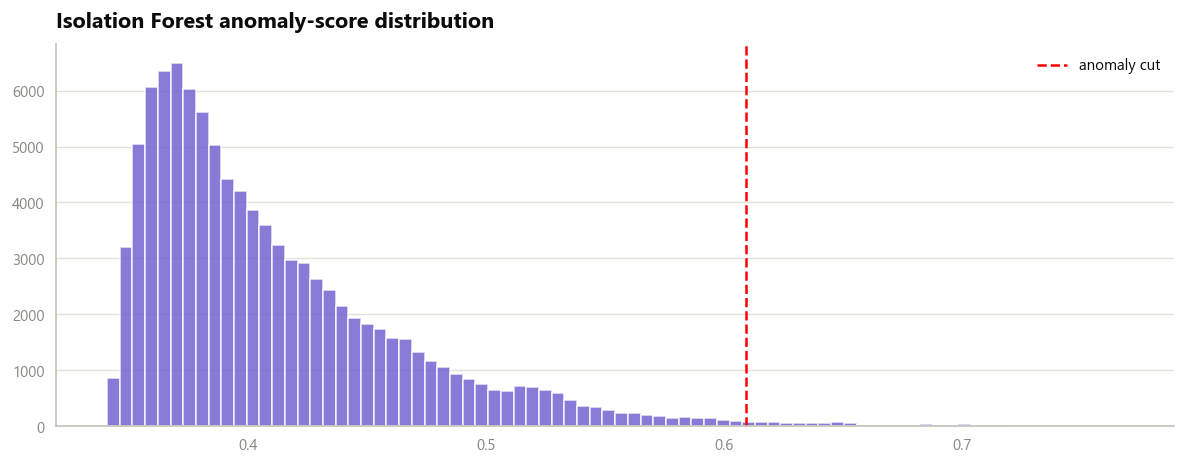

In [345]:
clean["iso_pred"], clean["iso_score"] = p4.run_isolation_forest(Xa, RANDOM_STATE)
print(f"Isolation Forest flagged {(clean['iso_pred']==-1).sum():,} anomalies (contamination=1%).")

plt.figure(figsize=(10, 4))
plt.hist(clean["iso_score"], bins=80, color="slateblue", alpha=0.8)
plt.axvline(clean.loc[clean["iso_pred"]==-1, "iso_score"].min(), color="red", ls="--", label="anomaly cut")
plt.title("Isolation Forest anomaly-score distribution"); plt.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "p4_iso_scores.png", bbox_inches="tight"); plt.show()


### 4.3 - LOF pada sampel 20 ribu

In [346]:
lof_flag, lof_ids = p4.run_lof(Xa, idx_med)
clean["lof_flag"] = lof_flag
print(f"LOF flagged {len(lof_ids):,} anomalies in the {len(idx_med):,}-row sample.")


LOF flagged 200 anomalies in the 20,000-row sample.


### 4.4 - Kesepakatan ensemble dan cross-reference DBSCAN

In [347]:
clean, vote = p4.ensemble_vote(clean, dbscan_noise_ids)
print("Anomaly agreement (number of methods flagging each row):")
print(vote.value_counts().sort_index().to_string())
print(f"\nHigh-confidence anomalies (>=3 methods): {(vote>=3).sum():,}")

both = clean.loc[list(dbscan_noise_ids)]
print(f"Of {len(dbscan_noise_ids):,} DBSCAN-noise rows, "
      f"{int(both['flag_iso'].sum()):,} also flagged by Isolation Forest.")


Anomaly agreement (number of methods flagging each row):
0    88971
1     7853
2     2432
3      649
4       80
5       10

High-confidence anomalies (>=3 methods): 739
Of 895 DBSCAN-noise rows, 87 also flagged by Isolation Forest.


**Validasi — apakah kumpulan detektor benar-benar membentuk ensemble?** Distribusi vote dan overlap Jaccard berpasangan dihitung di antara lima detektor. Kesepakatan yang bermakna, yaitu Jaccard jauh di atas sekitar 0,01 yang diperkirakan terjadi secara acak pada tingkat flag ini, membenarkan penggunaan vote count. Nilai mendekati nol di seluruh pasangan berarti kelima metode hanya memberikan pendapat yang tidak berkaitan. LOF dan DBSCAN dijalankan pada sampel, sehingga overlap keduanya dengan metode full-data dibatasi oleh cakupan sampel dan harus dibaca sebagai batas bawah.

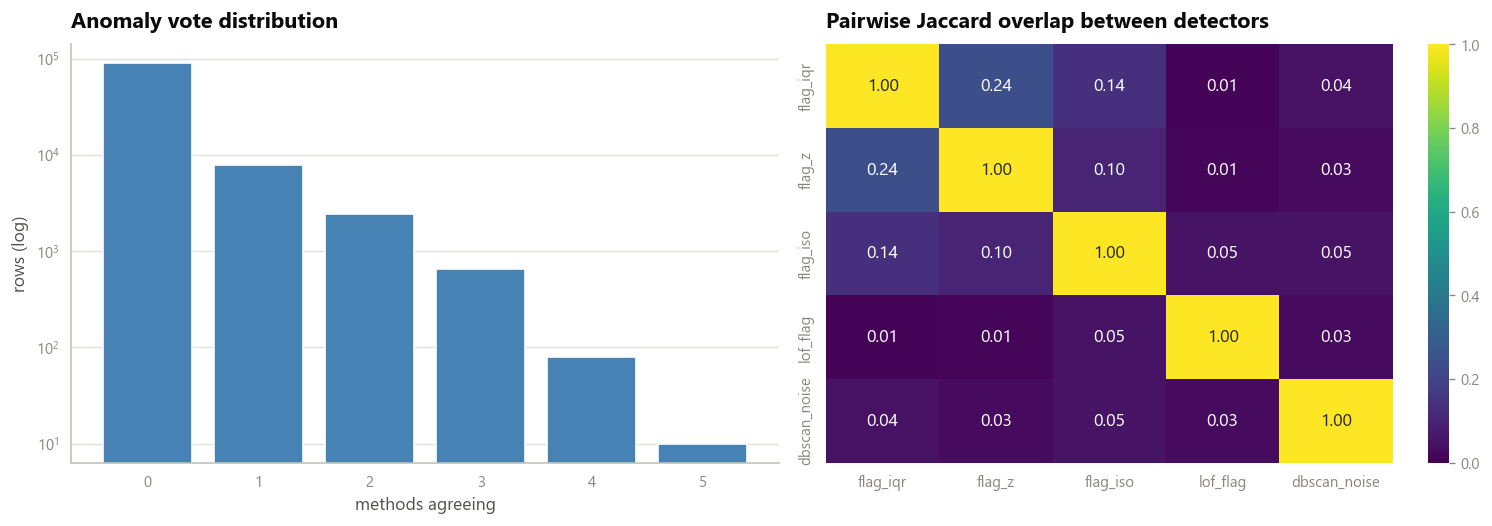

In [348]:
FLAGS = ["flag_iqr", "flag_z", "flag_iso", "lof_flag", "dbscan_noise"]
F = clean[FLAGS].astype(bool)
jac = pd.DataFrame(np.eye(len(FLAGS)), index=FLAGS, columns=FLAGS)
for a in FLAGS:
    for b in FLAGS:
        if a < b:
            inter = (F[a] & F[b]).sum()
            union = (F[a] | F[b]).sum()
            jac.loc[a, b] = jac.loc[b, a] = inter / union if union else 0.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
vd = vote.value_counts().sort_index()
axes[0].bar(vd.index.astype(int), vd.values, color="steelblue")
axes[0].set_yscale("log")
axes[0].set_xlabel("methods agreeing"); axes[0].set_ylabel("rows (log)")
axes[0].set_title("Anomaly vote distribution", fontweight="bold")
sns.heatmap(jac, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Pairwise Jaccard overlap between detectors", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p4_ensemble_agreement.png", bbox_inches="tight")
plt.show()


### 4.5 — Taksonomi eksplisit: individual/global vs contextual/local

Kelima sinyal yang sudah dihitung dipisahkan berdasarkan **unit pembandingnya**:

- `flag_iqr`, `flag_z`, `flag_iso` → **global/individual**, karena setiap record dibandingkan dengan distribusi seluruh populasi.
- `lof_flag`, `dbscan_noise` → **contextual/local**, karena keanehan ditentukan oleh lingkungan lokal atau kepadatan tetangganya.

Satu record dapat masuk keduanya. Kategori `Both` berarti aplikasi ekstrem terhadap populasi sekaligus tidak cocok dengan struktur lokal. Export ini dipakai dashboard agar angka global dan contextual berasal langsung dari notebook, bukan dihitung terpisah di UI.


In [349]:
# ------------------------------------------------------------
# Explicit record-level taxonomy
# ------------------------------------------------------------
GLOBAL_FLAGS = ["flag_iqr", "flag_z", "flag_iso"]
LOCAL_FLAGS = ["lof_flag", "dbscan_noise"]

missing_flags = [c for c in GLOBAL_FLAGS + LOCAL_FLAGS if c not in clean.columns]
assert not missing_flags, f"Required anomaly flags missing: {missing_flags}"

clean["global_outlier"] = clean[GLOBAL_FLAGS].fillna(False).astype(bool).any(axis=1)
clean["contextual_outlier"] = clean[LOCAL_FLAGS].fillna(False).astype(bool).any(axis=1)

clean["outlier_category"] = np.select(
    [
        clean["global_outlier"] & clean["contextual_outlier"],
        clean["global_outlier"],
        clean["contextual_outlier"],
    ],
    [
        "Both (global + contextual)",
        "Global outlier",
        "Contextual/local outlier",
    ],
    default="Normal",
)

tax_summary = (
    clean["outlier_category"]
    .value_counts()
    .reindex(
        ["Normal", "Global outlier", "Contextual/local outlier",
         "Both (global + contextual)"],
        fill_value=0,
    )
    .rename_axis("category")
    .reset_index(name="n")
)
tax_summary["pct"] = tax_summary["n"] / len(clean) * 100

print("Record-level anomaly taxonomy:")
print(tax_summary.to_string(index=False, formatters={"pct": lambda x: f"{x:.2f}%"}))

# Export a visualization-sized stratified sample, while keeping the exact
# full-population counts in a separate summary file.
tax_parts = []
for cat, sub in clean.groupby("outlier_category", observed=True):
    limit = 5000 if cat == "Normal" else 4000
    tax_parts.append(sub.sample(min(limit, len(sub)), random_state=RANDOM_STATE))
tax_export = pd.concat(tax_parts).sort_index()

tax_cols = [
    c for c in [
        "income", "loan_amount", "property_value",
        "combined_loan_to_value_ratio",
        "tract_minority_population_percent",
        "occupancy_type", "loan_purpose", "loan_type",
        "iso_score", "anomaly_votes", "outlier_category",
        "global_outlier", "contextual_outlier",
    ]
    if c in tax_export.columns
]
tax_export = tax_export[tax_cols].rename(columns={"outlier_category": "category"})

tax_export.to_csv(DATA_PROCESSED / "dash_outlier_taxonomy.csv", index=True)
tax_summary.to_csv(DATA_PROCESSED / "dash_outlier_taxonomy_summary.csv", index=False)

print(
    f"\nExported taxonomy: {len(tax_export):,} visualization rows + "
    f"{len(tax_summary)} full-population summary rows."
)


Record-level anomaly taxonomy:
                  category     n    pct
                    Normal 88971 88.98%
            Global outlier  9959  9.96%
  Contextual/local outlier   589  0.59%
Both (global + contextual)   476  0.48%

Exported taxonomy: 10,065 visualization rows + 4 full-population summary rows.


### 4.6 — Collective anomaly search: Isolation Forest pada profil kelompok

Isolation Forest pada 4.2 bekerja pada **satu aplikasi per baris**, sehingga hasilnya adalah individual/global anomaly. Untuk mencari collective anomaly, unit analisis diubah menjadi **kelompok aplikasi**.

Kelompok dibentuk dari beberapa kombinasi konteks yang tersedia sebelum outcome, misalnya:

- `state_code × loan_purpose`
- `state_code × loan_type`
- `loan_type × construction_method`
- `loan_purpose × construction_method`
- `occupancy_type × lien_status`

Untuk tiap kelompok dihitung median dan IQR dari fitur numerik Fase 4. **Isolation Forest kemudian dijalankan pada tabel agregat kelompok tersebut.** Dengan demikian yang dinilai aneh adalah *signature* kelompok, bukan satu loan.

Kolom `member_individual_flag_rate` dipertahankan sebagai audit penting: collective candidate paling menarik adalah kelompok dengan skor agregat aneh tetapi hanya sedikit anggotanya yang sudah ditandai sebagai individual/global atau contextual/local outlier.

Pendekatan ini bersifat **candidate discovery**, bukan bukti fraud atau error. Kelompok yang terflag tetap harus ditriase secara domain.


Skip product_x_construction: only 7 groups have n >= 50.
Skip occupancy_x_lien: only 6 groups have n >= 50.
Collective IF: 33 anomalous groups across 3 grouping schemes.
Pure collective candidates (group anomalous, <25% members individually flagged): 21
Unique applications belonging to >=1 anomalous group: 19,393 (19.39%).

Top collective group candidates:
            group_spec                       group_fields               group_values    n collective_iso_score member_individual_flag_rate  pure_collective_candidate
       state_x_product             state_code x loan_type          HI | Conventional  293               0.1802                       14.7%                       True
       state_x_product             state_code x loan_type          DC | Conventional  150               0.1690                       40.0%                      False
       state_x_purpose          state_code x loan_purpose    Unknown | Home_Purchase 1090               0.1667                       99.1%     

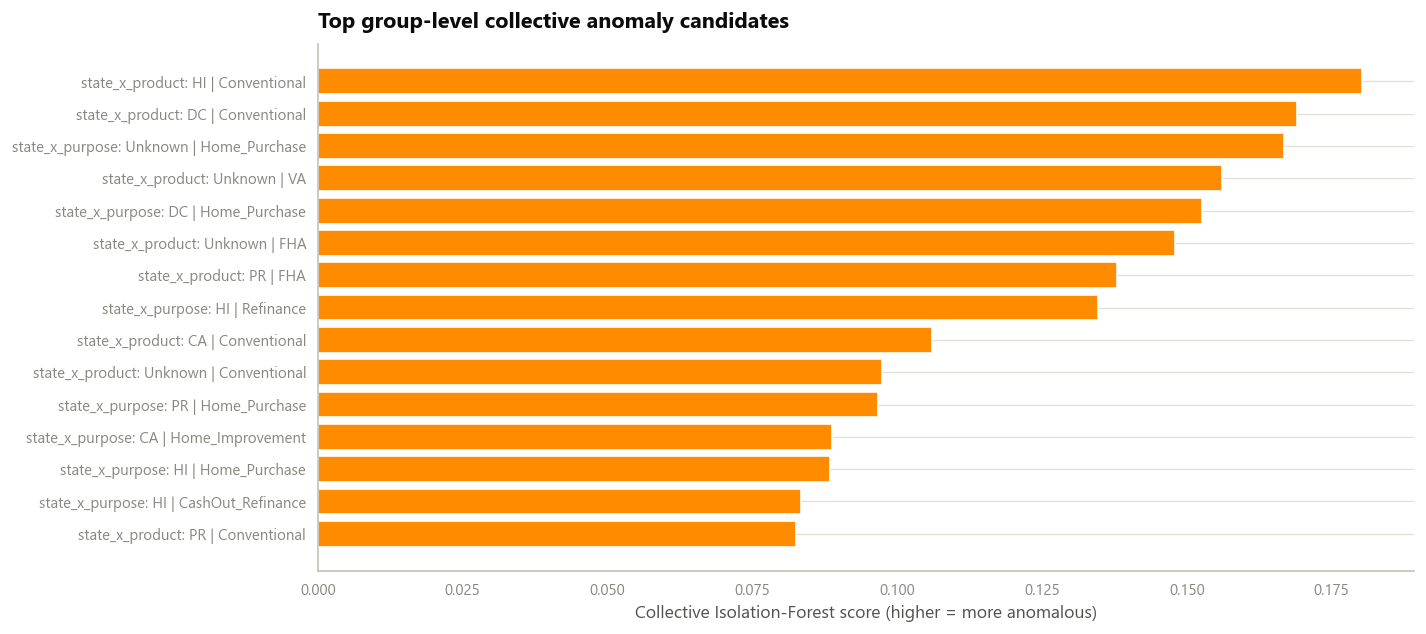


Interpretation rule: a member of an anomalous group is NOT automatically an anomalous loan. The group-level flag says the collection's aggregate signature needs investigation.


In [350]:
# ------------------------------------------------------------
# Group-level Collective Anomaly Detection
# ------------------------------------------------------------
# Outcome / denial fields are intentionally absent: this is structural anomaly
# discovery, not a model that predicts approval or denial.
COLLECTIVE_GROUP_SPECS = {
    "state_x_purpose": ["state_code", "loan_purpose"],
    "state_x_product": ["state_code", "loan_type"],
    "product_x_construction": ["loan_type", "construction_method"],
    "purpose_x_construction": ["loan_purpose", "construction_method"],
    "occupancy_x_lien": ["occupancy_type", "lien_status"],
}

collective_numeric = [
    c for c in ANOMALY_FEATS
    if c in clean.columns and pd.api.types.is_numeric_dtype(clean[c])
]
assert collective_numeric, "No numeric anomaly features available for group profiles."

# A member is already individually suspicious if either the global or local
# record-level detector family flagged it.
clean["_individual_any"] = clean["global_outlier"] | clean["contextual_outlier"]
clean["collective_group_hits"] = 0

MIN_GROUP_N = max(50, int(len(clean) * 0.0005))  # >=50 for a 100k-row sample
collective_profiles = []

def _collective_key(frame, cols):
    return (
        frame[cols]
        .astype("string")
        .fillna("<NA>")
        .agg(" | ".join, axis=1)
    )

for spec_name, requested_cols in COLLECTIVE_GROUP_SPECS.items():
    group_cols = [c for c in requested_cols if c in clean.columns]
    if len(group_cols) != len(requested_cols):
        print(f"Skip {spec_name}: missing {sorted(set(requested_cols) - set(group_cols))}")
        continue

    work_cols = group_cols + collective_numeric + ["_individual_any"]
    work = clean[work_cols].copy()
    work["_group_key"] = _collective_key(work, group_cols)

    g = work.groupby("_group_key", dropna=False, sort=False)

    med = g[collective_numeric].median().add_suffix("__median")
    q25 = g[collective_numeric].quantile(0.25).add_suffix("__q25")
    q75 = g[collective_numeric].quantile(0.75).add_suffix("__q75")

    group_profile = med.copy()
    for c in collective_numeric:
        group_profile[f"{c}__iqr"] = q75[f"{c}__q75"] - q25[f"{c}__q25"]

    group_profile["n"] = g.size()
    group_profile["member_individual_flag_rate"] = g["_individual_any"].mean()
    group_profile = group_profile[group_profile["n"] >= MIN_GROUP_N].copy()

    # Isolation Forest needs a reasonable number of groups to compare.
    if len(group_profile) < 10:
        print(f"Skip {spec_name}: only {len(group_profile)} groups have n >= {MIN_GROUP_N}.")
        continue

    model_cols = [
        c for c in group_profile.columns
        if c.endswith("__median") or c.endswith("__iqr")
    ]
    Xg = group_profile[model_cols].replace([np.inf, -np.inf], np.nan)

    # Fill any residual aggregate NaN robustly, then remove constant dimensions.
    Xg = Xg.fillna(Xg.median(numeric_only=True)).fillna(0.0)
    nonconstant = Xg.columns[Xg.nunique(dropna=False) > 1].tolist()
    if len(nonconstant) < 2:
        print(f"Skip {spec_name}: fewer than 2 non-constant aggregate dimensions.")
        continue

    Xg_scaled = RobustScaler().fit_transform(Xg[nonconstant])
    group_if = IsolationForest(
        n_estimators=300,
        contamination="auto",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    pred = group_if.fit_predict(Xg_scaled)

    # Higher value = more anomalous, easier to rank/read.
    group_profile["collective_iso_score"] = -group_if.decision_function(Xg_scaled)
    group_profile["collective_flag"] = pred == -1
    group_profile["group_spec"] = spec_name
    group_profile["group_fields"] = " x ".join(group_cols)
    group_profile["group_values"] = group_profile.index.astype(str)

    # A "pure collective" candidate is unusual as a group while at least 75%
    # of its members were NOT individually flagged. This is an interpretation
    # aid, not a training label.
    group_profile["pure_collective_candidate"] = (
        group_profile["collective_flag"]
        & (group_profile["member_individual_flag_rate"] < 0.25)
    )

    flagged_keys = set(group_profile.index[group_profile["collective_flag"]])
    if flagged_keys:
        row_keys = _collective_key(clean, group_cols)
        clean.loc[row_keys.isin(flagged_keys), "collective_group_hits"] += 1

    collective_profiles.append(group_profile.reset_index(drop=True))

if collective_profiles:
    collective_groups = pd.concat(collective_profiles, ignore_index=True)
    collective_groups = collective_groups.sort_values(
        ["collective_flag", "collective_iso_score"],
        ascending=[False, False],
    )

    flagged_groups = collective_groups[collective_groups["collective_flag"]].copy()
    pure_groups = flagged_groups[flagged_groups["pure_collective_candidate"]].copy()
    clean["collective_outlier_member"] = clean["collective_group_hits"] > 0

    n_collective_members = int(clean["collective_outlier_member"].sum())
    print(
        f"Collective IF: {len(flagged_groups):,} anomalous groups across "
        f"{collective_groups['group_spec'].nunique()} grouping schemes."
    )
    print(
        f"Pure collective candidates (group anomalous, <25% members individually flagged): "
        f"{len(pure_groups):,}"
    )
    print(
        f"Unique applications belonging to >=1 anomalous group: "
        f"{n_collective_members:,} ({n_collective_members/len(clean)*100:.2f}%)."
    )

    show_collective = [
        "group_spec", "group_fields", "group_values", "n",
        "collective_iso_score", "member_individual_flag_rate",
        "pure_collective_candidate",
    ]
    print("\nTop collective group candidates:")
    print(
        flagged_groups[show_collective]
        .head(20)
        .to_string(
            index=False,
            formatters={
                "collective_iso_score": lambda x: f"{x:.4f}",
                "member_individual_flag_rate": lambda x: f"{x*100:.1f}%",
            },
        )
    )

    # Small audit plot: the top group-level IF scores.
    plot_d = flagged_groups.head(15).copy()
    if len(plot_d):
        plot_d["label"] = plot_d["group_spec"] + ": " + plot_d["group_values"]
        plot_d = plot_d.sort_values("collective_iso_score")
        plt.figure(figsize=(12, max(4, 0.36 * len(plot_d))))
        plt.barh(plot_d["label"], plot_d["collective_iso_score"], color="darkorange")
        plt.xlabel("Collective Isolation-Forest score (higher = more anomalous)")
        plt.title("Top group-level collective anomaly candidates")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "p4_collective_group_if.png", bbox_inches="tight")
        plt.show()

    flagged_groups.to_csv(
        DATA_PROCESSED / "p4_collective_group_anomalies.csv", index=False
    )
    flagged_groups.head(100).to_csv(
        DATA_PROCESSED / "dash_collective_groups.csv", index=False
    )

    collective_summary = pd.DataFrame([{
        "grouping_schemes": int(collective_groups["group_spec"].nunique()),
        "flagged_groups": int(len(flagged_groups)),
        "pure_collective_groups": int(len(pure_groups)),
        "unique_member_rows": n_collective_members,
        "pct_member_rows": n_collective_members / len(clean) * 100,
        "median_member_individual_flag_rate": (
            float(flagged_groups["member_individual_flag_rate"].median())
            if len(flagged_groups) else np.nan
        ),
        "min_group_n": MIN_GROUP_N,
        "method": "IsolationForest on aggregated group profiles",
    }])
    collective_summary.to_csv(
        DATA_PROCESSED / "dash_collective_summary.csv", index=False
    )
else:
    collective_groups = pd.DataFrame()
    clean["collective_outlier_member"] = False
    print("No grouping specification produced enough groups for collective Isolation Forest.")

# Remove helper used only for this analysis.
clean.drop(columns=["_individual_any"], inplace=True)

print(
    "\nInterpretation rule: a member of an anomalous group is NOT automatically an "
    "anomalous loan. The group-level flag says the collection's aggregate signature "
    "needs investigation."
)


### 4.7 — Collective anomaly dari struktur clustering

Masukan dosen bahwa collective outlier sering tampak seperti **cluster kecil / pocket yang terlihat sebagai segmen tersendiri** diuji secara eksplisit di sini. Namun istilah yang digunakan tetap **collective anomaly candidate**, bukan "fake cluster", karena cluster yang jarang tetapi valid secara bisnis tetap merupakan segmentasi yang sah.

Dua pemeriksaan dilakukan:

#### A. Audit cluster K-Means yang sudah ada
Setiap dari 7 segmen K-Means diberi bukti tambahan:

- **rarity**: share cluster relatif kecil,
- **cohesion**: mean silhouette cukup baik,
- **isolation**: centroid cluster jauh dari centroid lain / populasi,
- **individual anomaly rate**: berapa persen anggotanya sudah dianggap aneh pada level record.

Kandidat collective yang paling menarik adalah cluster yang **kompak + terisolasi + mayoritas anggotanya normal secara individual**. Jika cluster tersebut juga stabil terhadap Ward/CLARANS, ia lebih tepat disebut *rare but legitimate collective segment* daripada cluster palsu.

#### B. Dense pockets dari DBSCAN
DBSCAN dapat menemukan beberapa pocket kepadatan sekaligus. Noise (`-1`) tetap diperlakukan sebagai local outlier, sedangkan **cluster DBSCAN non-noise** dibuat menjadi profil agregat dan dinilai dengan Isolation Forest pada level cluster. Ini memungkinkan **beberapa collective anomaly groups** muncul tanpa menentukan jumlahnya di awal.

Hasil dari business-group IF (4.6), K-Means structural audit, dan DBSCAN-cluster IF kemudian digabungkan ke satu **candidate registry** untuk ditriase.


In [351]:
# ------------------------------------------------------------
# A) Existing K-Means clusters as collective-anomaly candidates
# ------------------------------------------------------------
from sklearn.metrics import silhouette_samples

individual_any = clean["global_outlier"] | clean["contextual_outlier"]
labels_full = clean["kmeans_cluster"].to_numpy()
Xc_np = Xc.to_numpy()

k_ids = sorted(np.unique(labels_full))
centroids = {
    int(k): Xc_np[labels_full == k].mean(axis=0)
    for k in k_ids
}
global_center = Xc_np.mean(axis=0)

nearest_dist = {}
global_dist = {}
for k in k_ids:
    ck = centroids[int(k)]
    others = [
        np.linalg.norm(ck - centroids[int(j)])
        for j in k_ids if j != k
    ]
    nearest_dist[int(k)] = float(min(others)) if others else np.nan
    global_dist[int(k)] = float(np.linalg.norm(ck - global_center))

# Re-use the 4k stability sample for per-cluster silhouette.
sil_4k = silhouette_samples(Xc.iloc[idx_small].values,
                            clean["kmeans_cluster"].iloc[idx_small].to_numpy())
km_4k = clean["kmeans_cluster"].iloc[idx_small].to_numpy()
sil_by_cluster = {
    int(k): float(sil_4k[km_4k == k].mean())
    for k in np.unique(km_4k)
}

nearest_q75 = np.nanquantile(list(nearest_dist.values()), 0.75)
global_q75 = np.nanquantile(list(global_dist.values()), 0.75)
overall_sil_4k = float(sil_4k.mean())

km_collective_rows = []
for k in k_ids:
    mask = labels_full == k
    n = int(mask.sum())
    share = n / len(clean) * 100
    indiv_rate = float(individual_any.iloc[np.flatnonzero(mask)].mean())
    mean_sil = sil_by_cluster.get(int(k), np.nan)

    rare = share <= 10.0
    cohesive = bool(np.isfinite(mean_sil) and mean_sil >= overall_sil_4k)
    isolated = bool(
        nearest_dist[int(k)] >= nearest_q75
        or global_dist[int(k)] >= global_q75
    )
    mostly_individually_normal = indiv_rate < 0.25

    stability_row = (
        cluster_stability_audit[
            cluster_stability_audit["kmeans_cluster"] == int(k)
        ].iloc[0]
        if "cluster_stability_audit" in globals()
        and (cluster_stability_audit["kmeans_cluster"] == int(k)).any()
        else None
    )
    spurious_screen = (
        bool(stability_row["spurious_cluster_candidate"])
        if stability_row is not None else False
    )
    ward_purity = (
        float(stability_row["ward_purity_4k"])
        if stability_row is not None else np.nan
    )
    clarans_purity = (
        float(stability_row["clarans_purity_4k"])
        if stability_row is not None else np.nan
    )

    # This score is deliberately evidence-based rather than a hard "fake cluster" label.
    evidence_score = int(rare) + int(cohesive) + int(isolated) + int(mostly_individually_normal)
    collective_candidate = evidence_score >= 3

    if collective_candidate and spurious_screen:
        interpretation = "possible clustering artifact — inspect before business interpretation"
    elif collective_candidate:
        interpretation = "stable rare/isolated collective segment — likely legitimate unless domain triage says otherwise"
    else:
        interpretation = "ordinary business segment"

    segment_name = (
        str(profile.loc[k, "segment_name"])
        if "profile" in globals() and k in profile.index and "segment_name" in profile.columns
        else f"Cluster {k}"
    )

    km_collective_rows.append({
        "candidate_source": "KMeans cluster",
        "candidate_id": f"KMeans C{int(k)}",
        "segment_name": segment_name,
        "n": n,
        "share_pct": share,
        "mean_silhouette_4k": mean_sil,
        "nearest_centroid_distance": nearest_dist[int(k)],
        "global_centroid_distance": global_dist[int(k)],
        "member_individual_flag_rate": indiv_rate,
        "ward_purity_4k": ward_purity,
        "clarans_purity_4k": clarans_purity,
        "rare_le10pct": rare,
        "cohesive_ge_global_sil": cohesive,
        "isolated_top_quartile": isolated,
        "mostly_individually_normal": mostly_individually_normal,
        "evidence_score_0_4": evidence_score,
        "spurious_cluster_screen": spurious_screen,
        "collective_candidate": collective_candidate,
        "interpretation": interpretation,
    })

kmeans_collective_audit = pd.DataFrame(km_collective_rows).sort_values(
    ["collective_candidate", "evidence_score_0_4", "global_centroid_distance"],
    ascending=[False, False, False],
)

print("K-Means -> cluster-based collective audit:")
print(
    kmeans_collective_audit[
        [
            "candidate_id", "segment_name", "n", "share_pct",
            "mean_silhouette_4k", "member_individual_flag_rate",
            "evidence_score_0_4", "spurious_cluster_screen",
            "collective_candidate", "interpretation",
        ]
    ].to_string(
        index=False,
        formatters={
            "share_pct": lambda x: f"{x:.2f}%",
            "mean_silhouette_4k": lambda x: f"{x:.3f}",
            "member_individual_flag_rate": lambda x: f"{x*100:.1f}%",
        },
    )
)

kmeans_collective_audit.to_csv(
    DATA_PROCESSED / "p4_kmeans_collective_audit.csv", index=False
)

# ------------------------------------------------------------
# B) DBSCAN dense clusters -> aggregate profiles -> Isolation Forest
# ------------------------------------------------------------
db_pos = np.asarray(idx_med)
db_labels_arr = np.asarray(db_labels)

db_work = Xc.iloc[db_pos].copy()
db_work["dbscan_cluster"] = db_labels_arr
db_work["kmeans_cluster"] = clean["kmeans_cluster"].iloc[db_pos].to_numpy()
db_work["member_individual_flag"] = individual_any.iloc[db_pos].to_numpy()

# Noise = contextual/local individual outlier, not a collective cluster.
db_clustered = db_work[db_work["dbscan_cluster"] != -1].copy()

db_rows = []
for cid, sub in db_clustered.groupby("dbscan_cluster", sort=True):
    # Ignore microscopic pockets that are too small to interpret as a collective group.
    if len(sub) < max(30, int(min_samples)):
        continue

    feature_cols = [c for c in CLUSTER_FEATS if c in sub.columns]
    row = {
        "dbscan_cluster": int(cid),
        "n": int(len(sub)),
        "share_of_20k_pct": len(sub) / len(db_work) * 100,
        "member_individual_flag_rate": float(sub["member_individual_flag"].mean()),
    }

    km_vc = sub["kmeans_cluster"].value_counts(normalize=True)
    row["dominant_kmeans_cluster"] = int(km_vc.index[0]) if len(km_vc) else -1
    row["kmeans_purity"] = float(km_vc.iloc[0]) if len(km_vc) else np.nan

    for f in feature_cols:
        vals = pd.to_numeric(sub[f], errors="coerce")
        row[f"{f}__median"] = float(vals.median())
        row[f"{f}__iqr"] = float(vals.quantile(0.75) - vals.quantile(0.25))
    db_rows.append(row)

dbscan_collective_audit = pd.DataFrame(db_rows)

if len(dbscan_collective_audit) >= 10:
    model_cols = [
        c for c in dbscan_collective_audit.columns
        if c.endswith("__median") or c.endswith("__iqr")
    ]
    X_db_group = (
        dbscan_collective_audit[model_cols]
        .replace([np.inf, -np.inf], np.nan)
    )
    X_db_group = X_db_group.fillna(X_db_group.median(numeric_only=True)).fillna(0.0)
    nonconstant = X_db_group.columns[
        X_db_group.nunique(dropna=False) > 1
    ].tolist()

    if len(nonconstant) >= 2:
        X_db_scaled = RobustScaler().fit_transform(X_db_group[nonconstant])

        db_group_if = IsolationForest(
            n_estimators=300,
            contamination="auto",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        pred = db_group_if.fit_predict(X_db_scaled)
        dbscan_collective_audit["collective_iso_score"] = (
            -db_group_if.decision_function(X_db_scaled)
        )
        dbscan_collective_audit["collective_if_flag"] = pred == -1
        dbscan_collective_audit["pure_collective_candidate"] = (
            dbscan_collective_audit["collective_if_flag"]
            & (dbscan_collective_audit["member_individual_flag_rate"] < 0.25)
        )

        dbscan_collective_audit["interpretation"] = np.select(
            [
                dbscan_collective_audit["pure_collective_candidate"]
                & (dbscan_collective_audit["kmeans_purity"] >= 0.70),
                dbscan_collective_audit["pure_collective_candidate"],
                dbscan_collective_audit["collective_if_flag"],
            ],
            [
                "dense unusual pocket aligned with one K-Means segment; likely rare legitimate subsegment",
                "dense unusual pocket crossing K-Means segments; strongest cluster-shaped collective candidate",
                "group-level unusual, but many members are already individual anomalies",
            ],
            default="ordinary DBSCAN dense region",
        )
    else:
        dbscan_collective_audit["collective_iso_score"] = np.nan
        dbscan_collective_audit["collective_if_flag"] = False
        dbscan_collective_audit["pure_collective_candidate"] = False
        dbscan_collective_audit["interpretation"] = "insufficient non-constant group features"
else:
    dbscan_collective_audit["collective_iso_score"] = np.nan
    dbscan_collective_audit["collective_if_flag"] = False
    dbscan_collective_audit["pure_collective_candidate"] = False
    dbscan_collective_audit["interpretation"] = "too few DBSCAN groups for group-level Isolation Forest"

if len(dbscan_collective_audit):
    dbscan_collective_audit = dbscan_collective_audit.sort_values(
        ["pure_collective_candidate", "collective_if_flag", "collective_iso_score"],
        ascending=[False, False, False],
    )

    print("\nDBSCAN dense-pocket collective audit:")
    print(
        dbscan_collective_audit[
            [
                "dbscan_cluster", "n", "share_of_20k_pct",
                "member_individual_flag_rate", "dominant_kmeans_cluster",
                "kmeans_purity", "collective_iso_score",
                "collective_if_flag", "pure_collective_candidate",
                "interpretation",
            ]
        ].head(30).to_string(
            index=False,
            formatters={
                "share_of_20k_pct": lambda x: f"{x:.2f}%",
                "member_individual_flag_rate": lambda x: f"{x*100:.1f}%",
                "kmeans_purity": lambda x: f"{x:.2f}",
                "collective_iso_score": lambda x: (
                    f"{x:.4f}" if np.isfinite(x) else "NA"
                ),
            },
        )
    )

dbscan_collective_audit.to_csv(
    DATA_PROCESSED / "p4_dbscan_collective_audit.csv", index=False
)

# ------------------------------------------------------------
# C) Unified registry: allow MULTIPLE collective candidates
# ------------------------------------------------------------
registry = []

# Existing business-context group IF from section 4.6
if "flagged_groups" in globals() and isinstance(flagged_groups, pd.DataFrame):
    for _, r in flagged_groups.iterrows():
        registry.append({
            "candidate_source": "Business-group IsolationForest",
            "candidate_id": f"{r.get('group_spec', 'group')}: {r.get('group_values', '')}",
            "n": int(r.get("n", 0)),
            "member_individual_flag_rate": float(r.get("member_individual_flag_rate", np.nan)),
            "score": float(r.get("collective_iso_score", np.nan)),
            "candidate": bool(r.get("pure_collective_candidate", False)),
            "evidence": "Aggregate business-context profile is unusual under group-level Isolation Forest.",
        })

# K-Means structural candidates
for _, r in kmeans_collective_audit[kmeans_collective_audit["collective_candidate"]].iterrows():
    registry.append({
        "candidate_source": "KMeans structural cluster",
        "candidate_id": str(r["candidate_id"]),
        "n": int(r["n"]),
        "member_individual_flag_rate": float(r["member_individual_flag_rate"]),
        "score": float(r["evidence_score_0_4"]),
        "candidate": True,
        "evidence": (
            f"{r['segment_name']}; evidence {int(r['evidence_score_0_4'])}/4; "
            f"spurious-screen={bool(r['spurious_cluster_screen'])}. "
            f"{r['interpretation']}"
        ),
    })

# DBSCAN dense-pocket candidates
if len(dbscan_collective_audit):
    for _, r in dbscan_collective_audit[
        dbscan_collective_audit["collective_if_flag"]
    ].iterrows():
        registry.append({
            "candidate_source": "DBSCAN dense-cluster IsolationForest",
            "candidate_id": f"DBSCAN C{int(r['dbscan_cluster'])}",
            "n": int(r["n"]),
            "member_individual_flag_rate": float(r["member_individual_flag_rate"]),
            "score": float(r["collective_iso_score"]) if np.isfinite(r["collective_iso_score"]) else np.nan,
            "candidate": bool(r["pure_collective_candidate"]),
            "evidence": (
                f"Dominant KMeans=C{int(r['dominant_kmeans_cluster'])}, "
                f"purity={float(r['kmeans_purity']):.2f}. {r['interpretation']}"
            ),
        })

collective_candidate_registry = pd.DataFrame(registry)
if len(collective_candidate_registry):
    collective_candidate_registry = collective_candidate_registry.sort_values(
        ["candidate", "candidate_source", "score"],
        ascending=[False, True, False],
    )
    print("\nUnified collective-anomaly candidate registry:")
    print(
        collective_candidate_registry.to_string(
            index=False,
            formatters={
                "member_individual_flag_rate": lambda x: (
                    f"{x*100:.1f}%" if np.isfinite(x) else "NA"
                ),
                "score": lambda x: f"{x:.4f}" if np.isfinite(x) else "NA",
            },
        )
    )
else:
    print(
        "\nNo collective candidate was produced by the current run. "
        "That is a valid result; the method does not force a collective anomaly to exist."
    )

collective_candidate_registry.to_csv(
    DATA_PROCESSED / "p4_collective_candidate_registry.csv", index=False
)

print(
    "\nImportant interpretation: 'collective candidate' means a group deserves investigation. "
    "It does not mean every member is anomalous, fraudulent, or erroneous."
)


K-Means -> cluster-based collective audit:
candidate_id                    segment_name     n share_pct mean_silhouette_4k member_individual_flag_rate  evidence_score_0_4  spurious_cluster_screen  collective_candidate                                                                                  interpretation
   KMeans C3 Manufactured-housing applicants  4529     4.53%              0.495                        8.7%                   4                    False                  True stable rare/isolated collective segment — likely legitimate unless domain triage says otherwise
   KMeans C1              Property investors  7036     7.04%              0.334                       22.2%                   4                    False                  True stable rare/isolated collective segment — likely legitimate unless domain triage says otherwise
   KMeans C5   Jumbo / high-net-worth buyers  4447     4.45%              0.167                       61.0%                   2                 

### 4.8 - Triage anomali utama

Setiap catatan utama memperoleh verdict eksplisit beserta bukti:

- **DATA ERROR:** nilai mustahil, seperti CLTV ribuan, tenor lebih dari 50 tahun, atau income yang tidak masuk akal; kolom `income` HMDA menggunakan satuan ribuan dolar.
- **RARE BUT VALID:** transaksi jumbo, multifamily, atau investment yang benar-benar valid.
- **RISK SIGNAL:** kombinasi tidak biasa tetapi masih mungkin, misalnya kondisi underwater pada origination dengan income rendah.
- **MANUAL REVIEW:** magnitudo ekstrem tanpa ciri error yang jelas; catatan perlu diperiksa manual dan verdict dapat diperbarui pada laporan.


In [352]:
top_anom, show_cols = p4.triage_top(clean, n=15)

print("TOP 15 ANOMALIES -- triaged:")
print(top_anom[show_cols + ["verdict", "evidence"]].to_string())
print("\nVerdict counts:", top_anom["verdict"].value_counts().to_dict())

p4.export_phase4(top_anom, clean, show_cols, DATA_PROCESSED)


TOP 15 ANOMALIES -- triaged:
        income  loan_amount  property_value  combined_loan_to_value_ratio  loan_term       loan_purpose       occupancy_type total_units                      action_taken  anomaly_votes  iso_score         verdict                                           evidence
61411  45173.0     20005000      46505000.0                       43.0110      360.0  CashOut_Refinance  Principal_Residence           1                        Originated              5   0.767801  RARE BUT VALID                             jumbo loan $20,005,000
60075   3472.0      8005000      11505000.0                       69.5650      360.0      Home_Purchase  Principal_Residence           1  Preapproval_Approved_NotAccepted              5   0.758836  RARE BUT VALID                              jumbo loan $8,005,000
31067     95.0     40485000     116805000.0                       34.6600       36.0          Refinance           Investment       50-99                        Originated         

**Menutup siklus — apakah detektor menemukan kembali pola yang diprediksi diagnostik?** Baris yang ditandai oleh seluruh lima metode diberi label dengan aturan triage yang sama. Label data error mengonfirmasi bahwa temuan CLTV, tenor, dan income dari pemindaian struktural ditemukan kembali secara independen oleh ensemble. Label valid merupakan penemuan catatan langka yang memang nyata.

In [353]:
unanimous = clean[clean["anomaly_votes"] == 5]
labels = unanimous.apply(p4.triage, axis=1)
print(f"Rows flagged by all 5 detectors: {len(unanimous)}")
print(labels.map(lambda t: t[0]).value_counts().to_string(), "\n")
show = [c for c in ["income", "loan_amount", "property_value", "combined_loan_to_value_ratio",
                    "loan_term", "action_taken"] if c in unanimous.columns]
print(unanimous[show].round(1).to_string())


Rows flagged by all 5 detectors: 10
RARE BUT VALID    8
MANUAL REVIEW     2 

        income  loan_amount  property_value  combined_loan_to_value_ratio  loan_term                      action_taken
7727     758.0      1005000       9205000.0                          40.9      300.0                        Originated
31067     95.0     40485000     116805000.0                          34.7       36.0                        Originated
43427     95.0       955000        225000.0                           4.2      360.0                        Originated
50530    265.0       415000       2645000.0                          15.7       36.0                        Originated
60075   3472.0      8005000      11505000.0                          69.6      360.0  Preapproval_Approved_NotAccepted
61411  45173.0     20005000      46505000.0                          43.0      360.0                        Originated
64299   1022.0       105000        795000.0                          12.7       36.0     

### 4.9 - Penyelesaian manual review

Tiga baris bertahan dari triage otomatis sebagai `MANUAL REVIEW`: 7727 dan 95313 ditandai oleh kelima detektor, sedangkan 8102 memperoleh empat vote. Peninjauan manual menerapkan satu uji yang membedakan data error dari catatan langka tetapi nyata, yaitu **konsistensi internal**: apakah `CLTV × property_value` konsisten dengan loan ini ditambah senior lien, dan apakah income yang dilaporkan masuk akal untuk membayar utang?

Ketiga baris ternyata konsisten secara tepat, dengan detail dicetak pada cell berikutnya, sehingga seluruhnya diklasifikasikan sebagai **RARE BUT VALID**. Catatan tersebut merupakan properti pesisir bernilai tinggi, sekitar $2,5 juta–$9,3 juta di CA/NY, dengan CLTV rendah dan income tinggi. Detektor bereaksi terhadap besarnya magnitudo, bukan kombinasi yang mustahil, sesuai prediksi pemindaian struktural Fase 1 bahwa ensemble akan menemukan transaksi nyata yang sangat langka di luar ekstrem CLTV dan tenor yang telah diketahui. Akhiran nominal loan `…5,000` diperlakukan hanya sebagai artefak transformasi public-disclosure HMDA dan **tidak** digunakan sebagai bukti collective anomaly; collective anomaly kini dicari secara terpisah melalui Isolation Forest pada profil agregat kelompok. Hasil akhir: **15 dari 15 anomali utama telah diklasifikasikan dengan bukti dan tidak ada kasus yang belum terselesaikan.**


In [354]:
# Peninjauan manual untuk tiga baris MANUAL REVIEW. Uji yang digunakan adalah konsistensi internal:
# apakah CLTV x property_value konsisten dengan loan ini ditambah senior lien, serta apakah
# income yang dilaporkan masuk akal untuk membayar utang. Bila ya, catatan ekstrem tetapi nyata.
MANUAL_RESOLUTION = {
    7727:  ("RARE BUT VALID",
            "subordinate lien of $1,005,000 on a $9,205,000 CA principal residence; "
            "CLTV 40.9% x $9.2M = $3.77M total liens >= this loan, so a senior first lien "
            "exists and the figures reconcile; income $758k/yr supports the debt -> "
            "high-net-worth equity draw, not a data error"),
    95313: ("RARE BUT VALID",
            "$35,000 home-improvement second lien on a $2,495,000 CA home; CLTV 19.9% x "
            "$2.5M = $498k total liens >= this loan; every magnitude is plausible -> flagged "
            "only for the tiny-loan-on-expensive-home contrast (and it was denied anyway)"),
    8102:  ("RARE BUT VALID",
            "$2,505,000 cash-out first-lien refinance of a $9,305,000 NY second residence; "
            "CLTV 26.9% x $9.3M = $2.50M = the loan itself, i.e. arithmetically "
            "self-consistent; income $1.08M at DTI 36%-<43% fits a jumbo borrower"),
}

top_anom = p4.resolve_manual_review(top_anom, MANUAL_RESOLUTION)

resolved_ids = [i for i in MANUAL_RESOLUTION if i in top_anom.index]
detail = [c for c in ["income", "loan_amount", "property_value", "combined_loan_to_value_ratio",
                      "lien_status", "occupancy_type", "state_code", "debt_to_income_ratio",
                      "action_taken", "anomaly_votes", "verdict"] if c in top_anom.columns]
print("MANUAL REVIEW rows -> resolved:")
print(top_anom.loc[resolved_ids, detail].to_string())
for idx in resolved_ids:
    print(f"\nrow {idx}: {MANUAL_RESOLUTION[idx][0]}\n  evidence: {MANUAL_RESOLUTION[idx][1]}")

print("\nFinal verdict counts (top 15):", top_anom["verdict"].value_counts().to_dict())
top_anom[show_cols + ["verdict", "evidence"]].to_csv(DATA_PROCESSED / "p4_anomaly_triage.csv")
print("p4_anomaly_triage.csv re-exported with final verdicts - no row remains unclassified.")


MANUAL REVIEW rows -> resolved:
       income  loan_amount  property_value  combined_loan_to_value_ratio       lien_status       occupancy_type state_code debt_to_income_ratio action_taken  anomaly_votes         verdict
7727    758.0      1005000       9205000.0                        40.920  Subordinate_Lien  Principal_Residence         CA              50%-60%   Originated              5  RARE BUT VALID
95313   165.0        35000       2495000.0                        19.940  Subordinate_Lien  Principal_Residence         CA             30%-<36%       Denied              5  RARE BUT VALID
8102   1082.0      2505000       9305000.0                        26.882        First_Lien     Second_Residence         NY             36%-<43%   Originated              4  RARE BUT VALID

row 7727: RARE BUT VALID
  evidence: subordinate lien of $1,005,000 on a $9,205,000 CA principal residence; CLTV 40.9% x $9.2M = $3.77M total liens >= this loan, so a senior first lien exists and the figures reconci

---
# Fase 5 — Dashboard Interaktif, Knowledge Report, dan Audit Rubric

Notebook membangun lapisan komunikasi akhir secara langsung sehingga file `dashboard_app.py` terpisah tidak diperlukan.

- **Dashboard interaktif:** file HTML mandiri dengan tab Overview, Segments, Rules, Anomalies, dan Fairness. Agregasi mahal dilakukan satu kali; hover, zoom, filter legend, dan perpindahan tab berjalan di sisi browser agar responsif.
- **Knowledge report:** temuan cluster, rule, anomali, dan fairness terkuat diterjemahkan otomatis ke bahasa bisnis yang mudah dipahami sambil mempertahankan batas interpretasi non-kausal.
- **Audit rubric:** pemeriksaan yang dapat dieksekusi memastikan setiap kriteria tingkat Excellent telah direpresentasikan sebelum submission.

In [355]:
p5.export_dashboard_aggregates(clean, appdeny, denials, DATA_PROCESSED, RANDOM_STATE)

print("Dashboard data exported:")
for fn in ["p2_cluster_profiles.csv", "p3_decision_rules.csv", "p3_decision_rules_final.csv",
           "p4_anomaly_flags.csv", "p4_anomaly_triage.csv",
           "dash_approval_disparity.csv", "dash_scatter.csv", "dash_denial_reasons.csv"]:
    print(f"  - {fn}")


D:\Documents\Kuliah\Cawu 5\Data Mining\Final\pipeline\phase5_reporting.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disparity = (appdeny.groupby(["derived_race", "tract_minority_cat"])["target_approved"]


Dashboard data exported:
  - p2_cluster_profiles.csv
  - p3_decision_rules.csv
  - p3_decision_rules_final.csv
  - p4_anomaly_flags.csv
  - p4_anomaly_triage.csv
  - dash_approval_disparity.csv
  - dash_scatter.csv
  - dash_denial_reasons.csv


### Ekspor agregat Fase 1

Menulis ringkasan pembersihan, missingness per kolom, dan ranking fitur yang dibaca
tab Fase 1 pada dashboard.


In [356]:
p5.export_phase1_aggregates(
    miss, high_missing, feature_selection_audit,
    n_before, n_dupes, residual_missing_after_cleaning, DATA_PROCESSED)


Phase 1 dashboard aggregates: 17 missing fields, 20 ranked features, 99,995 clean rows


### Keluaran dashboard

Jalankan cell berikut setelah Fase 1–4. Cell tersebut menghasilkan:

- `HMDA_Interactive_Dashboard.html` — dashboard interaktif mandiri yang dapat dibuka di browser;
- `Preprocessing_Report.md` — jejak audit ringkas untuk keputusan cleaning dan transformation;
- `Knowledge_Discovery_Report.md` — jawaban dengan bahasa umum terhadap pertanyaan utama penemuan;
- `HMDA_Rubric_Audit.csv` — pemeriksaan submission untuk setiap kriteria.

Dashboard menggunakan tabel yang telah diagregasi dan sampel scatter yang dibatasi. Setelah halaman dimuat, seluruh interaksi diproses oleh browser tanpa menghitung ulang dataset 100.000 baris.

In [357]:
# Guard: `profile` must still be the Phase-2 K-Means cluster-profile table.
required_profile_cols = {"approval_rate", "segment_name"}
missing_profile_cols = required_profile_cols - set(profile.columns)
assert not missing_profile_cols, (
    "Phase-2 `profile` was overwritten before Phase 5. "
    f"Missing columns: {sorted(missing_profile_cols)}"
)

# Hasilkan laporan preprocessing dan pengetahuan yang ringkas dengan bahasa umum.
# Ditulis ke *_generated.md agar laporan yang disubmit (reports/Preprocessing_Report.md dan
# reports/Knowledge_Discovery_Report.md, ditulis tangan) tidak pernah tertimpa oleh cell ini.
preprocessing_report, knowledge_report = p5.write_reports(
    appdeny, clean, profile, final_rules, top_anom, fair_pivot,
    n_dupes, high_missing, MISSING_DROP_THRESHOLD, residual_missing_after_cleaning, REPORTS_DIR)

print("Generated Preprocessing_Report_generated.md and Knowledge_Discovery_Report_generated.md")
print("(submitted reports/Preprocessing_Report.md and Knowledge_Discovery_Report.md are hand-written and untouched)")


Generated Preprocessing_Report_generated.md and Knowledge_Discovery_Report_generated.md
(submitted reports/Preprocessing_Report.md and Knowledge_Discovery_Report.md are hand-written and untouched)


In [358]:
# Audit akhir yang dapat dieksekusi terhadap rubric Excellent.
required_rule_cols = {"support", "confidence", "lift"}

# Evaluasi cleaning pada titik ketika proses cleaning benar-benar selesai.
# Tabel analisis berikutnya sengaja dapat memuat NaN pada kolom bantu, misalnya
# `_approved` pada baris tanpa keputusan, dan kondisi itu tidak boleh membatalkan preprocessing.
cleaning_missing_cells = int(
    globals().get("residual_missing_after_cleaning", df.isna().sum().sum())
)
duplicates_checked = (
    "n_dupes" in globals()
    and isinstance(n_dupes, (int, np.integer))
)
cleaning_passed = cleaning_missing_cells == 0 and duplicates_checked
cleaning_evidence = (
    f"{cleaning_missing_cells:,} missing cells after handling; "
    f"duplicate check recorded ({int(n_dupes):,} removed)."
    if duplicates_checked
    else f"{cleaning_missing_cells:,} missing cells after handling; duplicate check not found."
)

audit_rows = [
    ("5.1 Data Cleaning",
     cleaning_passed,
     cleaning_evidence),
    ("5.1 Data Transformation",
     all(c in df.columns for c in ["income_band", "loan_amount_band", "cltv_band"])
     and "Xc" in globals() and "Xa" in globals(),
     "Domain binning plus phase-appropriate StandardScaler/RobustScaler matrices."),
    ("5.1 Feature Selection",
     "corr_target" in globals() and "mi_series" in globals()
     and (TABLE_DIR / "p1_feature_selection_audit.csv").exists(),
     "Correlation, redundancy screening, and entropy-based Mutual Information documented."),
    ("5.1 Multicollinearity Audit",
     "vif" in globals() and len(globals().get("vif_flagged", [])) == 0,
     (f"VIF computed for all numeric features; {len(globals().get('vif_flagged', []))} "
      f"above the VIF>10 threshold (equivalent to the pairwise r>0.90 rule of 9b)."
      if "vif" in globals() else
      "Section 9c not executed - run it before submission.")),
    ("5.2 Algorithm Application",
     "kmeans_cluster" in clean.columns and "db_labels" in globals() and "hier_labels" in globals(),
     "K-Means, DBSCAN, and Ward hierarchical clustering executed."),
    ("5.2 Optimal K Selection",
     "elbow_k" in globals() and "sil_k" in globals() and "BEST_K" in globals(),
     f"Elbow={elbow_k}; silhouette optimum={sil_k}; selected K={BEST_K}."),
    ("5.2 Cluster Profiling",
     "profile" in globals() and "segment_name" in profile.columns and profile["segment_name"].notna().all(),
     f"{len(profile)} named segments with size, medians, approval, and business interpretation."),
    ("5.3 Discretization",
     all(c in appdeny.columns for c in ["income_band", "loan_amount_band", "cltv_band",
                                        "tract_income_cat", "tract_minority_cat"]),
     "Continuous variables converted into populated, interpretable domain bands."),
    ("5.3 Rule Generation",
     required_rule_cols.issubset(final_rules.columns) and len(final_rules) >= 10,
     f"{len(final_rules)} non-trivial pruned rules with Support, Confidence, and Lift."),
    ("5.3 Rule Interpretation",
     (TABLE_DIR / "p3_interpreted_rules.csv").exists() and len(interpreted_rules) >= 10,
     f"{len(interpreted_rules)} rules selected for explicit business interpretation."),
    ("5.4 Detection Methods",
     all(c in clean.columns for c in ["flag_iqr", "flag_z", "flag_iso", "lof_flag", "dbscan_noise"]),
     "IQR, Z-score, Isolation Forest, LOF, and DBSCAN noise compared systematically."),
    ("5.4 Cross-referencing",
     "anomaly_votes" in clean.columns and int((clean["anomaly_votes"] >= 3).sum()) > 0,
     f"{int((clean['anomaly_votes'] >= 3).sum()):,} rows supported by at least three detectors."),
    ("5.4 Cluster / Collective Cross-reference",
     "kmeans_collective_audit" in globals()
     and "dbscan_collective_audit" in globals()
     and "collective_candidate_registry" in globals(),
     ("K-Means cluster stability, DBSCAN dense pockets, and group-level collective "
      "profiles were explicitly cross-referenced. The check passes even when no "
      "collective anomaly is found, because absence is a valid empirical result.")),
    ("5.4 Business Interpretation",
     "top_anom" in globals() and {"verdict", "evidence"}.issubset(top_anom.columns),
     "Top anomalies classified with record-level supporting evidence."),
    ("5.5 Dashboard Quality",
     (REPORTS_DIR / "HMDA_Interactive_Dashboard.html").exists(),
     "Standalone interactive dashboard with five plain-language views."),
    ("5.5 Knowledge Report",
     (REPORTS_DIR / "Knowledge_Discovery_Report.md").exists(),
     "Central question answered in plain business language with interpretation boundaries."),
]

rubric_audit = pd.DataFrame(audit_rows, columns=["criterion", "passed", "evidence"])
rubric_audit["status"] = np.where(rubric_audit["passed"], "PASS", "REVIEW")
rubric_audit = rubric_audit[["criterion", "status", "evidence"]]
rubric_audit.to_csv(TABLE_DIR / "HMDA_Rubric_Audit.csv", index=False)
print(rubric_audit.to_string(index=False))

failed = rubric_audit.loc[rubric_audit["status"] != "PASS", "criterion"].tolist()
assert not failed, f"Rubric audit still needs review: {failed}"
print("\nAll executable Excellent-level rubric checks passed.")


                               criterion status                                                                                                                                                                                                                       evidence
                       5.1 Data Cleaning   PASS                                                                                                                                                          0 missing cells after handling; duplicate check recorded (5 removed).
                 5.1 Data Transformation   PASS                                                                                                                                                    Domain binning plus phase-appropriate StandardScaler/RobustScaler matrices.
                   5.1 Feature Selection   PASS                                                                                                                                            